In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install keras-self-attention
!pip install tensorflow-addons

  Preparing metadata (setup.py) ... done
  Created wheel for keras-self-attention: filename=keras_self_attention-0.51.0-py3-none-any.whl size=18895 sha256=5b09a861320c4a2a1231c5fee72b7f5bafa3b15476bcc27874ab03f4be546726
  Stored in directory: /root/.cache/pip/wheels/b8/f7/24/607b483144fb9c47b4ba2c5fba6b68e54aeee2d5bf6c05302e
Successfully built keras-self-attention
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 2.9 MB/s eta 0:00:00


In [ ]:
!pip install transformers

In [ ]:
!pip install keras-self-attention

In [ ]:
SEED = 61

import os
import re
import gc
import h5py
import torch
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
import random as python_random
import tensorflow_addons as tfa
import matplotlib.pyplot as plt

from tqdm import tqdm
from nltk import tokenize
from IPython.display import display_html
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import BorderlineSMOTE
from keras_self_attention import SeqSelfAttention
from transformers import BertTokenizer, BertForMaskedLM, BertModel
from tensorflow.python.keras.layers import Layer, InputSpec, Lambda

from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import RepeatedKFold, KFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

from keras import backend as K
from keras import initializers,regularizers,constraints
from keras.preprocessing.text import Tokenizer, text_to_word_sequence
from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical
from keras.layers import Reshape, Input, Embedding, Flatten, Dense, Dropout, BatchNormalization, Activation #, merge
from keras.layers import TimeDistributed, LSTM, GRU, Bidirectional, Convolution1D, MaxPooling1D, MaxPooling2D, GlobalMaxPooling1D
from keras.layers import RepeatVector #, Reshape
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.models import Sequential, Model, load_model

def reset_seeds():
    np.random.seed(SEED)
    python_random.seed(SEED)
    tf.random.set_seed(SEED)
    os.environ["PYTHONHASHSEED"] = str(SEED)

# from tensorflow.keras import Model
# from attention import Attention_input1, Attention_input2
# from keras.optimizers import SGD, RMSprop, Adagrad

/usr/local/lib/python3.10/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [ ]:
def read_hdf5(path):
    read_file = h5py.File(path, 'r')

    feature_names = list(read_file.keys())
    loaded_data = []

    for name in feature_names:
        dataset = read_file[name][:]
        if dataset.dtype == np.dtype('object'):
            dataset = np.array([x.decode('UTF-8') for x in dataset])
        loaded_data.append((name, dataset))

    return loaded_data

def loadz(path):
    data = np.load(path)['arr_0']
    return data

In [ ]:
def load_labels(path):
    data = read_hdf5(path)

    for x in data:
        if x[0] == 'multimodal-labels':
            labels = x[1]
        if x[0] == 'text-labels':
            text_labels = x[1]
        if x[0] == 'image-labels':
            image_labels = x[1]

    return labels, text_labels, image_labels

def merge_mvsa(mvsa_single, mvsa_multiple):
    mvsa = np.concatenate((mvsa_single, mvsa_multiple), axis=0)
    return mvsa

def load_mvsa_feature(feature_name, merge=False):
    folder_path = os.path.join('/content/drive/MyDrive/MVSA_features', feature_name)
    single_file = 'mvsa-single-{}.npz'.format(feature_name)
    multiple_file = 'mvsa-multiple-{}.npz'.format(feature_name)
    mvsa_single = loadz(os.path.join(folder_path, single_file))
    mvsa_multiple = loadz(os.path.join(folder_path, multiple_file))

    if merge == True:
        return merge_mvsa(mvsa_single, mvsa_multiple)

    return mvsa_single, mvsa_multiple

In [ ]:
def get_features(feature_names):
    mvsa_single_features = []
    mvsa_multiple_features = []

    for name in feature_names:

        name_split = name.split('-')
        textual = name_split[1]
        visual = name_split[0]

        # if textual == 'bert':
        #     textual = 'bert-base'
        if textual == 'bert':
          textual = 'bert'
        if textual == 'sbert':
          textual= 'sbert'
        textual_features = load_mvsa_feature(textual)
        visual_features = load_mvsa_feature(visual)

        if 'pos' in name and 'ner' not in name:
            temp = []
            pos_features = load_mvsa_feature('pos-tfidf')
            temp.append(np.concatenate((textual_features[0], pos_features[0]), axis=1))
            temp.append(np.concatenate((textual_features[1], pos_features[1]), axis=1))
            textual_features = temp

        elif 'pos' not in name and 'ner' in name:
            temp = []
            ner_features = load_mvsa_feature('ner-tfidf')
            temp.append(np.concatenate((textual_features[0], ner_features[0]), axis=1))
            temp.append(np.concatenate((textual_features[1], ner_features[1]), axis=1))
            textual_features = temp

        elif 'pos' in name and 'ner' in name:
            temp = []
            pos_features = load_mvsa_feature('pos-tfidf')
            ner_features = load_mvsa_feature('ner-tfidf')
            temp.append(np.concatenate((textual_features[0], pos_features[0], ner_features[0]), axis=1))
            temp.append(np.concatenate((textual_features[1], pos_features[1], ner_features[1]), axis=1))
            textual_features = temp

        mvsa_single_features.append([textual_features[0], visual_features[0]])
        mvsa_multiple_features.append([textual_features[1], visual_features[1]])

    return mvsa_single_features, mvsa_multiple_features

In [ ]:
def get_features_separately(feature_names):
    mvsa_single_features = []
    mvsa_multiple_features = []

    for name in feature_names:

        name_split = name.split('-')
        textual = name_split[1]
        visual = name_split[0]

        # if textual == 'bert':
        #     textual = 'bert-base'
        if textual == 'bert':
          textual = 'bert'
        if textual == 'sbert':
          textual= 'sbert'
        textual_features = load_mvsa_feature(textual)
        visual_features = load_mvsa_feature(visual)

        if 'pos' in name and 'ner' not in name:
            temp = []
            pos_features = load_mvsa_feature('pos-tfidf')
            temp.append(np.concatenate((textual_features[0], pos_features[0]), axis=1))
            temp.append(np.concatenate((textual_features[1], pos_features[1]), axis=1))
            textual_features = temp

        elif 'pos' not in name and 'ner' in name:
            temp = []
            ner_features = load_mvsa_feature('ner-tfidf')
            temp.append(np.concatenate((textual_features[0], ner_features[0]), axis=1))
            temp.append(np.concatenate((textual_features[1], ner_features[1]), axis=1))
            textual_features = temp

        elif 'pos' in name and 'ner' in name:
            temp = []
            pos_features = load_mvsa_feature('pos-tfidf')
            ner_features = load_mvsa_feature('ner-tfidf')
            temp.append(np.concatenate((textual_features[0], pos_features[0], ner_features[0]), axis=1))
            temp.append(np.concatenate((textual_features[1], pos_features[1], ner_features[1]), axis=1))
            textual_features = temp

        mvsa_single_features.append([textual_features[0], visual_features[0]])
        mvsa_multiple_features.append([textual_features[1], visual_features[1]])

    return textual_features, textual_features

In [ ]:
#len(mvsa_single_features[1])

In [ ]:




# e.g. validation_split=0.1 -----> 8:1:1 ratio of train, val, test
def split_data(data, validation_split):
    num_val = int(validation_split * data.shape[0])
    data_train = data[:-(num_val*2)]
    data_val = data[-(num_val*2):-(num_val)]
    data_test = data[-num_val:]
    return data_train, data_val, data_test

In [ ]:
def shuffle_mvsa(mvsa_features, labels, indices):
    shuffled_features = []
#     random_idx = np.random.permutation(len(labels))
    for i in range(len(mvsa_features)):
        x, y = mvsa_features[i][0][indices], mvsa_features[i][1][indices]
        shuffled_features.append([x, y])
    return shuffled_features, labels[indices]

def preprocess_inputs(X1, X2, y, smote):
    y = le.fit_transform(y)
    y = to_categorical(np.asarray(y))

    X1_train, X1_val, X1_test = split_data(X1, VALIDATION_SPLIT)
    X2_train, X2_val, X2_test = split_data(X2, VALIDATION_SPLIT)
    y_train, y_val, y_test = split_data(y, VALIDATION_SPLIT)

    if smote == True:
        oversample = BorderlineSMOTE(sampling_strategy='minority', random_state=SEED, kind='borderline-2')
        #oversample = SMOTE(sampling_strategy='minority', random_state=SEED)
        X1_train, _ = oversample.fit_resample(X1_train, y_train)
        X2_train, y_train = oversample.fit_resample(X2_train, y_train)

    return {'texts': [X1_train, X1_val, X1_test], 'images': [X2_train, X2_val, X2_test], 'labels':[y_train, y_val, y_test]}

# def get_preprocess_input(feature_names, mvsa_features, labels):
#     mvsa_features_shuffled, labels_shuffled = shuffle_mvsa(mvsa_features, labels)
#     mvsa_features_split = []
#     for i in range(len(feature_names)):
#         preprocess_splits = preprocess_inputs(mvsa_features_shuffled[i][0], mvsa_features_shuffled[i][1], labels_shuffled)
#         mvsa_features_split.append(preprocess_splits)
#     return mvsa_features_split

def process_dup(names):
    new_names = []
    for i in range(len(names)):
        count_dup = 0
        for j in range(0, i+1):
            if names[i] == names[j]:
                count_dup += 1
        if count_dup > 1:
            new_names.append(names[i] + '-' + str(count_dup))
        else:
            new_names.append(names[i])
    return new_names

In [ ]:
NUM_CLASSES = 3
f1_macro = tfa.metrics.F1Score(num_classes=NUM_CLASSES, average='macro', name='f1_macro')
f1_weighted = tfa.metrics.F1Score(num_classes=NUM_CLASSES, average='weighted', name='f1_weighted')

def create_model_text(input_shape, lstm=True):
    text_input = Input(shape=input_shape)
    dropout = Dropout(DROPOUT_INPUT) (text_input)
    if lstm == True:
        text_reshape = Reshape((1, -1)) (dropout)
        text_lstm = LSTM(NUM_LSTM) (text_reshape)
        dropout = Dropout(DROPOUT_LSTM) (text_lstm)
    outputs = Dense(NUM_CLASSES, activation='softmax') (dropout)
    model = Model(text_input, outputs)
    model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=2e-5), loss='categorical_crossentropy', metrics=['accuracy', f1_macro, f1_weighted])
    return model

def create_model_image(input_shape, lstm=True):
    image_input = Input(shape=input_shape)
    dropout = Dropout(DROPOUT_INPUT_IMG) (image_input)
#     if lstm == True:
#         image_reshape = Reshape((1, -1)) (dropout)
#         image_lstm = LSTM(NUM_LSTM_IMG) (image_reshape)
#         dropout = Dropout(DROPOUT_LSTM_IMG) (image_lstm)
    outputs = Dense(NUM_CLASSES, activation='softmax') (dropout)
    model = Model(image_input, outputs)
    model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=2e-5), loss='categorical_crossentropy', metrics=['accuracy', f1_macro, f1_weighted])
    return model

def create_model_IF(text_shape, image_shape, lstm=True):
    text_input = Input(shape=text_shape)
    image_input = Input(shape=image_shape)

    text_dropout = Dropout(DROPOUT_INPUT) (text_input)
    image_dropout = Dropout(DROPOUT_INPUT_IMG) (image_input)

    if lstm == True:
        text_reshape = Reshape((1, -1)) (text_dropout)
        text_lstm = LSTM(NUM_LSTM) (text_reshape)
        text_dropout = Dropout(DROPOUT_LSTM) (text_lstm)

    text_image_concat = tf.keras.layers.Concatenate(axis=1)([text_dropout, image_dropout])
    concat_reshape = Reshape((1, -1)) (text_image_concat)
    self_attention = SeqSelfAttention() (concat_reshape)
    dropout = Dropout(DROPOUT_ATT) (self_attention)
    flatten = GlobalMaxPooling1D () (self_attention)
    outputs = Dense(3, activation='softmax') (flatten)
    model = Model([text_input, image_input], outputs)
    model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=2e-5), loss='categorical_crossentropy', metrics=['accuracy', f1_macro, f1_weighted])
    return model


In [ ]:
num_folds = 10

In [ ]:
# def cross_validate(model_builder, X, y):
#     skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

#     for fold, (train_index, val_index) in enumerate(skf.split(X, y)):
#         print(f"Training on fold {fold + 1}")
#         X_train, X_val = X[train_index], X[val_index]
#         y_train, y_val = y[train_index], y[val_index]

#         # Build the model
#         model = model_builder()

#         # Train the model
#         model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_data=(X_val, y_val), verbose=2)

#         # Evaluate the model on the validation set
#         scores = model.evaluate(X_val, y_val, verbose=2)
#         print(f"Fold {fold + 1} - Validation Loss: {scores[0]}, Validation Accuracy: {scores[1]}")

In [ ]:
def weighted_average(weights, probs):
    ''' Calculate the weighted average probability distribution from all input probs and its weights
    weights: weights list (or array)
    probs: probability distributions array list
    '''
    output_probs = []
    weighted_probs = [probs[i] * weights[i] for i in range(len(weights))]
    for i in range(len(probs[0])):
        sum_prob = np.zeros(len(probs[0][0]))
        for j in range(len(weights)):
            sum_prob = np.sum((sum_prob, weighted_probs[j][i]), axis=0)
        output_probs.append(sum_prob)
    return np.asarray(output_probs, dtype='float32')

def get_average_weights(*scores, inverse=False):
    ''' Get the corresponding weight of each input score
    inverse: (bool) get inverse weights value in case of the smaller score value, the bigger weight value (such as model loss)
    '''

    weights = []
    for score in scores:
        weights.append(score/np.sum(scores))

    if inverse == True:
        inverse_weights = []
        inverse = [1/weight for weight in weights]
        for inv in inverse:
            inverse_weights.append(inv/np.sum(inverse))
        weights = inverse_weights

    return weights

In [ ]:
def run_and_evaluate_IF(name, X1, X2, y, verbose=0, lstm=True):

    if 'multiple' in name:
        batch_size = BATCH_SIZE_MULTIPLE
        if DO_SMOTE_MULTIPLE == True:
            smote = True
        else:
            smote = False
    else:
        batch_size = BATCH_SIZE_SINGLE # 128
        if DO_SMOTE_SINGLE == True:
            smote = True
        else:
            smote = False

    data = preprocess_inputs(X1, X2, y, smote=smote)
    X1_train, X1_val, X1_test = data['texts']
    X2_train, X2_val, X2_test = data['images']
    y_train, y_val, y_test = data['labels']

    checkpoint_IF_path = './model_checkpoint/{}.h5'.format(name.split('-')[0] + '-' + '-'.join(name.split('-')[2:]))
    history_IF_path = './model_history/{}.npy'.format(name.split('-')[0] + '-' + '-'.join(name.split('-')[2:]))

    if not(os.path.exists(checkpoint_IF_path) and os.path.exists(history_IF_path)):
        print('Create new IF model:', os.path.split(checkpoint_IF_path)[1])

        model_IF = create_model_IF(X1_train.shape[1:], X2_train.shape[1:], lstm=lstm)
        checkpoint_IF = ModelCheckpoint(checkpoint_IF_path, save_best_only=True, verbose=verbose)
        PATIENCE_IF = EarlyStopping(monitor='val_loss', min_delta=1e-4, patience=PATIENCE)

        history_IF = model_IF.fit([X1_train, X2_train], y_train, validation_data=([X1_val, X2_val], y_val),
                            epochs=EPOCHS, batch_size=batch_size, verbose=verbose,
                            callbacks=[checkpoint_IF, PATIENCE_IF])
        if not os.path.exists(os.path.split(history_IF_path)[0]):
            os.makedirs(os.path.split(history_IF_path)[0])
        pickle.dump(history_IF.history, open(history_IF_path, 'wb'))

    model_IF = load_model(checkpoint_IF_path, custom_objects={'SeqSelfAttention': SeqSelfAttention})
    history_IF = pickle.load(open(history_IF_path, 'rb'))

    best_epoch = np.argmin(history_IF['val_loss'])
    print('Model IF checkpoint loaded at epoch:', best_epoch)

    return history_IF, evaluate_model_IF(model_IF, X1_test, X2_test, y_test, verbose=verbose)

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

def run_and_evaluate_IF_cv(name, X1, X2, y, verbose=0, lstm=True, n_splits=10):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    all_history_IF = []
    all_evaluations_IF = []

    for fold, (train_index, test_index) in enumerate(skf.split(X1, y)):
        X1_train, X1_test = X1[train_index], X1[test_index]
        X2_train, X2_test = X2[train_index], X2[test_index]
        y_train, y_test = y[train_index], y[test_index]

        checkpoint_IF_path = './model_checkpoint/{}_fold{}.h5'.format(name.split('-')[0] + '-' + '-'.join(name.split('-')[2:]), fold)
        history_IF_path = './model_history/{}_fold{}.npy'.format(name.split('-')[0] + '-' + '-'.join(name.split('-')[2:]), fold)

        if not(os.path.exists(checkpoint_IF_path) and os.path.exists(history_IF_path)):
            print(f'Create new IF model for fold {fold}:', os.path.split(checkpoint_IF_path)[1])

            model_IF = create_model_IF(X1_train.shape[1:], X2_train.shape[1:], lstm=lstm)
            model_IF.summary()
            checkpoint_IF = ModelCheckpoint(checkpoint_IF_path, save_best_only=True, verbose=verbose)
            PATIENCE_IF = EarlyStopping(monitor='val_loss', min_delta=1e-4, patience=PATIENCE)

            print(y_train)
            y_train = le.fit_transform(y_train)
            print(y_train)
            y_train = to_categorical(np.asarray(y_train))
            print(y_train)
            y_test = le.fit_transform(y_test)
            y_test = to_categorical(np.asarray(y_test))


            history_IF = model_IF.fit([X1_train, X2_train], y_train, validation_data=([X1_test, X2_test], y_test),
                                      epochs=EPOCHS, batch_size=BATCH_SIZE_SINGLE, verbose=verbose,
                                      callbacks=[checkpoint_IF, PATIENCE_IF])
            if not os.path.exists(os.path.split(history_IF_path)[0]):
                os.makedirs(os.path.split(history_IF_path)[0])
            pickle.dump(history_IF.history, open(history_IF_path, 'wb'))
        else:
            print(f'Load existing IF model for fold {fold}')

        model_IF = load_model(checkpoint_IF_path, custom_objects={'SeqSelfAttention': SeqSelfAttention})
        history_IF = pickle.load(open(history_IF_path, 'rb'))

        best_epoch = np.argmin(history_IF['val_loss'])
        print(f'Model IF checkpoint loaded at epoch {best_epoch} for fold {fold}')

        all_history_IF.append(history_IF)
        evaluation_IF = evaluate_model_IF(model_IF, X1_test, X2_test, y_test, verbose=verbose)
        all_evaluations_IF.append(evaluation_IF)

    return all_history_IF, all_evaluations_IF


In [ ]:
def run_and_evaluate_LF(name, X1, X2, y, verbose=0, lstm=True):

    if 'multiple' in name:
        batch_size = BATCH_SIZE_MULTIPLE
        if DO_SMOTE_MULTIPLE == True:
            smote = True
        else:
            smote = False
    else:
        batch_size = BATCH_SIZE_SINGLE # 128
        if DO_SMOTE_SINGLE == True:
            smote = True
        else:
            smote = False

    data = preprocess_inputs(X1, X2, y, smote=smote)
    X1_train, X1_val, X1_test = data['texts']
    X2_train, X2_val, X2_test = data['images']
    y_train, y_val, y_test = data['labels']

    PATIENCE_text = EarlyStopping(monitor='val_loss', min_delta=1e-4, patience=PATIENCE)
    PATIENCE_image = EarlyStopping(monitor='val_loss', min_delta=1e-4, patience=PATIENCE)

    checkpoint_text_path = './model_checkpoint/{}.h5'.format(name.split('-')[0] + '-' + '-'.join(name.split('-')[3:]))
    checkpoint_image_path = './model_checkpoint/{}.h5'.format(name.split('-')[0] + '-' + name.split('-')[2])

    history_text_path = './model_history/{}.npy'.format(name.split('-')[0] + '-' + '-'.join(name.split('-')[3:]))
    history_image_path = './model_history/{}.npy'.format(name.split('-')[0] + '-' + name.split('-')[2])

#     if lstm == True:
#         checkpoint_image_path = './model_checkpoint/{}.h5'.format(name.split('-')[0] + '-' + name.split('-')[2] + '-lstm')
#         history_image_path = './model_history/{}.npy'.format(name.split('-')[0] + '-' + name.split('-')[2] + '-lstm')

    if not (os.path.exists(checkpoint_text_path) and os.path.exists(history_text_path)):
        print('Create new text model:', os.path.split(checkpoint_text_path)[1])

        model_text = create_model_text(X1_train.shape[1:], lstm=lstm)
        checkpoint_text = ModelCheckpoint(checkpoint_text_path, save_best_only=True, verbose=verbose)
        history_text = model_text.fit(X1_train, y_train, validation_data=(X1_val, y_val),
                                  epochs=EPOCHS, batch_size=batch_size, verbose=verbose,
                                  callbacks=[checkpoint_text, PATIENCE_text])
        if not os.path.exists(os.path.split(history_text_path)[0]):
            os.makedirs(os.path.split(history_text_path)[0])
        pickle.dump(history_text.history, open(history_text_path, 'wb'))

    if not(os.path.exists(checkpoint_image_path) and os.path.exists(history_image_path)):
        print('Create new image model:', os.path.split(checkpoint_image_path)[1])

        model_image = create_model_image(X2_train.shape[1:], lstm=lstm)
        checkpoint_image = ModelCheckpoint(checkpoint_image_path,
                                       save_best_only=True, verbose=verbose)
        history_image = model_image.fit(X2_train, y_train, validation_data=(X2_val, y_val),
                                epochs=EPOCHS, batch_size=batch_size, verbose=verbose,
                                callbacks=[checkpoint_image, PATIENCE_image])
        pickle.dump(history_image.history, open(history_image_path, 'wb'))

    model_text = load_model(checkpoint_text_path)
    model_image = load_model(checkpoint_image_path)

    history_text = pickle.load(open(history_text_path, 'rb'))
    history_image = pickle.load(open(history_image_path, 'rb'))

    y_pred_text = model_text.predict(X1_test)
    y_pred_image = model_image.predict(X2_test)

    best_epoch_text = np.argmin(history_text['val_loss'])
    best_epoch_image = np.argmin(history_image['val_loss'])
    print('Model text checkpoint loaded at epoch:', best_epoch_text)
    print('Model image checkpoint loaded at epoch:', best_epoch_image)

    val_acc_text = history_text['val_accuracy'][best_epoch_text]
    val_acc_image = history_image['val_accuracy'][best_epoch_image]
    weights = get_average_weights(val_acc_text, val_acc_image)
    print('Model weights (text, image):', weights)

    y_pred = weighted_average(weights, np.asarray([y_pred_text, y_pred_image], dtype='float32'))

    eval_text = evaluate_model_uni(model_text, X1_test, y_test, verbose=verbose)
    eval_image = evaluate_model_uni(model_image, X2_test, y_test, verbose=verbose)
    eval_LF = evaluate_model_LF(y_test, y_pred, verbose=verbose)
    return eval_text, eval_image, eval_LF

In [ ]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from keras.utils import to_categorical
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.models import load_model
import os
import pickle


In [ ]:
def run_and_evaluate_LF_cv(name, X1, X2, y, verbose=0, lstm=True):


    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    total_eval_text = []
    total_eval_image = []
    total_eval_LF = []

    for fold, (train_index, test_index) in enumerate(kf.split(X1)):
        print(f"\nTraining and evaluating fold {fold + 1}")

        X1_train, X1_test = X1[train_index], X1[test_index]
        X2_train, X2_test = X2[train_index], X2[test_index]
        y_train, y_test = y[train_index], y[test_index]

        if 'multiple' in name:
            batch_size = BATCH_SIZE_MULTIPLE
            if DO_SMOTE_MULTIPLE == True:
                smote = True
            else:
                smote = False
        else:
            batch_size = BATCH_SIZE_SINGLE
            if DO_SMOTE_SINGLE == True:
                smote = True
            else:
                smote = False

        data = preprocess_inputs(X1_train, X2_train, y_train, smote=smote)
        X1_train, X1_val, X1_test = data['texts']
        X2_train, X2_val, X2_test = data['images']
        y_train, y_val, y_test = data['labels']

        PATIENCE_text = EarlyStopping(monitor='val_loss', min_delta=1e-4, patience=PATIENCE)
        PATIENCE_image = EarlyStopping(monitor='val_loss', min_delta=1e-4, patience=PATIENCE)

        checkpoint_text_path = f'./model_checkpoint/{name}_fold_{fold + 1}_text.h5'
        checkpoint_image_path = f'./model_checkpoint/{name}_fold_{fold + 1}_image.h5'

        history_text_path = f'./model_history/{name}_fold_{fold + 1}_text.npy'
        history_image_path = f'./model_history/{name}_fold_{fold + 1}_image.npy'
        le = LabelEncoder()

        # y_train = le.fit_transform(y_train)
        # y_train = to_categorical(np.asarray(y_train))
        # y_test = le.fit_transform(y_test)
        # y_test = to_categorical(np.asarray(y_test))

        # y_val = le.fit_transform(y_val)
        # y_val = to_categorical(np.asarray(y_val))


        if not (os.path.exists(checkpoint_text_path) and os.path.exists(history_text_path)):
            print(f'Create new text model for fold {fold + 1}:', os.path.split(checkpoint_text_path)[1])

            model_text = create_model_text(X1_train.shape[1:], lstm=lstm)
            checkpoint_text = ModelCheckpoint(checkpoint_text_path, save_best_only=True, verbose=verbose)



            history_text = model_text.fit(X1_train, y_train, validation_data=(X1_val, y_val),
                                          epochs=EPOCHS, batch_size=batch_size, verbose=verbose,
                                          callbacks=[checkpoint_text, PATIENCE_text])
            if not os.path.exists(os.path.split(history_text_path)[0]):
                os.makedirs(os.path.split(history_text_path)[0])
            pickle.dump(history_text.history, open(history_text_path, 'wb'))

        if not(os.path.exists(checkpoint_image_path) and os.path.exists(history_image_path)):
            print(f'Create new image model for fold {fold + 1}:', os.path.split(checkpoint_image_path)[1])

            model_image = create_model_image(X2_train.shape[1:], lstm=lstm)
            checkpoint_image = ModelCheckpoint(checkpoint_image_path,
                                               save_best_only=True, verbose=verbose)
            history_image = model_image.fit(X2_train, y_train, validation_data=(X2_val, y_val),
                                            epochs=EPOCHS, batch_size=batch_size, verbose=verbose,
                                            callbacks=[checkpoint_image, PATIENCE_image])
            pickle.dump(history_image.history, open(history_image_path, 'wb'))

        model_text = load_model(checkpoint_text_path)
        model_image = load_model(checkpoint_image_path)

        history_text = pickle.load(open(history_text_path, 'rb'))
        history_image = pickle.load(open(history_image_path, 'rb'))

        y_pred_text = model_text.predict(X1_test)
        y_pred_image = model_image.predict(X2_test)

        best_epoch_text = np.argmin(history_text['val_loss'])
        best_epoch_image = np.argmin(history_image['val_loss'])
        print(f'Model text checkpoint loaded at epoch for fold {fold + 1}:', best_epoch_text)
        print(f'Model image checkpoint loaded at epoch for fold {fold + 1}:', best_epoch_image)

        val_acc_text = history_text['val_accuracy'][best_epoch_text]
        val_acc_image = history_image['val_accuracy'][best_epoch_image]
        weights = get_average_weights(val_acc_text, val_acc_image)
        print(f'Model weights (text, image) for fold {fold + 1}:', weights)

        y_pred = weighted_average(weights, np.asarray([y_pred_text, y_pred_image], dtype='float32'))

        eval_text = evaluate_model_uni(model_text, X1_test, y_test, verbose=verbose)
        eval_image = evaluate_model_uni(model_image, X2_test, y_test, verbose=verbose)
        eval_LF = evaluate_model_LF(y_test, y_pred, verbose=verbose)

        total_eval_text.append(eval_text)
        total_eval_image.append(eval_image)
        total_eval_LF.append(eval_LF)

    return total_eval_text,total_eval_image, total_eval_LF


In [ ]:
def run_and_evaluate_HF(name, X1, X2, y, verbose=0, lstm=True):

    if 'multiple' in name:
        batch_size = BATCH_SIZE_MULTIPLE
        if DO_SMOTE_MULTIPLE == True:
            smote = True
        else:
            smote = False
    else:
        batch_size = BATCH_SIZE_SINGLE # 128
        if DO_SMOTE_SINGLE == True:
            smote = True
        else:
            smote = False

    data = preprocess_inputs(X1, X2, y, smote=smote)
    X1_train, X1_val, X1_test = data['texts']
    X2_train, X2_val, X2_test = data['images']
    y_train, y_val, y_test = data['labels']

    PATIENCE_text = EarlyStopping(monitor='val_loss', min_delta=1e-4, patience=PATIENCE)
    PATIENCE_image = EarlyStopping(monitor='val_loss', min_delta=1e-4, patience=PATIENCE)
    PATIENCE_IF = EarlyStopping(monitor='val_loss', min_delta=1e-4, patience=PATIENCE)

    checkpoint_text_path = './model_checkpoint/{}.h5'.format(name.split('-')[0] + '-' + '-'.join(name.split('-')[3:]))
    checkpoint_image_path = './model_checkpoint/{}.h5'.format(name.split('-')[0] + '-' + name.split('-')[2])
    checkpoint_IF_path = './model_checkpoint/{}.h5'.format(name.split('-')[0] + '-' + '-'.join(name.split('-')[2:]))

    history_text_path = './model_history/{}.npy'.format(name.split('-')[0] + '-' + '-'.join(name.split('-')[3:]))
    history_image_path = './model_history/{}.npy'.format(name.split('-')[0] + '-' + name.split('-')[2])
    history_IF_path = './model_history/{}.npy'.format(name.split('-')[0] + '-' + '-'.join(name.split('-')[2:]))

#     if lstm == True:
#         checkpoint_image_path = './model_checkpoint/{}.h5'.format(name.split('-')[0] + '-' + name.split('-')[2] + '-lstm')
#         history_image_path = './model_history/{}.npy'.format(name.split('-')[0] + '-' + name.split('-')[2] + '-lstm')

    if not(os.path.exists(checkpoint_text_path) and os.path.exists(history_text_path)):
        print('Create new text model:', os.path.split(checkpoint_text_path)[1])

        model_text = create_model_text(X1_train.shape[1:], lstm=lstm)
        checkpoint_text = ModelCheckpoint(checkpoint_text_path, save_best_only=True, verbose=verbose)
        history_text = model_text.fit(X1_train, y_train, validation_data=(X1_val, y_val),
                                  epochs=EPOCHS, batch_size=batch_size, verbose=verbose,
                                  callbacks=[checkpoint_text, PATIENCE_text])
        if not os.path.exists(os.path.split(history_text_path)[0]):
            os.makedirs(os.path.split(history_text_path)[0])
        pickle.dump(history_text.history, open(history_text_path, 'wb'))

    if not(os.path.exists(checkpoint_image_path) and os.path.exists(history_image_path)):
        print('Create new image model:', os.path.split(checkpoint_image_path)[1])

        model_image = create_model_image(X2_train.shape[1:], lstm=lstm)
        checkpoint_image = ModelCheckpoint(checkpoint_image_path, save_best_only=True, verbose=verbose)
        history_image = model_image.fit(X2_train, y_train, validation_data=(X2_val, y_val),
                                epochs=EPOCHS, batch_size=batch_size, verbose=verbose,
                                callbacks=[checkpoint_image, PATIENCE_image])
        pickle.dump(history_image.history, open(history_image_path, 'wb'))

    if not(os.path.exists(checkpoint_IF_path) and os.path.exists(history_IF_path)):
        print('Create new IF model:', os.path.split(checkpoint_IF_path)[1])

        model_IF = create_model_IF(X1_train.shape[1:], X2_train.shape[1:], lstm=lstm)
        checkpoint_IF = ModelCheckpoint(checkpoint_IF_path, save_best_only=True, verbose=verbose)
        history_IF = model_IF.fit([X1_train, X2_train], y_train, validation_data=([X1_val, X2_val], y_val),
                            epochs=EPOCHS, batch_size=batch_size, verbose=verbose,
                            callbacks=[checkpoint_IF, PATIENCE_IF])
        pickle.dump(history_IF.history, open(history_IF_path, 'wb'))

    model_text = load_model(checkpoint_text_path)
    model_image = load_model(checkpoint_image_path)
    model_IF = load_model(checkpoint_IF_path, custom_objects={'SeqSelfAttention': SeqSelfAttention})

    history_image = pickle.load(open(history_image_path, 'rb'))
    history_text = pickle.load(open(history_text_path, 'rb'))
    history_IF = pickle.load(open(history_IF_path, 'rb'))

    y_pred_text = model_text.predict(X1_test)
    y_pred_image = model_image.predict(X2_test)
    y_pred_IF = model_IF.predict([X1_test, X2_test])

    best_epoch_text = np.argmin(history_text['val_loss'])
    best_epoch_image = np.argmin(history_image['val_loss'])
    best_epoch_IF = np.argmin(history_IF['val_loss'])
    print('Model text checkpoint loaded at epoch:', best_epoch_text)
    print('Model image checkpoint loaded at epoch:', best_epoch_image)
    print('Model IF checkpoint loaded at epoch:', best_epoch_IF)

    val_acc_text = history_text['val_accuracy'][best_epoch_text]
    val_acc_image = history_image['val_accuracy'][best_epoch_image]
    val_acc_IF = history_IF['val_accuracy'][best_epoch_IF]

    weights = get_average_weights(val_acc_text, val_acc_image, val_acc_IF)
    print('Model weights (text, image, IF):', weights)
    y_pred = weighted_average(weights, np.asarray([y_pred_text, y_pred_image, y_pred_IF], dtype='float32'))

    eval_text = evaluate_model_uni(model_text, X1_test, y_test, verbose=verbose)
    eval_image = evaluate_model_uni(model_image, X2_test, y_test, verbose=verbose)
    eval_IF = evaluate_model_IF(model_IF, X1_test, X2_test, y_test, verbose=verbose)
    eval_HF = evaluate_model_LF(y_test, y_pred, verbose=verbose)
    return eval_text, eval_image, eval_IF, eval_HF

In [ ]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from keras.utils import to_categorical
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.models import load_model
import os
import pickle

# Assuming your other functions (create_model_text, create_model_image, create_model_IF, evaluate_model_uni, evaluate_model_IF, evaluate_model_LF, etc.) are defined

def run_and_evaluate_HF_10_fold(name, X1, X2, y, verbose=0, lstm=True):

    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    total_eval_text = []
    total_eval_image = []
    total_eval_IF = []
    total_eval_HF = []

    for fold, (train_index, test_index) in enumerate(kf.split(X1)):
        print(f"\nTraining and evaluating fold {fold + 1}")

        X1_train, X1_test = X1[train_index], X1[test_index]
        X2_train, X2_test = X2[train_index], X2[test_index]
        y_train, y_test = y[train_index], y[test_index]

        if 'multiple' in name:
            batch_size = BATCH_SIZE_MULTIPLE
            if DO_SMOTE_MULTIPLE == True:
                smote = True
            else:
                smote = False
        else:
            batch_size = BATCH_SIZE_SINGLE
            if DO_SMOTE_SINGLE == True:
                smote = True
            else:
                smote = False

        data = preprocess_inputs(X1_train, X2_train, y_train, smote=smote)
        X1_train, X1_val, X1_test = data['texts']
        X2_train, X2_val, X2_test = data['images']
        y_train, y_val, y_test = data['labels']

        PATIENCE_text = EarlyStopping(monitor='val_loss', min_delta=1e-4, patience=PATIENCE)
        PATIENCE_image = EarlyStopping(monitor='val_loss', min_delta=1e-4, patience=PATIENCE)
        PATIENCE_IF = EarlyStopping(monitor='val_loss', min_delta=1e-4, patience=PATIENCE)

        checkpoint_text_path = f'./model_checkpoint/{name}_fold_{fold + 1}_text.h5'
        checkpoint_image_path = f'./model_checkpoint/{name}_fold_{fold + 1}_image.h5'
        checkpoint_IF_path = f'./model_checkpoint/{name}_fold_{fold + 1}_IF.h5'

        history_text_path = f'./model_history/{name}_fold_{fold + 1}_text.npy'
        history_image_path = f'./model_history/{name}_fold_{fold + 1}_image.npy'
        history_IF_path = f'./model_history/{name}_fold_{fold + 1}_IF.npy'
        le = LabelEncoder()
        y_train = le.fit_transform(y_train)
        y_train = to_categorical(np.asarray(y_train))
        y_test = le.fit_transform(y_test)
        y_test = to_categorical(np.asarray(y_test))
        y_val = le.fit_transform(y_val)
        y_val = to_categorical(np.asarray(y_val))

        if not (os.path.exists(checkpoint_text_path) and os.path.exists(history_text_path)):
            print(f'Create new text model for fold {fold + 1}:', os.path.split(checkpoint_text_path)[1])

            model_text = create_model_text(X1_train.shape[1:], lstm=lstm)
            checkpoint_text = ModelCheckpoint(checkpoint_text_path, save_best_only=True, verbose=verbose)
            history_text = model_text.fit(X1_train, y_train, validation_data=(X1_val, y_val),
                                          epochs=EPOCHS, batch_size=batch_size, verbose=verbose,
                                          callbacks=[checkpoint_text, PATIENCE_text])
            if not os.path.exists(os.path.split(history_text_path)[0]):
                os.makedirs(os.path.split(history_text_path)[0])
            pickle.dump(history_text.history, open(history_text_path, 'wb'))

        if not(os.path.exists(checkpoint_image_path) and os.path.exists(history_image_path)):
            print(f'Create new image model for fold {fold + 1}:', os.path.split(checkpoint_image_path)[1])

            model_image = create_model_image(X2_train.shape[1:], lstm=lstm)
            checkpoint_image = ModelCheckpoint(checkpoint_image_path, save_best_only=True, verbose=verbose)
            history_image = model_image.fit(X2_train, y_train, validation_data=(X2_val, y_val),
                                            epochs=EPOCHS, batch_size=batch_size, verbose=verbose,
                                            callbacks=[checkpoint_image, PATIENCE_image])
            pickle.dump(history_image.history, open(history_image_path, 'wb'))

        if not(os.path.exists(checkpoint_IF_path) and os.path.exists(history_IF_path)):
            print(f'Create new IF model for fold {fold + 1}:', os.path.split(checkpoint_IF_path)[1])

            model_IF = create_model_IF(X1_train.shape[1:], X2_train.shape[1:], lstm=lstm)
            checkpoint_IF = ModelCheckpoint(checkpoint_IF_path, save_best_only=True, verbose=verbose)
            history_IF = model_IF.fit([X1_train, X2_train], y_train, validation_data=([X1_val, X2_val], y_val),
                                        epochs=EPOCHS, batch_size=batch_size, verbose=verbose,
                                        callbacks=[checkpoint_IF, PATIENCE_IF])
            pickle.dump(history_IF.history, open(history_IF_path, 'wb'))

        model_text = load_model(checkpoint_text_path)
        model_image = load_model(checkpoint_image_path)
        model_IF = load_model(checkpoint_IF_path, custom_objects={'SeqSelfAttention': SeqSelfAttention})

        history_text = pickle.load(open(history_text_path, 'rb'))
        history_image = pickle.load(open(history_image_path, 'rb'))
        history_IF = pickle.load(open(history_IF_path, 'rb'))

        y_pred_text = model_text.predict(X1_test)
        y_pred_image = model_image.predict(X2_test)
        y_pred_IF = model_IF.predict([X1_test, X2_test])

        best_epoch_text = np.argmin(history_text['val_loss'])
        best_epoch_image = np.argmin(history_image['val_loss'])
        best_epoch_IF = np.argmin(history_IF['val_loss'])
        print(f'Model text checkpoint loaded at epoch for fold {fold + 1}:', best_epoch_text)
        print(f'Model image checkpoint loaded at epoch for fold {fold + 1}:', best_epoch_image)
        print(f'Model IF checkpoint loaded at epoch for fold {fold + 1}:', best_epoch_IF)

        val_acc_text = history_text['val_accuracy'][best_epoch_text]
        val_acc_image = history_image['val_accuracy'][best_epoch_image]
        val_acc_IF = history_IF['val_accuracy'][best_epoch_IF]

        weights = get_average_weights(val_acc_text, val_acc_image, val_acc_IF)
        print(f'Model weights (text, image, IF) for fold {fold + 1}:', weights)
        y_pred = weighted_average(weights, np.asarray([y_pred_text, y_pred_image, y_pred_IF], dtype='float32'))

        eval_text = evaluate_model_uni(model_text, X1_test, y_test, verbose=verbose)
        eval_image = evaluate_model_uni(model_image, X2_test, y_test, verbose=verbose)
        eval_IF = evaluate_model_IF(model_IF, X1_test, X2_test, y_test, verbose=verbose)
        eval_HF = evaluate_model_LF(y_test, y_pred, verbose=verbose)

        total_eval_text.append(eval_text)
        total_eval_image.append(eval_image)
        total_eval_IF.append(eval_IF)
        total_eval_HF.append(eval_HF)

    return total_eval_text, total_eval_image, total_eval_IF, total_eval_HF


In [ ]:
def evaluate_model_IF(model , X_texts, X_images, y_test, verbose=1):

    loss, acc, f1_macro, f1_weighted = model.evaluate([X_texts, X_images], y_test, verbose=verbose)
    print(y_test)
    if verbose == 1:
        print('Loss:', loss)
        print('Accuracy:', acc)
        print('Macro F1-score:', f1_macro)
        print('Weighted F1-score:', f1_weighted)

        y_pred = model.predict([X_texts, X_images])
        print(y_pred)
        matrix = confusion_matrix(le.inverse_transform(y_test.argmax(axis=1)), le.inverse_transform(y_pred.argmax(axis=1)),
                                  labels=list(le.classes_))
        cm_disp = ConfusionMatrixDisplay(confusion_matrix=matrix,
                                  display_labels=list(le.classes_))
        cm_disp.plot()
        plt.show()

    return acc, f1_macro, f1_weighted

def evaluate_model_LF(y_true, y_pred, verbose=0):

    y_pred = le.inverse_transform(y_pred.argmax(axis=1))
    y_true = le.inverse_transform(y_true.argmax(axis=1))

    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')

    if verbose == 1:
        print(classification_report(y_true, y_pred))
        matrix = confusion_matrix(y_true, y_pred,
                                  labels=list(le.classes_))
        cm_disp = ConfusionMatrixDisplay(confusion_matrix=matrix,
                                  display_labels=list(le.classes_))
        cm_disp.plot()
        plt.show()

    return acc, f1_macro, f1_weighted

def evaluate_model_uni(model, X_test, y_test, verbose=1):

    loss, acc, f1_macro, f1_weighted = model.evaluate(X_test, y_test, verbose=verbose)

    if verbose == 1:
        print('Loss:', loss)
        print('Accuracy:', acc)
        print('Macro F1-score:', f1_macro)
        print('Weighted F1-score:', f1_weighted)

    return acc, f1_macro, f1_weighted

In [ ]:

def plot_metrics(history):
    fig = plt.figure(figsize=(20, 5))

    fig.add_subplot(1, 4, 1)
    plt.plot(history['loss'])
    plt.plot(history['val_loss'])
    plt.title('LOSS')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'val'], loc='best')

    fig.add_subplot(1, 4, 2)
    plt.plot(history['accuracy'])
    plt.plot(history['val_accuracy'])
    plt.title('ACCURACY')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'val'], loc='best')

    fig.add_subplot(1, 4, 3)
    plt.plot(history['f1_macro'])
    plt.plot(history['val_f1_macro'])
    plt.title('Macro F1-SCORE')
    plt.ylabel('f1-macro')
    plt.xlabel('epoch')
    plt.legend(['train', 'val'], loc='best')

    fig.add_subplot(1, 4, 4)
    plt.plot(history['f1_weighted'])
    plt.plot(history['val_f1_weighted'])
    plt.title('Weighted F1-SCORE')
    plt.ylabel('f1-weighted')
    plt.xlabel('epoch')
    plt.legend(['train', 'val'], loc='best')

    plt.show()

In [ ]:
def style_dataframe(dataframe):
    return dataframe.style.highlight_max(subset=['Accuracy', 'F1-macro', 'F1-weighted'], props='color:lawngreen', axis=0)\
                          .highlight_min(subset=['Accuracy', 'F1-macro', 'F1-weighted'], props='color:tomato', axis=0)

def highlight_neg(cell):
    if type(cell) != str and cell < 0 :
        return 'color: tomato'
    else:
        return 'color: lawngreen'

def display_dataframes(dfs, names=[], index=False):
    def to_df(x):
        if isinstance(x, pd.Series):
            return pd.DataFrame(x)
        else:
            return x
    html_str = ''
    if names:
        html_str += ('<tr>' +
                     ''.join(f'<td style="text-align:center">{name}</td>' for name in names) +
                     '</tr>')
    html_str += ('<tr>' +
                 ''.join(f'<td style="vertical-align:top"> {to_df(df).to_html()}</td>'
                         for df in dfs) +
                 '</tr>')
    html_str = f'<table>{html_str}</table>'
    html_str = html_str.replace('table','table style="display:inline"')
    display_html(html_str, raw=True)

# Load data

In [ ]:
mvsa_single_multimodal_labels, _, _ = load_labels('/content/drive/MyDrive/MVSA_features/labels/mvsa-single-labels.hdf5')
mvsa_multiple_multimodal_labels, _, _ = load_labels('/content/drive/MyDrive/MVSA_features/labels/mvsa-multiple-labels.hdf5')

le = LabelEncoder()
le.fit(mvsa_multiple_multimodal_labels)
NUM_CLASSES = len(le.classes_) # = 3
mapping = dict(zip(range(len(le.classes_)), le.classes_))
print(mapping)

{0: 'negative', 1: 'neutral', 2: 'positive'}


In [ ]:
y_train=mvsa_single_multimodal_labels
print(y_train)
y_train = le.fit_transform(y_train)
print(y_train)
y_train = to_categorical(np.asarray(y_train))
print(y_train)


['positive' 'positive' 'positive' ... 'positive' 'positive' 'positive']
[2 2 2 ... 2 2 2]
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 ...
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]


In [ ]:
len(mvsa_single_multimodal_labels[mvsa_single_multimodal_labels=='positive'])

2683

In [ ]:
(mvsa_single_multimodal_labels=='negative')

array([False, False, False, ..., False, False, False])

In [ ]:
#feature_names = ['resnet101-bert', 'resnet101-bert-lstm', 'densenet201-bert-lstm', 'densenet201-bert-pos-lstm',
#                  'densenet201-bert-ner-lstm',
#                 'densenet201-bert-pos-ner-lstm']
#'resnet101-bert', 'resnet101-bert-lstm','densenet201-bert-lstm','densenet201-bert-pos-lstm',
                 #'densenet201-sbert',
#mvsa_single_features = [ 'densenet201-bert-pos-ner-lstm','densenet201-sbert-pos-ner-lstm']
#mvsa_multiple_features = [ 'densenet201-bert-pos-ner-lstm','densenet201-sbert-pos-ner-lstm']
feature_names = [ 'densenet201-bert-pos-ner-lstm','densenet201-bert-lstm', 'densenet201-bert-pos-ner','densenet201-bert','densenet201-sbert-pos-ner-lstm','densenet201-sbert-lstm']


visual_feature_names = process_dup([name.split('-')[0] for name in feature_names])
textual_feature_names = process_dup(['-'.join(name.split('-')[1:]) for name in feature_names])
# for i in range(len(feature_names)):
#     x = ' '.join(feature_names[i].split('-')[1:]).rstrip()
#     if len(x.split()) > 1:
#         x = '-'.join(x.rstrip('-lstm').rstrip().split())
#     textual_feature_names.append(x)

In [ ]:
textual_feature_names

['bert-pos-ner-lstm',
 'bert-lstm',
 'bert-pos-ner',
 'bert',
 'sbert-pos-ner-lstm',
 'sbert-lstm']

In [ ]:
visual_feature_names

['densenet201',
 'densenet201-2',
 'densenet201-3',
 'densenet201-4',
 'densenet201-5',
 'densenet201-6']

In [ ]:
mvsa_single_features, mvsa_multiple_features = get_features(feature_names)

In [ ]:
text_features, image_features = get_features_separately(feature_names)

In [ ]:
len(text_features[1]), len(text_features[0])

(17024, 4511)

In [ ]:
len(image_features[1][5]), len(image_features[0][5])

(384, 384)

In [ ]:
# # Fix random indices for consistency between other experiments
# mvsa_single_features, mvsa_single_multimodal_labels = shuffle_mvsa(mvsa_single_features, mvsa_single_multimodal_labels, np.load('../input/mvsa-shuffle-indices/mvsa-single-shuffle-indices.npy'))
# mvsa_multiple_features, mvsa_multiple_multimodal_labels = shuffle_mvsa(mvsa_multiple_features, mvsa_multiple_multimodal_labels, np.load('../input/mvsa-shuffle-indices/mvsa-multiple-shuffle-indices.npy'))

In [ ]:
reset_seeds()
EPOCHS = 100
VALIDATION_SPLIT = 0.1
PATIENCE = 10
VERBOSE = 1

BATCH_SIZE_SINGLE = 128
BATCH_SIZE_MULTIPLE = 256

DO_SMOTE_SINGLE = True
DO_SMOTE_MULTIPLE = True

NUM_LSTM = 128
DROPOUT_INPUT = 0.5
DROPOUT_LSTM = 0.6

# NUM_LSTM_IMG = 256
DROPOUT_INPUT_IMG = 0.5
# DROPOUT_LSTM_IMG = 0.0

DROPOUT_ATT = 0.4
OPTIMIZER = 'adam'
LOSS = 'categorical_crossentropy'#tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

# Intermediate Fusion

In [ ]:
 #mvsa_single_features,mvsa_single_multimodal_labels

In [ ]:
y_train=mvsa_single_multimodal_labels
mvsa_single_multimodal_labels = le.fit_transform(y_train)
print(y_train)
y_train = to_categorical(np.asarray(mvsa_single_multimodal_labels))
print(y_train)

['positive' 'positive' 'positive' ... 'positive' 'positive' 'positive']
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 ...
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]


In [ ]:
print('MVSA-Single with Intermediate Fusion')
scores = []
for i in range(len(feature_names)):
    print('MVSA-Single:', feature_names[i])
    if 'lstm' in feature_names[i]:
        _, score = run_and_evaluate_IF_cv('single-IF-' + feature_names[i],
                                       mvsa_single_features[i][0],
                                       mvsa_single_features[i][1],
                                       mvsa_single_multimodal_labels,
                                       verbose=VERBOSE, lstm=True)
    else:
        _, score = run_and_evaluate_IF_cv('single-IF-' + feature_names[i],
                                       mvsa_single_features[i][0],
                                       mvsa_single_features[i][1],
                                       mvsa_single_multimodal_labels,
                                       verbose=VERBOSE, lstm=False)
    x=np.mean(score,axis=0)
    print(x)
    scores.append(x)
    print()
df0_single_scores_IF = pd.DataFrame(scores, columns=['Accuracy', 'F1-macro', 'F1-weighted'], index=feature_names)



Output hidden; open in https://colab.research.google.com to view.

In [ ]:
df0_single_scores_IF

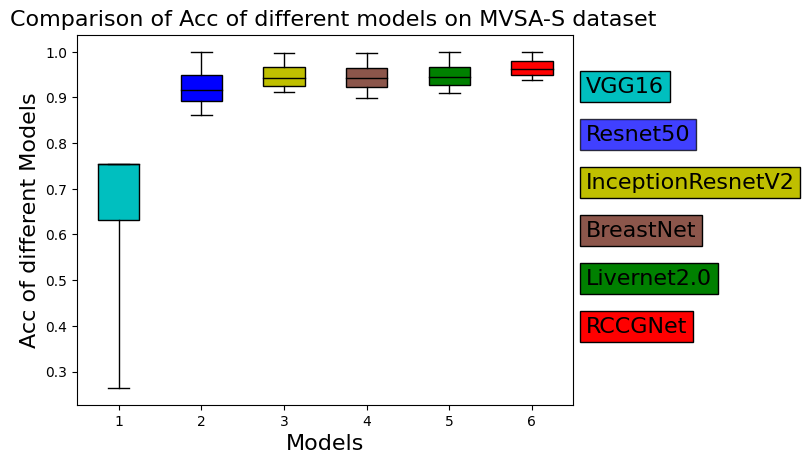

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import PathPatch
from pylab import *

## setting of default  text color to white
COLOR = 'k'
mpl.rcParams['text.color'] = COLOR



### Epoch is the range of X-axis
epoch = [1 ,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30]

xi = [i for i in range(0, len(epoch))]
### customizing the y axis range
yi = np.arange(0.15 , 1 ,0.01)
### listing of al  IOU values

VGG16= [0.2641,0.7547,0.7547,0.7547]
Resnet50 =[0.9018,0.8622,0.9327,0.9989]
InceptionResnetV2 = [0.9299,0.9110,0.9562,0.9968]
BreastNet = [0.9295,0.8994,0.9537,0.9978]
Livernet = [0.9330,0.9088,0.9562,0.9992]
RCCGNet=[0.9523,0.9372,0.9733,0.9996]
df = pd.DataFrame([VGG16,Resnet50,InceptionResnetV2,BreastNet,Livernet,RCCGNet],index=['1', '2', '3', '4','5', '6'])
# print(np.array(df).shape)
# df = np.reshape(np.array(df),(4,6))
fig, ax = plt.subplots()
n = np.array(df)
n = n.T

medianprops = dict(color='black',linewidth=1)
box = ax.boxplot(n,meanline = True, showfliers=True, whis=6, patch_artist=True, medianprops=medianprops)
plt.xlabel('Models',fontsize=16)
plt.ylabel('Acc of different Models',fontsize=16)
### Sepcifying the colors
colors = ['c','b','y','C5', 'g','r']
# colors = ['c','b','y','m','C5','g','#FF7373','r']
labels = ['VGG16','Resnet50','InceptionResnetV2','BreastNet','Livernet2.0','RCCGNet']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

fig.text(0.92, 0.76,'VGG16', fontsize = 16, bbox=dict(facecolor='c'))
fig.text(0.92, 0.66,'Resnet50', fontsize = 16, bbox=dict(facecolor='b',alpha = 0.75))
fig.text(0.92, 0.56,'InceptionResnetV2', fontsize = 16, bbox=dict(facecolor='y'))
fig.text(0.92, 0.46,'BreastNet',fontsize = 16, bbox=dict(facecolor='C5'))
fig.text(0.92, 0.36,'Livernet2.0',fontsize = 16, bbox=dict(facecolor='g'))
fig.text(0.92, 0.26,'RCCGNet', fontsize = 16, bbox=dict(facecolor='r'))
fig.text(0.02, 0.90,"Comparison of Acc of different models on MVSA-S dataset ",fontsize = 16)
#fig.savefig('ACC.png',dpi = 1000)
#plt.tight_layout()
# plt.savefig('',bbox_inches="tight")
## To get grid horizontal grid lines
ax.yaxis.grid(False)
plt.show()

In [ ]:
df0_single_scores_IF

----------------------------------------

MVSA-Multiple with Intermediate Fusion
MVSA-Multiple: densenet201-bert-pos-ner-lstm
Create new IF model for fold 0: multiple-densenet201-bert-pos-ner-lstm_fold0.h5
Model: "model_200"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_241 (InputLayer)      [(None, 808)]                0         []                            
                                                                                                  
 dropout_400 (Dropout)       (None, 808)                  0         ['input_241[0][0]']           
                                                                                                  
 reshape_160 (Reshape)       (None, 1, 808)               0         ['dropout_400[0][0]']         
                                                                                  

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


['positive' 'positive' 'positive' ... 'neutral' 'positive' 'positive']
[2 2 2 ... 1 2 2]
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 ...
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]]
Epoch 1/100
117/120 [============================>.] - ETA: 0s - loss: 1.1646 - accuracy: 0.4902 - f1_macro: 0.3289 - f1_weighted: 0.5095
Epoch 1: val_loss improved from inf to 0.91172, saving model to ./model_checkpoint/multiple-densenet201-bert-pos-ner-lstm_fold0.h5
120/120 [==============================] - 5s 14ms/step - loss: 1.1599 - accuracy: 0.4929 - f1_macro: 0.3298 - f1_weighted: 0.5113 - val_loss: 0.9117 - val_accuracy: 0.6400 - val_f1_macro: 0.3077 - val_f1_weighted: 0.5514
Epoch 2/100
 17/120 [===>..........................] - ETA: 0s - loss: 1.0718 - accuracy: 0.5556 - f1_macro: 0.3107 - f1_weighted: 0.5254

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


118/120 [============================>.] - ETA: 0s - loss: 1.0538 - accuracy: 0.5662 - f1_macro: 0.3176 - f1_weighted: 0.5314
Epoch 2: val_loss improved from 0.91172 to 0.89381, saving model to ./model_checkpoint/multiple-densenet201-bert-pos-ner-lstm_fold0.h5
120/120 [==============================] - 1s 8ms/step - loss: 1.0546 - accuracy: 0.5662 - f1_macro: 0.3172 - f1_weighted: 0.5313 - val_loss: 0.8938 - val_accuracy: 0.6412 - val_f1_macro: 0.2949 - val_f1_weighted: 0.5447
Epoch 3/100
118/120 [============================>.] - ETA: 0s - loss: 1.0323 - accuracy: 0.5824 - f1_macro: 0.3214 - f1_weighted: 0.5411
Epoch 3: val_loss improved from 0.89381 to 0.87531, saving model to ./model_checkpoint/multiple-densenet201-bert-pos-ner-lstm_fold0.h5
120/120 [==============================] - 1s 9ms/step - loss: 1.0308 - accuracy: 0.5829 - f1_macro: 0.3212 - f1_weighted: 0.5415 - val_loss: 0.8753 - val_accuracy: 0.6465 - val_f1_macro: 0.2979 - val_f1_weighted: 0.5488
Epoch 4/100
115/120 [===

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


Model IF checkpoint loaded at epoch 98 for fold 0
54/54 [==============================] - 1s 4ms/step - loss: 0.6691 - accuracy: 0.7117 - f1_macro: 0.4985 - f1_weighted: 0.6683
[[0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 ...
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]]
Loss: 0.6691088080406189
Accuracy: 0.7116852402687073
Macro F1-score: 0.4984540045261383
Weighted F1-score: 0.6683402061462402
54/54 [==============================] - 1s 2ms/step
[[0.26475903 0.42118716 0.3140538 ]
 [0.05569753 0.6660924  0.27821007]
 [0.6087396  0.24812885 0.14313154]
 ...
 [0.17629999 0.34089595 0.4828041 ]
 [0.07647566 0.19060059 0.7329237 ]
 [0.14892703 0.5058592  0.34521377]]


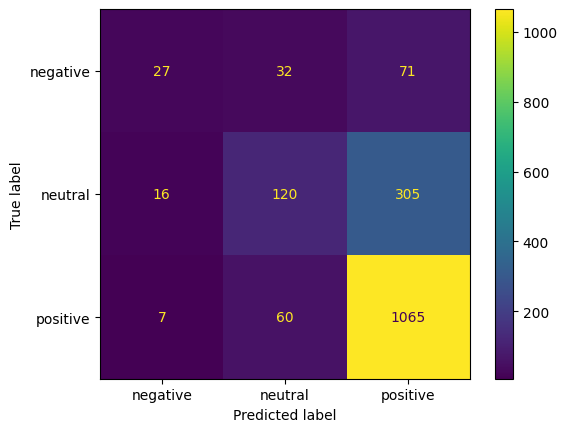

Create new IF model for fold 1: multiple-densenet201-bert-pos-ner-lstm_fold1.h5
Model: "model_201"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_243 (InputLayer)      [(None, 808)]                0         []                            
                                                                                                  
 dropout_404 (Dropout)       (None, 808)                  0         ['input_243[0][0]']           
                                                                                                  
 reshape_162 (Reshape)       (None, 1, 808)               0         ['dropout_404[0][0]']         
                                                                                                  
 lstm_121 (LSTM)             (None, 256)                  1090560   ['reshape_162[0][0]']         
          

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


['positive' 'positive' 'positive' ... 'positive' 'positive' 'positive']
[2 2 2 ... 2 2 2]
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 ...
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]
Epoch 1/100
119/120 [============================>.] - ETA: 0s - loss: 1.0465 - accuracy: 0.5608 - f1_macro: 0.3461 - f1_weighted: 0.5480
Epoch 1: val_loss improved from inf to 0.86982, saving model to ./model_checkpoint/multiple-densenet201-bert-pos-ner-lstm_fold1.h5
120/120 [==============================] - 5s 13ms/step - loss: 1.0465 - accuracy: 0.5612 - f1_macro: 0.3461 - f1_weighted: 0.5482 - val_loss: 0.8698 - val_accuracy: 0.6559 - val_f1_macro: 0.3108 - val_f1_weighted: 0.5596
Epoch 2/100
 17/120 [===>..........................] - ETA: 0s - loss: 1.0286 - accuracy: 0.5850 - f1_macro: 0.3281 - f1_weighted: 0.5471

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


116/120 [============================>.] - ETA: 0s - loss: 1.0158 - accuracy: 0.5865 - f1_macro: 0.3318 - f1_weighted: 0.5492
Epoch 2: val_loss improved from 0.86982 to 0.86193, saving model to ./model_checkpoint/multiple-densenet201-bert-pos-ner-lstm_fold1.h5
120/120 [==============================] - 1s 8ms/step - loss: 1.0180 - accuracy: 0.5857 - f1_macro: 0.3311 - f1_weighted: 0.5483 - val_loss: 0.8619 - val_accuracy: 0.6588 - val_f1_macro: 0.3066 - val_f1_weighted: 0.5574
Epoch 3/100
115/120 [===========================>..] - ETA: 0s - loss: 0.9939 - accuracy: 0.5940 - f1_macro: 0.3380 - f1_weighted: 0.5557
Epoch 3: val_loss improved from 0.86193 to 0.85172, saving model to ./model_checkpoint/multiple-densenet201-bert-pos-ner-lstm_fold1.h5
120/120 [==============================] - 1s 8ms/step - loss: 0.9956 - accuracy: 0.5932 - f1_macro: 0.3369 - f1_weighted: 0.5549 - val_loss: 0.8517 - val_accuracy: 0.6594 - val_f1_macro: 0.3101 - val_f1_weighted: 0.5604
Epoch 4/100
119/120 [===

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


Model IF checkpoint loaded at epoch 97 for fold 1
54/54 [==============================] - 1s 4ms/step - loss: 0.7017 - accuracy: 0.6929 - f1_macro: 0.4753 - f1_weighted: 0.6405
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 ...
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]]
Loss: 0.7017402052879333
Accuracy: 0.6928948760032654
Macro F1-score: 0.47531500458717346
Weighted F1-score: 0.6405131220817566
54/54 [==============================] - 1s 3ms/step
[[0.14814095 0.41023767 0.44162142]
 [0.02262731 0.21390766 0.76346505]
 [0.00364364 0.07516081 0.9211956 ]
 ...
 [0.16090307 0.20789072 0.6312062 ]
 [0.13673648 0.27133548 0.591928  ]
 [0.11109754 0.28385416 0.6050483 ]]


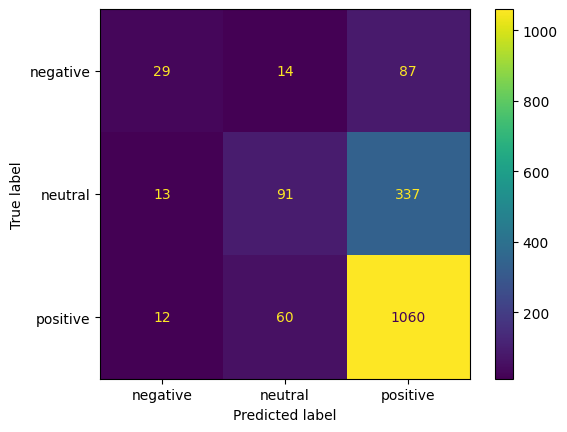

Create new IF model for fold 2: multiple-densenet201-bert-pos-ner-lstm_fold2.h5
Model: "model_202"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_245 (InputLayer)      [(None, 808)]                0         []                            
                                                                                                  
 dropout_408 (Dropout)       (None, 808)                  0         ['input_245[0][0]']           
                                                                                                  
 reshape_164 (Reshape)       (None, 1, 808)               0         ['dropout_408[0][0]']         
                                                                                                  
 lstm_122 (LSTM)             (None, 256)                  1090560   ['reshape_164[0][0]']         
          

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


['positive' 'positive' 'positive' ... 'positive' 'positive' 'positive']
[2 2 2 ... 2 2 2]
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 ...
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]
Epoch 1/100
116/120 [============================>.] - ETA: 0s - loss: 1.1769 - accuracy: 0.4607 - f1_macro: 0.3420 - f1_weighted: 0.5021
Epoch 1: val_loss improved from inf to 0.87283, saving model to ./model_checkpoint/multiple-densenet201-bert-pos-ner-lstm_fold2.h5
120/120 [==============================] - 5s 14ms/step - loss: 1.1717 - accuracy: 0.4642 - f1_macro: 0.3424 - f1_weighted: 0.5036 - val_loss: 0.8728 - val_accuracy: 0.6489 - val_f1_macro: 0.3093 - val_f1_weighted: 0.5513
Epoch 2/100
  8/120 [=>............................] - ETA: 0s - loss: 1.0467 - accuracy: 0.5420 - f1_macro: 0.3229 - f1_weighted: 0.5167

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


118/120 [============================>.] - ETA: 0s - loss: 1.0246 - accuracy: 0.5769 - f1_macro: 0.3289 - f1_weighted: 0.5420
Epoch 2: val_loss improved from 0.87283 to 0.86104, saving model to ./model_checkpoint/multiple-densenet201-bert-pos-ner-lstm_fold2.h5
120/120 [==============================] - 1s 9ms/step - loss: 1.0228 - accuracy: 0.5774 - f1_macro: 0.3290 - f1_weighted: 0.5427 - val_loss: 0.8610 - val_accuracy: 0.6518 - val_f1_macro: 0.2891 - val_f1_weighted: 0.5449
Epoch 3/100
117/120 [============================>.] - ETA: 0s - loss: 1.0079 - accuracy: 0.5921 - f1_macro: 0.3353 - f1_weighted: 0.5523
Epoch 3: val_loss improved from 0.86104 to 0.85652, saving model to ./model_checkpoint/multiple-densenet201-bert-pos-ner-lstm_fold2.h5
120/120 [==============================] - 1s 9ms/step - loss: 1.0079 - accuracy: 0.5925 - f1_macro: 0.3350 - f1_weighted: 0.5528 - val_loss: 0.8565 - val_accuracy: 0.6583 - val_f1_macro: 0.2900 - val_f1_weighted: 0.5476
Epoch 4/100
114/120 [===

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


Model IF checkpoint loaded at epoch 88 for fold 2
54/54 [==============================] - 1s 4ms/step - loss: 0.6803 - accuracy: 0.7052 - f1_macro: 0.4931 - f1_weighted: 0.6560
[[0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 ...
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]]
Loss: 0.6803188323974609
Accuracy: 0.7052260637283325
Macro F1-score: 0.49306520819664
Weighted F1-score: 0.656010627746582
54/54 [==============================] - 1s 3ms/step
[[0.02149356 0.23066017 0.74784625]
 [0.24806413 0.56767833 0.18425754]
 [0.00245798 0.0796959  0.91784614]
 ...
 [0.10529714 0.15367971 0.7410232 ]
 [0.00806197 0.2041526  0.7877854 ]
 [0.60456735 0.22193424 0.17349847]]


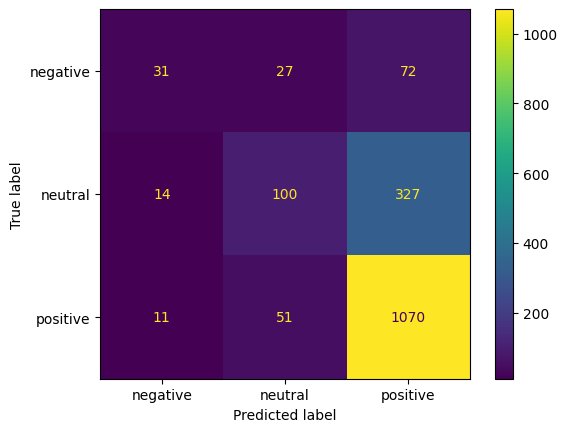

Create new IF model for fold 3: multiple-densenet201-bert-pos-ner-lstm_fold3.h5
Model: "model_203"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_247 (InputLayer)      [(None, 808)]                0         []                            
                                                                                                  
 dropout_412 (Dropout)       (None, 808)                  0         ['input_247[0][0]']           
                                                                                                  
 reshape_166 (Reshape)       (None, 1, 808)               0         ['dropout_412[0][0]']         
                                                                                                  
 lstm_123 (LSTM)             (None, 256)                  1090560   ['reshape_166[0][0]']         
          

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


['positive' 'positive' 'positive' ... 'positive' 'positive' 'positive']
[2 2 2 ... 2 2 2]
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 ...
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]
Epoch 1/100
114/120 [===========================>..] - ETA: 0s - loss: 1.1404 - accuracy: 0.4929 - f1_macro: 0.3380 - f1_weighted: 0.5174
Epoch 1: val_loss improved from inf to 0.87971, saving model to ./model_checkpoint/multiple-densenet201-bert-pos-ner-lstm_fold3.h5
120/120 [==============================] - 10s 15ms/step - loss: 1.1352 - accuracy: 0.4964 - f1_macro: 0.3374 - f1_weighted: 0.5183 - val_loss: 0.8797 - val_accuracy: 0.6418 - val_f1_macro: 0.2917 - val_f1_weighted: 0.5406
Epoch 2/100
 14/120 [==>...........................] - ETA: 0s - loss: 1.0541 - accuracy: 0.5709 - f1_macro: 0.3320 - f1_weighted: 0.5382

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


120/120 [==============================] - ETA: 0s - loss: 1.0141 - accuracy: 0.5838 - f1_macro: 0.3253 - f1_weighted: 0.5435
Epoch 2: val_loss improved from 0.87971 to 0.86756, saving model to ./model_checkpoint/multiple-densenet201-bert-pos-ner-lstm_fold3.h5
120/120 [==============================] - 1s 9ms/step - loss: 1.0141 - accuracy: 0.5838 - f1_macro: 0.3253 - f1_weighted: 0.5435 - val_loss: 0.8676 - val_accuracy: 0.6465 - val_f1_macro: 0.2882 - val_f1_weighted: 0.5419
Epoch 3/100
115/120 [===========================>..] - ETA: 0s - loss: 0.9858 - accuracy: 0.5984 - f1_macro: 0.3348 - f1_weighted: 0.5543
Epoch 3: val_loss improved from 0.86756 to 0.85907, saving model to ./model_checkpoint/multiple-densenet201-bert-pos-ner-lstm_fold3.h5
120/120 [==============================] - 1s 9ms/step - loss: 0.9876 - accuracy: 0.5980 - f1_macro: 0.3348 - f1_weighted: 0.5539 - val_loss: 0.8591 - val_accuracy: 0.6494 - val_f1_macro: 0.2915 - val_f1_weighted: 0.5453
Epoch 4/100
117/120 [===

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


Model IF checkpoint loaded at epoch 98 for fold 3
54/54 [==============================] - 1s 4ms/step - loss: 0.6838 - accuracy: 0.6882 - f1_macro: 0.4869 - f1_weighted: 0.6360
[[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 ...
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]]
Loss: 0.6837863326072693
Accuracy: 0.6881973147392273
Macro F1-score: 0.4869101047515869
Weighted F1-score: 0.6359732151031494
54/54 [==============================] - 1s 3ms/step
[[0.03511624 0.5571401  0.4077437 ]
 [0.04199865 0.32323137 0.63477   ]
 [0.44768974 0.42173195 0.1305784 ]
 ...
 [0.01790186 0.12320427 0.8588939 ]
 [0.2087509  0.39502704 0.39622203]
 [0.12137925 0.3255439  0.5530768 ]]


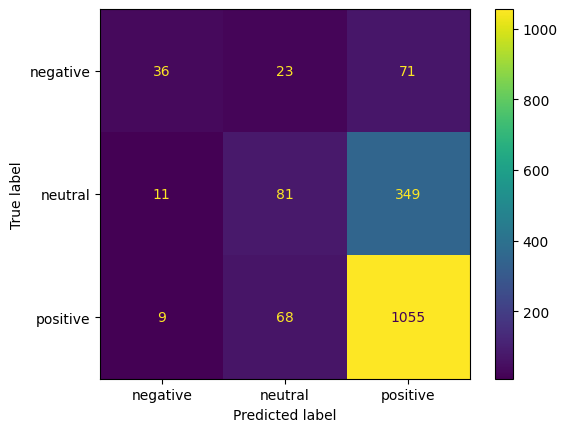

Create new IF model for fold 4: multiple-densenet201-bert-pos-ner-lstm_fold4.h5
Model: "model_204"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_249 (InputLayer)      [(None, 808)]                0         []                            
                                                                                                  
 dropout_416 (Dropout)       (None, 808)                  0         ['input_249[0][0]']           
                                                                                                  
 reshape_168 (Reshape)       (None, 1, 808)               0         ['dropout_416[0][0]']         
                                                                                                  
 lstm_124 (LSTM)             (None, 256)                  1090560   ['reshape_168[0][0]']         
          

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


['positive' 'positive' 'positive' ... 'neutral' 'positive' 'positive']
[2 2 2 ... 1 2 2]
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 ...
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]]
Epoch 1/100
118/120 [============================>.] - ETA: 0s - loss: 1.3704 - accuracy: 0.3855 - f1_macro: 0.3082 - f1_weighted: 0.4517
Epoch 1: val_loss improved from inf to 0.93338, saving model to ./model_checkpoint/multiple-densenet201-bert-pos-ner-lstm_fold4.h5
120/120 [==============================] - 5s 19ms/step - loss: 1.3675 - accuracy: 0.3868 - f1_macro: 0.3088 - f1_weighted: 0.4517 - val_loss: 0.9334 - val_accuracy: 0.6199 - val_f1_macro: 0.3016 - val_f1_weighted: 0.5364
Epoch 2/100
 10/120 [=>............................] - ETA: 1s - loss: 1.0937 - accuracy: 0.5383 - f1_macro: 0.3156 - f1_weighted: 0.5291

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


120/120 [==============================] - ETA: 0s - loss: 1.0764 - accuracy: 0.5531 - f1_macro: 0.3252 - f1_weighted: 0.5268
Epoch 2: val_loss improved from 0.93338 to 0.90060, saving model to ./model_checkpoint/multiple-densenet201-bert-pos-ner-lstm_fold4.h5
120/120 [==============================] - 1s 12ms/step - loss: 1.0764 - accuracy: 0.5531 - f1_macro: 0.3252 - f1_weighted: 0.5268 - val_loss: 0.9006 - val_accuracy: 0.6404 - val_f1_macro: 0.2818 - val_f1_weighted: 0.5356
Epoch 3/100
118/120 [============================>.] - ETA: 0s - loss: 1.0293 - accuracy: 0.5816 - f1_macro: 0.3313 - f1_weighted: 0.5436
Epoch 3: val_loss improved from 0.90060 to 0.88943, saving model to ./model_checkpoint/multiple-densenet201-bert-pos-ner-lstm_fold4.h5
120/120 [==============================] - 1s 11ms/step - loss: 1.0298 - accuracy: 0.5818 - f1_macro: 0.3311 - f1_weighted: 0.5436 - val_loss: 0.8894 - val_accuracy: 0.6457 - val_f1_macro: 0.2912 - val_f1_weighted: 0.5441
Epoch 4/100
115/120 [=

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


Model IF checkpoint loaded at epoch 97 for fold 4
54/54 [==============================] - 1s 4ms/step - loss: 0.6910 - accuracy: 0.6986 - f1_macro: 0.4859 - f1_weighted: 0.6497
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 ...
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]
Loss: 0.6910193562507629
Accuracy: 0.6985899209976196
Macro F1-score: 0.4859403073787689
Weighted F1-score: 0.649655818939209
54/54 [==============================] - 1s 3ms/step
[[0.16073821 0.575352   0.26390982]
 [0.06439247 0.32037467 0.6152328 ]
 [0.12211414 0.3196331  0.5582528 ]
 ...
 [0.01036333 0.13497092 0.8546658 ]
 [0.01214251 0.11665156 0.87120587]
 [0.1524768  0.38633147 0.4611917 ]]


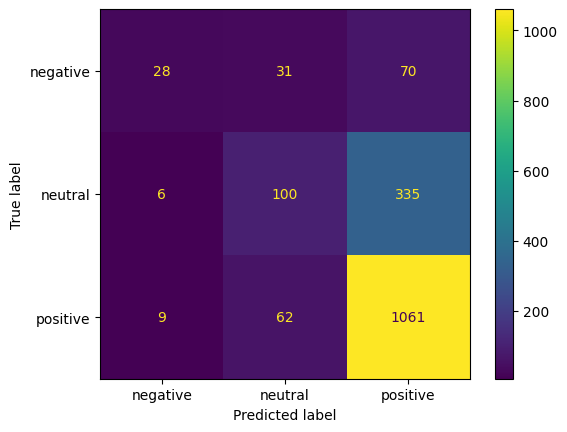

Create new IF model for fold 5: multiple-densenet201-bert-pos-ner-lstm_fold5.h5
Model: "model_205"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_251 (InputLayer)      [(None, 808)]                0         []                            
                                                                                                  
 dropout_420 (Dropout)       (None, 808)                  0         ['input_251[0][0]']           
                                                                                                  
 reshape_170 (Reshape)       (None, 1, 808)               0         ['dropout_420[0][0]']         
                                                                                                  
 lstm_125 (LSTM)             (None, 256)                  1090560   ['reshape_170[0][0]']         
          

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


['positive' 'positive' 'positive' ... 'positive' 'positive' 'positive']
[2 2 2 ... 2 2 2]
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 ...
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]
Epoch 1/100
120/120 [==============================] - ETA: 0s - loss: 1.0968 - accuracy: 0.5129 - f1_macro: 0.3468 - f1_weighted: 0.5296
Epoch 1: val_loss improved from inf to 0.88595, saving model to ./model_checkpoint/multiple-densenet201-bert-pos-ner-lstm_fold5.h5
120/120 [==============================] - 5s 15ms/step - loss: 1.0968 - accuracy: 0.5129 - f1_macro: 0.3468 - f1_weighted: 0.5296 - val_loss: 0.8859 - val_accuracy: 0.6381 - val_f1_macro: 0.2879 - val_f1_weighted: 0.5396
Epoch 2/100
 15/120 [==>...........................] - ETA: 0s - loss: 1.0037 - accuracy: 0.5786 - f1_macro: 0.3336 - f1_weighted: 0.5491

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


118/120 [============================>.] - ETA: 0s - loss: 1.0131 - accuracy: 0.5871 - f1_macro: 0.3356 - f1_weighted: 0.5501
Epoch 2: val_loss improved from 0.88595 to 0.87532, saving model to ./model_checkpoint/multiple-densenet201-bert-pos-ner-lstm_fold5.h5
120/120 [==============================] - 1s 9ms/step - loss: 1.0135 - accuracy: 0.5865 - f1_macro: 0.3350 - f1_weighted: 0.5494 - val_loss: 0.8753 - val_accuracy: 0.6398 - val_f1_macro: 0.2915 - val_f1_weighted: 0.5426
Epoch 3/100
117/120 [============================>.] - ETA: 0s - loss: 0.9860 - accuracy: 0.5978 - f1_macro: 0.3428 - f1_weighted: 0.5586
Epoch 3: val_loss improved from 0.87532 to 0.86948, saving model to ./model_checkpoint/multiple-densenet201-bert-pos-ner-lstm_fold5.h5
120/120 [==============================] - 1s 9ms/step - loss: 0.9855 - accuracy: 0.5980 - f1_macro: 0.3425 - f1_weighted: 0.5586 - val_loss: 0.8695 - val_accuracy: 0.6539 - val_f1_macro: 0.2942 - val_f1_weighted: 0.5490
Epoch 4/100
119/120 [===

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


Model IF checkpoint loaded at epoch 93 for fold 5
54/54 [==============================] - 1s 4ms/step - loss: 0.6781 - accuracy: 0.6974 - f1_macro: 0.4946 - f1_weighted: 0.6459
[[0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 ...
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]]
Loss: 0.6781299114227295
Accuracy: 0.6974148154258728
Macro F1-score: 0.49463462829589844
Weighted F1-score: 0.6459138989448547
54/54 [==============================] - 1s 3ms/step
[[0.00197576 0.0804762  0.91754806]
 [0.19849679 0.57543314 0.22607003]
 [0.19320764 0.46745786 0.3393345 ]
 ...
 [0.07231105 0.20222645 0.72546244]
 [0.01985069 0.31883976 0.66130954]
 [0.00159681 0.04070539 0.9576978 ]]


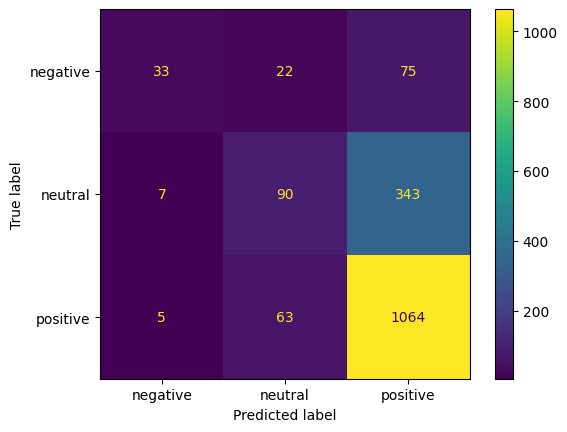

Create new IF model for fold 6: multiple-densenet201-bert-pos-ner-lstm_fold6.h5
Model: "model_206"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_253 (InputLayer)      [(None, 808)]                0         []                            
                                                                                                  
 dropout_424 (Dropout)       (None, 808)                  0         ['input_253[0][0]']           
                                                                                                  
 reshape_172 (Reshape)       (None, 1, 808)               0         ['dropout_424[0][0]']         
                                                                                                  
 lstm_126 (LSTM)             (None, 256)                  1090560   ['reshape_172[0][0]']         
          

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


['positive' 'positive' 'positive' ... 'positive' 'positive' 'positive']
[2 2 2 ... 2 2 2]
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 ...
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]
Epoch 1/100
116/120 [============================>.] - ETA: 0s - loss: 1.0815 - accuracy: 0.5492 - f1_macro: 0.3351 - f1_weighted: 0.5360
Epoch 1: val_loss improved from inf to 0.90172, saving model to ./model_checkpoint/multiple-densenet201-bert-pos-ner-lstm_fold6.h5
120/120 [==============================] - 6s 18ms/step - loss: 1.0774 - accuracy: 0.5511 - f1_macro: 0.3358 - f1_weighted: 0.5372 - val_loss: 0.9017 - val_accuracy: 0.6269 - val_f1_macro: 0.2774 - val_f1_weighted: 0.5279
Epoch 2/100
 16/120 [===>..........................] - ETA: 0s - loss: 1.0137 - accuracy: 0.5845 - f1_macro: 0.3220 - f1_weighted: 0.5449

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


119/120 [============================>.] - ETA: 0s - loss: 1.0247 - accuracy: 0.5811 - f1_macro: 0.3218 - f1_weighted: 0.5409
Epoch 2: val_loss improved from 0.90172 to 0.88961, saving model to ./model_checkpoint/multiple-densenet201-bert-pos-ner-lstm_fold6.h5
120/120 [==============================] - 1s 9ms/step - loss: 1.0250 - accuracy: 0.5808 - f1_macro: 0.3215 - f1_weighted: 0.5408 - val_loss: 0.8896 - val_accuracy: 0.6334 - val_f1_macro: 0.2770 - val_f1_weighted: 0.5295
Epoch 3/100
115/120 [===========================>..] - ETA: 0s - loss: 1.0068 - accuracy: 0.5890 - f1_macro: 0.3244 - f1_weighted: 0.5456
Epoch 3: val_loss improved from 0.88961 to 0.87577, saving model to ./model_checkpoint/multiple-densenet201-bert-pos-ner-lstm_fold6.h5
120/120 [==============================] - 1s 9ms/step - loss: 1.0036 - accuracy: 0.5895 - f1_macro: 0.3246 - f1_weighted: 0.5461 - val_loss: 0.8758 - val_accuracy: 0.6351 - val_f1_macro: 0.2765 - val_f1_weighted: 0.5300
Epoch 4/100
115/120 [===

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


Model IF checkpoint loaded at epoch 98 for fold 6
54/54 [==============================] - 1s 5ms/step - loss: 0.6912 - accuracy: 0.7045 - f1_macro: 0.4973 - f1_weighted: 0.6563
[[0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 ...
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
Loss: 0.6912147402763367
Accuracy: 0.7044653296470642
Macro F1-score: 0.497286319732666
Weighted F1-score: 0.6563169956207275
54/54 [==============================] - 1s 3ms/step
[[0.17059419 0.41252238 0.4168835 ]
 [0.12673011 0.4310933  0.44217658]
 [0.19830449 0.48251387 0.3191817 ]
 ...
 [0.5919939  0.28502336 0.12298269]
 [0.10849208 0.2885699  0.602938  ]
 [0.18399969 0.3063509  0.5096494 ]]


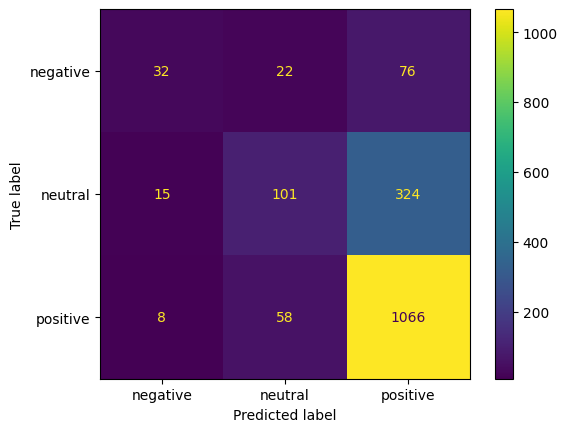

Create new IF model for fold 7: multiple-densenet201-bert-pos-ner-lstm_fold7.h5
Model: "model_207"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_255 (InputLayer)      [(None, 808)]                0         []                            
                                                                                                  
 dropout_428 (Dropout)       (None, 808)                  0         ['input_255[0][0]']           
                                                                                                  
 reshape_174 (Reshape)       (None, 1, 808)               0         ['dropout_428[0][0]']         
                                                                                                  
 lstm_127 (LSTM)             (None, 256)                  1090560   ['reshape_174[0][0]']         
          

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


['positive' 'positive' 'positive' ... 'positive' 'positive' 'positive']
[2 2 2 ... 2 2 2]
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 ...
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]
Epoch 1/100
120/120 [==============================] - ETA: 0s - loss: 1.4693 - accuracy: 0.3327 - f1_macro: 0.3079 - f1_weighted: 0.4196
Epoch 1: val_loss improved from inf to 0.92422, saving model to ./model_checkpoint/multiple-densenet201-bert-pos-ner-lstm_fold7.h5
120/120 [==============================] - 5s 14ms/step - loss: 1.4693 - accuracy: 0.3327 - f1_macro: 0.3079 - f1_weighted: 0.4196 - val_loss: 0.9242 - val_accuracy: 0.6069 - val_f1_macro: 0.3388 - val_f1_weighted: 0.5635
Epoch 2/100
 13/120 [==>...........................] - ETA: 0s - loss: 1.0943 - accuracy: 0.5180 - f1_macro: 0.3432 - f1_weighted: 0.5260

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


115/120 [===========================>..] - ETA: 0s - loss: 1.0433 - accuracy: 0.5578 - f1_macro: 0.3472 - f1_weighted: 0.5431
Epoch 2: val_loss improved from 0.92422 to 0.87731, saving model to ./model_checkpoint/multiple-densenet201-bert-pos-ner-lstm_fold7.h5
120/120 [==============================] - 1s 9ms/step - loss: 1.0415 - accuracy: 0.5597 - f1_macro: 0.3474 - f1_weighted: 0.5443 - val_loss: 0.8773 - val_accuracy: 0.6551 - val_f1_macro: 0.3117 - val_f1_weighted: 0.5626
Epoch 3/100
117/120 [============================>.] - ETA: 0s - loss: 1.0112 - accuracy: 0.5901 - f1_macro: 0.3417 - f1_weighted: 0.5551
Epoch 3: val_loss improved from 0.87731 to 0.87328, saving model to ./model_checkpoint/multiple-densenet201-bert-pos-ner-lstm_fold7.h5
120/120 [==============================] - 1s 9ms/step - loss: 1.0106 - accuracy: 0.5903 - f1_macro: 0.3421 - f1_weighted: 0.5555 - val_loss: 0.8733 - val_accuracy: 0.6563 - val_f1_macro: 0.3130 - val_f1_weighted: 0.5642
Epoch 4/100
116/120 [===

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


Model IF checkpoint loaded at epoch 92 for fold 7
54/54 [==============================] - 1s 5ms/step - loss: 0.6979 - accuracy: 0.6863 - f1_macro: 0.4705 - f1_weighted: 0.6387
[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 ...
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]]
Loss: 0.6979464888572693
Accuracy: 0.6862514615058899
Macro F1-score: 0.4705214500427246
Weighted F1-score: 0.6387070417404175
54/54 [==============================] - 1s 3ms/step
[[0.0224317  0.46874976 0.50881857]
 [0.5995571  0.32858527 0.07185767]
 [0.13954428 0.45256725 0.40788847]
 ...
 [0.22376916 0.37506685 0.40116397]
 [0.15532744 0.29492185 0.54975075]
 [0.09902681 0.18277594 0.7181973 ]]


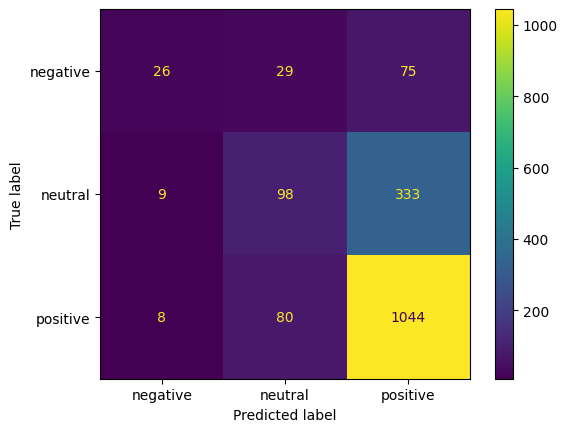

Create new IF model for fold 8: multiple-densenet201-bert-pos-ner-lstm_fold8.h5
Model: "model_208"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_257 (InputLayer)      [(None, 808)]                0         []                            
                                                                                                  
 dropout_432 (Dropout)       (None, 808)                  0         ['input_257[0][0]']           
                                                                                                  
 reshape_176 (Reshape)       (None, 1, 808)               0         ['dropout_432[0][0]']         
                                                                                                  
 lstm_128 (LSTM)             (None, 256)                  1090560   ['reshape_176[0][0]']         
          

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


['positive' 'positive' 'positive' ... 'positive' 'positive' 'positive']
[2 2 2 ... 2 2 2]
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 ...
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]
Epoch 1/100
119/120 [============================>.] - ETA: 0s - loss: 1.2778 - accuracy: 0.4221 - f1_macro: 0.3291 - f1_weighted: 0.4817
Epoch 1: val_loss improved from inf to 0.90039, saving model to ./model_checkpoint/multiple-densenet201-bert-pos-ner-lstm_fold8.h5
120/120 [==============================] - 6s 20ms/step - loss: 1.2759 - accuracy: 0.4231 - f1_macro: 0.3295 - f1_weighted: 0.4823 - val_loss: 0.9004 - val_accuracy: 0.6316 - val_f1_macro: 0.2864 - val_f1_weighted: 0.5341
Epoch 2/100
  7/120 [>.............................] - ETA: 1s - loss: 1.0509 - accuracy: 0.5480 - f1_macro: 0.3429 - f1_weighted: 0.5310

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


120/120 [==============================] - ETA: 0s - loss: 1.0410 - accuracy: 0.5738 - f1_macro: 0.3365 - f1_weighted: 0.5443
Epoch 2: val_loss improved from 0.90039 to 0.88134, saving model to ./model_checkpoint/multiple-densenet201-bert-pos-ner-lstm_fold8.h5
120/120 [==============================] - 1s 10ms/step - loss: 1.0410 - accuracy: 0.5738 - f1_macro: 0.3365 - f1_weighted: 0.5443 - val_loss: 0.8813 - val_accuracy: 0.6439 - val_f1_macro: 0.2817 - val_f1_weighted: 0.5363
Epoch 3/100
115/120 [===========================>..] - ETA: 0s - loss: 1.0114 - accuracy: 0.5912 - f1_macro: 0.3378 - f1_weighted: 0.5532
Epoch 3: val_loss improved from 0.88134 to 0.87979, saving model to ./model_checkpoint/multiple-densenet201-bert-pos-ner-lstm_fold8.h5
120/120 [==============================] - 1s 9ms/step - loss: 1.0090 - accuracy: 0.5927 - f1_macro: 0.3388 - f1_weighted: 0.5550 - val_loss: 0.8798 - val_accuracy: 0.6486 - val_f1_macro: 0.2844 - val_f1_weighted: 0.5398
Epoch 4/100
113/120 [==

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


Model IF checkpoint loaded at epoch 91 for fold 8
54/54 [==============================] - 1s 6ms/step - loss: 0.7046 - accuracy: 0.6880 - f1_macro: 0.4668 - f1_weighted: 0.6384
[[1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 ...
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]]
Loss: 0.7045819759368896
Accuracy: 0.6880140900611877
Macro F1-score: 0.46681609749794006
Weighted F1-score: 0.6384498476982117
54/54 [==============================] - 1s 3ms/step
[[0.16060588 0.63976943 0.1996247 ]
 [0.07011607 0.58217835 0.34770563]
 [0.0102348  0.28131634 0.7084488 ]
 ...
 [0.01829718 0.49857795 0.48312494]
 [0.03646139 0.10951862 0.85402   ]
 [0.04564096 0.17688039 0.7774787 ]]


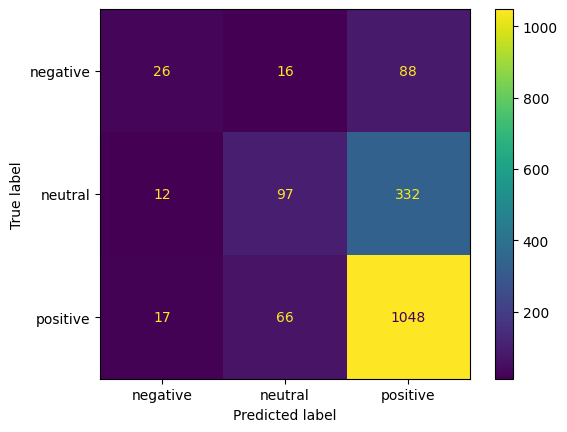

Create new IF model for fold 9: multiple-densenet201-bert-pos-ner-lstm_fold9.h5
Model: "model_209"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_259 (InputLayer)      [(None, 808)]                0         []                            
                                                                                                  
 dropout_436 (Dropout)       (None, 808)                  0         ['input_259[0][0]']           
                                                                                                  
 reshape_178 (Reshape)       (None, 1, 808)               0         ['dropout_436[0][0]']         
                                                                                                  
 lstm_129 (LSTM)             (None, 256)                  1090560   ['reshape_178[0][0]']         
          

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


['positive' 'positive' 'positive' ... 'positive' 'positive' 'positive']
[2 2 2 ... 2 2 2]
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 ...
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]
Epoch 1/100
115/120 [===========================>..] - ETA: 0s - loss: 1.1622 - accuracy: 0.5039 - f1_macro: 0.3302 - f1_weighted: 0.5173
Epoch 1: val_loss improved from inf to 0.90340, saving model to ./model_checkpoint/multiple-densenet201-bert-pos-ner-lstm_fold9.h5
120/120 [==============================] - 5s 15ms/step - loss: 1.1604 - accuracy: 0.5052 - f1_macro: 0.3287 - f1_weighted: 0.5164 - val_loss: 0.9034 - val_accuracy: 0.6510 - val_f1_macro: 0.2865 - val_f1_weighted: 0.5424
Epoch 2/100
 16/120 [===>..........................] - ETA: 0s - loss: 1.0870 - accuracy: 0.5630 - f1_macro: 0.3012 - f1_weighted: 0.5177

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


118/120 [============================>.] - ETA: 0s - loss: 1.0397 - accuracy: 0.5769 - f1_macro: 0.3135 - f1_weighted: 0.5344
Epoch 2: val_loss improved from 0.90340 to 0.88401, saving model to ./model_checkpoint/multiple-densenet201-bert-pos-ner-lstm_fold9.h5
120/120 [==============================] - 1s 9ms/step - loss: 1.0380 - accuracy: 0.5775 - f1_macro: 0.3141 - f1_weighted: 0.5351 - val_loss: 0.8840 - val_accuracy: 0.6486 - val_f1_macro: 0.2912 - val_f1_weighted: 0.5447
Epoch 3/100
117/120 [============================>.] - ETA: 0s - loss: 1.0173 - accuracy: 0.5859 - f1_macro: 0.3229 - f1_weighted: 0.5434
Epoch 3: val_loss improved from 0.88401 to 0.87439, saving model to ./model_checkpoint/multiple-densenet201-bert-pos-ner-lstm_fold9.h5
120/120 [==============================] - 1s 9ms/step - loss: 1.0189 - accuracy: 0.5865 - f1_macro: 0.3230 - f1_weighted: 0.5438 - val_loss: 0.8744 - val_accuracy: 0.6475 - val_f1_macro: 0.2852 - val_f1_weighted: 0.5401
Epoch 4/100
116/120 [===

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


Model IF checkpoint loaded at epoch 64 for fold 9
54/54 [==============================] - 1s 6ms/step - loss: 0.7164 - accuracy: 0.6839 - f1_macro: 0.4501 - f1_weighted: 0.6337
[[0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 ...
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
Loss: 0.7163703441619873
Accuracy: 0.683901309967041
Macro F1-score: 0.45011433959007263
Weighted F1-score: 0.6336700320243835
54/54 [==============================] - 1s 4ms/step
[[0.06404579 0.44558504 0.49036917]
 [0.02768547 0.52715844 0.44515607]
 [0.12949392 0.53946006 0.33104602]
 ...
 [0.08030917 0.19192995 0.72776085]
 [0.01405447 0.12578927 0.8601563 ]
 [0.13368997 0.4509116  0.41539848]]


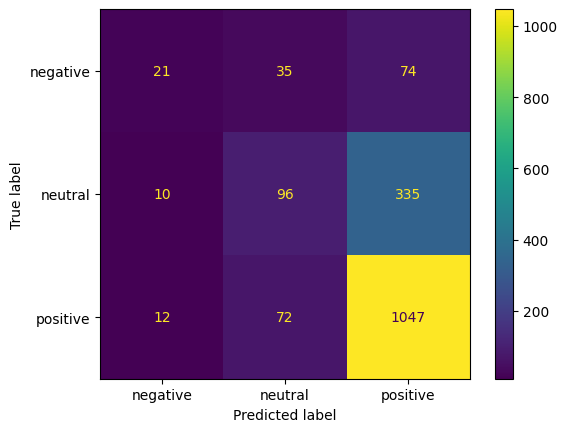

MVSA-Multiple: densenet201-bert-lstm
Create new IF model for fold 0: multiple-densenet201-bert-lstm_fold0.h5
Model: "model_210"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_261 (InputLayer)      [(None, 768)]                0         []                            
                                                                                                  
 dropout_440 (Dropout)       (None, 768)                  0         ['input_261[0][0]']           
                                                                                                  
 reshape_180 (Reshape)       (None, 1, 768)               0         ['dropout_440[0][0]']         
                                                                                                  
 lstm_130 (LSTM)             (None, 256)                  1049600   ['reshape_18

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


['positive' 'positive' 'positive' ... 'neutral' 'positive' 'positive']
[2 2 2 ... 1 2 2]
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 ...
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]]
Epoch 1/100
115/120 [===========================>..] - ETA: 0s - loss: 1.1508 - accuracy: 0.5181 - f1_macro: 0.3342 - f1_weighted: 0.5243
Epoch 1: val_loss improved from inf to 0.93034, saving model to ./model_checkpoint/multiple-densenet201-bert-lstm_fold0.h5
120/120 [==============================] - 5s 15ms/step - loss: 1.1486 - accuracy: 0.5199 - f1_macro: 0.3337 - f1_weighted: 0.5248 - val_loss: 0.9303 - val_accuracy: 0.6377 - val_f1_macro: 0.2891 - val_f1_weighted: 0.5372
Epoch 2/100
 15/120 [==>...........................] - ETA: 0s - loss: 1.0563 - accuracy: 0.5625 - f1_macro: 0.3216 - f1_weighted: 0.5294

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


119/120 [============================>.] - ETA: 0s - loss: 1.0493 - accuracy: 0.5810 - f1_macro: 0.3305 - f1_weighted: 0.5432
Epoch 2: val_loss improved from 0.93034 to 0.90925, saving model to ./model_checkpoint/multiple-densenet201-bert-lstm_fold0.h5
120/120 [==============================] - 1s 9ms/step - loss: 1.0490 - accuracy: 0.5809 - f1_macro: 0.3309 - f1_weighted: 0.5432 - val_loss: 0.9093 - val_accuracy: 0.6400 - val_f1_macro: 0.2899 - val_f1_weighted: 0.5386
Epoch 3/100
118/120 [============================>.] - ETA: 0s - loss: 1.0245 - accuracy: 0.5908 - f1_macro: 0.3299 - f1_weighted: 0.5485
Epoch 3: val_loss improved from 0.90925 to 0.89098, saving model to ./model_checkpoint/multiple-densenet201-bert-lstm_fold0.h5
120/120 [==============================] - 1s 9ms/step - loss: 1.0234 - accuracy: 0.5908 - f1_macro: 0.3294 - f1_weighted: 0.5484 - val_loss: 0.8910 - val_accuracy: 0.6418 - val_f1_macro: 0.2939 - val_f1_weighted: 0.5421
Epoch 4/100
118/120 [===================

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


Model IF checkpoint loaded at epoch 98 for fold 0
54/54 [==============================] - 1s 4ms/step - loss: 0.6741 - accuracy: 0.7070 - f1_macro: 0.4888 - f1_weighted: 0.6629
[[0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 ...
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]]
Loss: 0.6741358637809753
Accuracy: 0.7069876790046692
Macro F1-score: 0.4887814223766327
Weighted F1-score: 0.6629039645195007
54/54 [==============================] - 1s 3ms/step
[[0.26279444 0.44988915 0.28731644]
 [0.07300584 0.65137947 0.2756147 ]
 [0.76485145 0.15792058 0.07722801]
 ...
 [0.31907612 0.30883983 0.37208405]
 [0.07172023 0.17981945 0.7484603 ]
 [0.12007072 0.54105365 0.33887562]]


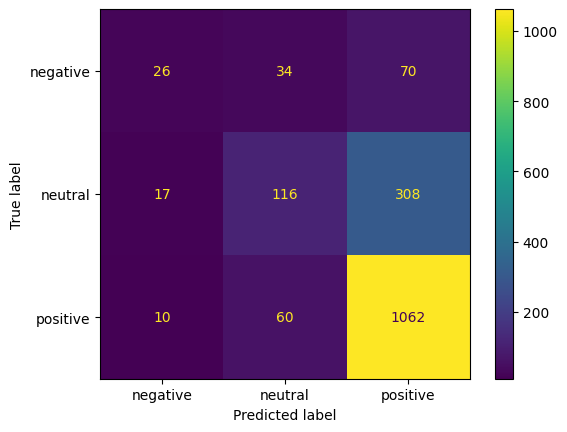

Create new IF model for fold 1: multiple-densenet201-bert-lstm_fold1.h5
Model: "model_211"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_263 (InputLayer)      [(None, 768)]                0         []                            
                                                                                                  
 dropout_444 (Dropout)       (None, 768)                  0         ['input_263[0][0]']           
                                                                                                  
 reshape_182 (Reshape)       (None, 1, 768)               0         ['dropout_444[0][0]']         
                                                                                                  
 lstm_131 (LSTM)             (None, 256)                  1049600   ['reshape_182[0][0]']         
                  

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


['positive' 'positive' 'positive' ... 'positive' 'positive' 'positive']
[2 2 2 ... 2 2 2]
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 ...
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]
Epoch 1/100
119/120 [============================>.] - ETA: 0s - loss: 1.2349 - accuracy: 0.4303 - f1_macro: 0.3406 - f1_weighted: 0.4900
Epoch 1: val_loss improved from inf to 0.85965, saving model to ./model_checkpoint/multiple-densenet201-bert-lstm_fold1.h5
120/120 [==============================] - 6s 20ms/step - loss: 1.2342 - accuracy: 0.4311 - f1_macro: 0.3408 - f1_weighted: 0.4906 - val_loss: 0.8596 - val_accuracy: 0.6459 - val_f1_macro: 0.3226 - val_f1_weighted: 0.5588
Epoch 2/100
  6/120 [>.............................] - ETA: 1s - loss: 1.0348 - accuracy: 0.5781 - f1_macro: 0.3446 - f1_weighted: 0.5671

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


114/120 [===========================>..] - ETA: 0s - loss: 1.0078 - accuracy: 0.5837 - f1_macro: 0.3421 - f1_weighted: 0.5530
Epoch 2: val_loss improved from 0.85965 to 0.84781, saving model to ./model_checkpoint/multiple-densenet201-bert-lstm_fold1.h5
120/120 [==============================] - 1s 10ms/step - loss: 1.0065 - accuracy: 0.5836 - f1_macro: 0.3423 - f1_weighted: 0.5529 - val_loss: 0.8478 - val_accuracy: 0.6518 - val_f1_macro: 0.2962 - val_f1_weighted: 0.5470
Epoch 3/100
120/120 [==============================] - ETA: 0s - loss: 0.9820 - accuracy: 0.5951 - f1_macro: 0.3374 - f1_weighted: 0.5554
Epoch 3: val_loss improved from 0.84781 to 0.84551, saving model to ./model_checkpoint/multiple-densenet201-bert-lstm_fold1.h5
120/120 [==============================] - 3s 26ms/step - loss: 0.9820 - accuracy: 0.5951 - f1_macro: 0.3374 - f1_weighted: 0.5554 - val_loss: 0.8455 - val_accuracy: 0.6524 - val_f1_macro: 0.2936 - val_f1_weighted: 0.5478
Epoch 4/100
115/120 [=================

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


Model IF checkpoint loaded at epoch 97 for fold 1
54/54 [==============================] - 1s 4ms/step - loss: 0.7024 - accuracy: 0.6970 - f1_macro: 0.4900 - f1_weighted: 0.6437
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 ...
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]]
Loss: 0.7023826837539673
Accuracy: 0.6970052719116211
Macro F1-score: 0.48995280265808105
Weighted F1-score: 0.6436642408370972
54/54 [==============================] - 1s 3ms/step
[[0.14569151 0.3841069  0.47020155]
 [0.01310178 0.25531465 0.7315836 ]
 [0.00458218 0.09848175 0.89693606]
 ...
 [0.13371554 0.21887513 0.6474094 ]
 [0.21954831 0.19309242 0.58735925]
 [0.09542415 0.3332276  0.57134825]]


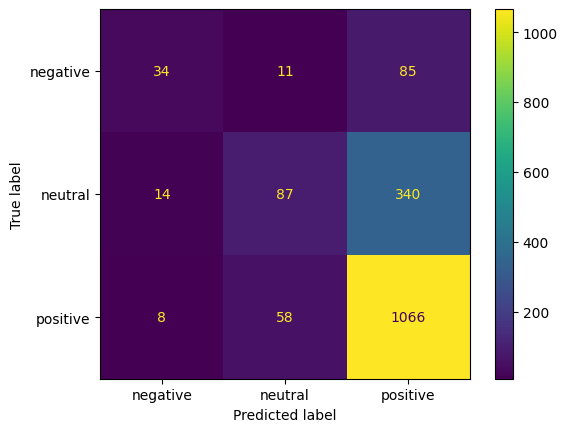

Create new IF model for fold 2: multiple-densenet201-bert-lstm_fold2.h5
Model: "model_212"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_265 (InputLayer)      [(None, 768)]                0         []                            
                                                                                                  
 dropout_448 (Dropout)       (None, 768)                  0         ['input_265[0][0]']           
                                                                                                  
 reshape_184 (Reshape)       (None, 1, 768)               0         ['dropout_448[0][0]']         
                                                                                                  
 lstm_132 (LSTM)             (None, 256)                  1049600   ['reshape_184[0][0]']         
                  

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


['positive' 'positive' 'positive' ... 'positive' 'positive' 'positive']
[2 2 2 ... 2 2 2]
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 ...
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]
Epoch 1/100
117/120 [============================>.] - ETA: 0s - loss: 1.1145 - accuracy: 0.5388 - f1_macro: 0.3330 - f1_weighted: 0.5285
Epoch 1: val_loss improved from inf to 0.91386, saving model to ./model_checkpoint/multiple-densenet201-bert-lstm_fold2.h5
120/120 [==============================] - 6s 15ms/step - loss: 1.1128 - accuracy: 0.5393 - f1_macro: 0.3329 - f1_weighted: 0.5285 - val_loss: 0.9139 - val_accuracy: 0.6271 - val_f1_macro: 0.2836 - val_f1_weighted: 0.5281
Epoch 2/100
  1/120 [..............................] - ETA: 1s - loss: 1.1259 - accuracy: 0.4844 - f1_macro: 0.2589 - f1_weighted: 0.4485

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


120/120 [==============================] - ETA: 0s - loss: 1.0312 - accuracy: 0.5772 - f1_macro: 0.3253 - f1_weighted: 0.5387
Epoch 2: val_loss improved from 0.91386 to 0.89170, saving model to ./model_checkpoint/multiple-densenet201-bert-lstm_fold2.h5
120/120 [==============================] - 1s 10ms/step - loss: 1.0312 - accuracy: 0.5772 - f1_macro: 0.3253 - f1_weighted: 0.5387 - val_loss: 0.8917 - val_accuracy: 0.6318 - val_f1_macro: 0.2812 - val_f1_weighted: 0.5322
Epoch 3/100
113/120 [===========================>..] - ETA: 0s - loss: 1.0230 - accuracy: 0.5824 - f1_macro: 0.3257 - f1_weighted: 0.5423
Epoch 3: val_loss improved from 0.89170 to 0.87635, saving model to ./model_checkpoint/multiple-densenet201-bert-lstm_fold2.h5
120/120 [==============================] - 2s 15ms/step - loss: 1.0219 - accuracy: 0.5833 - f1_macro: 0.3270 - f1_weighted: 0.5434 - val_loss: 0.8764 - val_accuracy: 0.6371 - val_f1_macro: 0.2808 - val_f1_weighted: 0.5339
Epoch 4/100
115/120 [=================

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


Model IF checkpoint loaded at epoch 95 for fold 2
54/54 [==============================] - 1s 4ms/step - loss: 0.6865 - accuracy: 0.7046 - f1_macro: 0.4708 - f1_weighted: 0.6536
[[0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 ...
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]]
Loss: 0.6864892244338989
Accuracy: 0.7046388983726501
Macro F1-score: 0.47076216340065
Weighted F1-score: 0.6536113023757935
54/54 [==============================] - 1s 3ms/step
[[0.01565074 0.2626658  0.72168344]
 [0.24262145 0.58960503 0.16777347]
 [0.0026923  0.08471585 0.9125918 ]
 ...
 [0.11962576 0.16228327 0.71809095]
 [0.00446856 0.2506577  0.74487376]
 [0.66757894 0.18531051 0.14711048]]


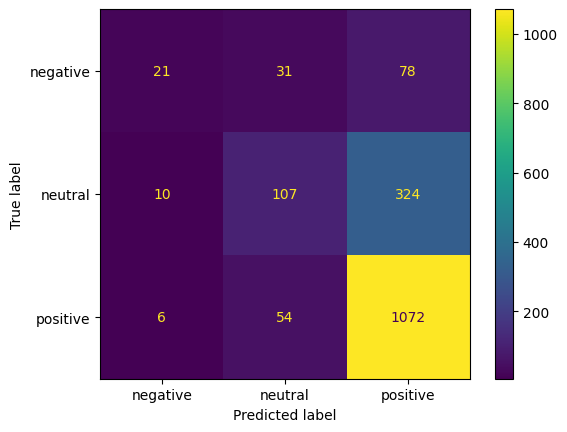

Create new IF model for fold 3: multiple-densenet201-bert-lstm_fold3.h5
Model: "model_213"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_267 (InputLayer)      [(None, 768)]                0         []                            
                                                                                                  
 dropout_452 (Dropout)       (None, 768)                  0         ['input_267[0][0]']           
                                                                                                  
 reshape_186 (Reshape)       (None, 1, 768)               0         ['dropout_452[0][0]']         
                                                                                                  
 lstm_133 (LSTM)             (None, 256)                  1049600   ['reshape_186[0][0]']         
                  

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


['positive' 'positive' 'positive' ... 'positive' 'positive' 'positive']
[2 2 2 ... 2 2 2]
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 ...
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]
Epoch 1/100
116/120 [============================>.] - ETA: 0s - loss: 1.2681 - accuracy: 0.4186 - f1_macro: 0.3324 - f1_weighted: 0.4808
Epoch 1: val_loss improved from inf to 0.91375, saving model to ./model_checkpoint/multiple-densenet201-bert-lstm_fold3.h5


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


120/120 [==============================] - 5s 21ms/step - loss: 1.2617 - accuracy: 0.4222 - f1_macro: 0.3332 - f1_weighted: 0.4825 - val_loss: 0.9137 - val_accuracy: 0.6142 - val_f1_macro: 0.2911 - val_f1_weighted: 0.5295
Epoch 2/100
116/120 [============================>.] - ETA: 0s - loss: 1.0250 - accuracy: 0.5696 - f1_macro: 0.3407 - f1_weighted: 0.5423
Epoch 2: val_loss improved from 0.91375 to 0.89197, saving model to ./model_checkpoint/multiple-densenet201-bert-lstm_fold3.h5
120/120 [==============================] - 5s 40ms/step - loss: 1.0250 - accuracy: 0.5703 - f1_macro: 0.3411 - f1_weighted: 0.5428 - val_loss: 0.8920 - val_accuracy: 0.6430 - val_f1_macro: 0.2853 - val_f1_weighted: 0.5395
Epoch 3/100
120/120 [==============================] - ETA: 0s - loss: 0.9951 - accuracy: 0.5904 - f1_macro: 0.3290 - f1_weighted: 0.5487
Epoch 3: val_loss improved from 0.89197 to 0.88412, saving model to ./model_checkpoint/multiple-densenet201-bert-lstm_fold3.h5
120/120 [=================

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


Model IF checkpoint loaded at epoch 98 for fold 3
54/54 [==============================] - 1s 4ms/step - loss: 0.6849 - accuracy: 0.6847 - f1_macro: 0.4746 - f1_weighted: 0.6316
[[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 ...
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]]
Loss: 0.6849216818809509
Accuracy: 0.684674084186554
Macro F1-score: 0.47460126876831055
Weighted F1-score: 0.631645679473877
54/54 [==============================] - 1s 3ms/step
[[0.03143572 0.4985476  0.47001675]
 [0.06922279 0.30561364 0.62516356]
 [0.46628618 0.39310172 0.14061211]
 ...
 [0.01891196 0.16794805 0.81314   ]
 [0.32300866 0.37330428 0.30368704]
 [0.11756936 0.2950222  0.5874085 ]]


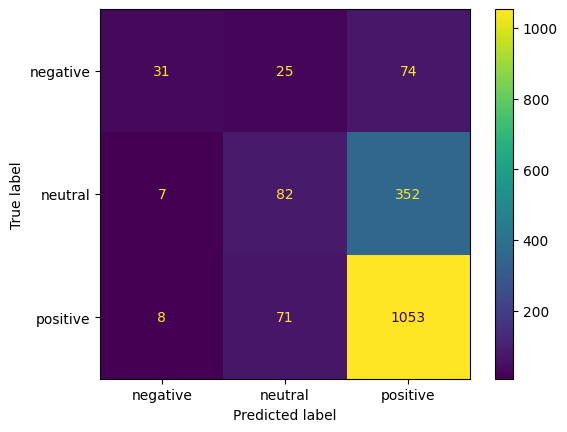

Create new IF model for fold 4: multiple-densenet201-bert-lstm_fold4.h5
Model: "model_214"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_269 (InputLayer)      [(None, 768)]                0         []                            
                                                                                                  
 dropout_456 (Dropout)       (None, 768)                  0         ['input_269[0][0]']           
                                                                                                  
 reshape_188 (Reshape)       (None, 1, 768)               0         ['dropout_456[0][0]']         
                                                                                                  
 lstm_134 (LSTM)             (None, 256)                  1049600   ['reshape_188[0][0]']         
                  

/usr/local/lib/python3.10/dist-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


['positive' 'positive' 'positive' ... 'neutral' 'positive' 'positive']
[2 2 2 ... 1 2 2]
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 ...
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]]


In [ ]:
print('----------------------------------------')
print('\nMVSA-Multiple with Intermediate Fusion')
scores = []
for i in range(len(feature_names)):
    print('MVSA-Multiple:', feature_names[i])
    if 'lstm' in feature_names[i]:
        _, score = run_and_evaluate_IF_cv('multiple-IF-' + feature_names[i],
                                       mvsa_multiple_features[i][0],
                                       mvsa_multiple_features[i][1],
                                       mvsa_multiple_multimodal_labels,
                                       verbose=VERBOSE, lstm=True)
    else:
        _, score = run_and_evaluate_IF_cv('multiple-IF-' + feature_names[i],
                                       mvsa_multiple_features[i][0],
                                       mvsa_multiple_features[i][1],
                                       mvsa_multiple_multimodal_labels,
                                       verbose=VERBOSE, lstm=False)
    scores.append(np.mean(score,axis=0))
df0_multiple_scores_IF = pd.DataFrame(scores, columns=['Accuracy', 'F1-macro', 'F1-weighted'], index=feature_names)

In [ ]:
df0_multiple_scores_IF

# Late Fusion

MVSA-Single with Late Fusion
MVSA-Single: densenet201-bert-pos-ner-lstm

Training and evaluating fold 1
Create new text model for fold 1: single-LF-densenet201-bert-pos-ner-lstm_fold_1_text.h5
Epoch 1/100
32/38 [========================>.....] - ETA: 0s - loss: 1.0986 - accuracy: 0.3594 - f1_macro: 0.3313 - f1_weighted: 0.3600
Epoch 1: val_loss improved from inf to 1.14843, saving model to ./model_checkpoint/single-LF-densenet201-bert-pos-ner-lstm_fold_1_text.h5
38/38 [==============================] - 6s 25ms/step - loss: 1.0965 - accuracy: 0.3628 - f1_macro: 0.3310 - f1_weighted: 0.3614 - val_loss: 1.1484 - val_accuracy: 0.2444 - val_f1_macro: 0.1849 - val_f1_weighted: 0.2524
Epoch 2/100
23/38 [=================>............] - ETA: 0s - loss: 1.0681 - accuracy: 0.4093 - f1_macro: 0.3181 - f1_weighted: 0.3784

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


33/38 [=========================>....] - ETA: 0s - loss: 1.0686 - accuracy: 0.4115 - f1_macro: 0.3202 - f1_weighted: 0.3774
Epoch 2: val_loss did not improve from 1.14843
38/38 [==============================] - 0s 6ms/step - loss: 1.0672 - accuracy: 0.4125 - f1_macro: 0.3199 - f1_weighted: 0.3774 - val_loss: 1.1850 - val_accuracy: 0.2741 - val_f1_macro: 0.2006 - val_f1_weighted: 0.2789
Epoch 3/100
34/38 [=========================>....] - ETA: 0s - loss: 1.0529 - accuracy: 0.4251 - f1_macro: 0.3186 - f1_weighted: 0.3833
Epoch 3: val_loss did not improve from 1.14843
38/38 [==============================] - 0s 6ms/step - loss: 1.0535 - accuracy: 0.4274 - f1_macro: 0.3202 - f1_weighted: 0.3845 - val_loss: 1.2008 - val_accuracy: 0.3136 - val_f1_macro: 0.2223 - val_f1_weighted: 0.3113
Epoch 4/100
32/38 [========================>.....] - ETA: 0s - loss: 1.0475 - accuracy: 0.4314 - f1_macro: 0.3237 - f1_weighted: 0.3880
Epoch 4: val_loss did not improve from 1.14843
38/38 [==================

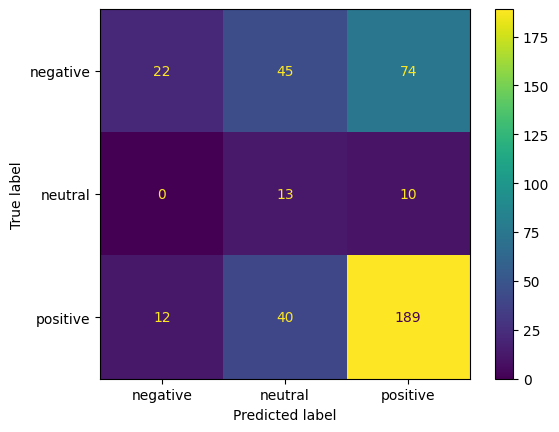


Training and evaluating fold 2
Create new text model for fold 2: single-LF-densenet201-bert-pos-ner-lstm_fold_2_text.h5
Epoch 1/100
38/38 [==============================] - ETA: 0s - loss: 1.0926 - accuracy: 0.3797 - f1_macro: 0.3489 - f1_weighted: 0.3785
Epoch 1: val_loss improved from inf to 1.12958, saving model to ./model_checkpoint/single-LF-densenet201-bert-pos-ner-lstm_fold_2_text.h5
38/38 [==============================] - 5s 39ms/step - loss: 1.0926 - accuracy: 0.3797 - f1_macro: 0.3489 - f1_weighted: 0.3785 - val_loss: 1.1296 - val_accuracy: 0.3399 - val_f1_macro: 0.2325 - val_f1_weighted: 0.3494
Epoch 2/100
 7/38 [====>.........................] - ETA: 0s - loss: 1.0497 - accuracy: 0.4643 - f1_macro: 0.3522 - f1_weighted: 0.4265

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


33/38 [=========================>....] - ETA: 0s - loss: 1.0581 - accuracy: 0.4290 - f1_macro: 0.3249 - f1_weighted: 0.3885
Epoch 2: val_loss did not improve from 1.12958
38/38 [==============================] - 0s 12ms/step - loss: 1.0596 - accuracy: 0.4275 - f1_macro: 0.3241 - f1_weighted: 0.3862 - val_loss: 1.1617 - val_accuracy: 0.3251 - val_f1_macro: 0.2273 - val_f1_weighted: 0.3431
Epoch 3/100
36/38 [===========================>..] - ETA: 0s - loss: 1.0511 - accuracy: 0.4377 - f1_macro: 0.3302 - f1_weighted: 0.3940
Epoch 3: val_loss did not improve from 1.12958
38/38 [==============================] - 0s 13ms/step - loss: 1.0523 - accuracy: 0.4346 - f1_macro: 0.3277 - f1_weighted: 0.3909 - val_loss: 1.1809 - val_accuracy: 0.2709 - val_f1_macro: 0.2045 - val_f1_weighted: 0.2990
Epoch 4/100
36/38 [===========================>..] - ETA: 0s - loss: 1.0404 - accuracy: 0.4379 - f1_macro: 0.3281 - f1_weighted: 0.3932
Epoch 4: val_loss did not improve from 1.12958
38/38 [================

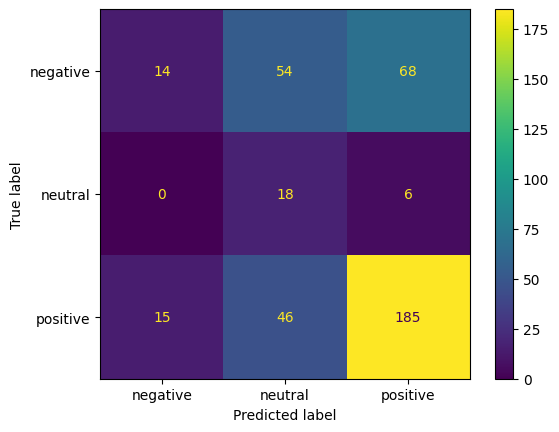


Training and evaluating fold 3
Create new text model for fold 3: single-LF-densenet201-bert-pos-ner-lstm_fold_3_text.h5
Epoch 1/100
33/38 [=========================>....] - ETA: 0s - loss: 1.0907 - accuracy: 0.3847 - f1_macro: 0.3479 - f1_weighted: 0.3799
Epoch 1: val_loss improved from inf to 1.16411, saving model to ./model_checkpoint/single-LF-densenet201-bert-pos-ner-lstm_fold_3_text.h5
38/38 [==============================] - 3s 21ms/step - loss: 1.0889 - accuracy: 0.3867 - f1_macro: 0.3452 - f1_weighted: 0.3789 - val_loss: 1.1641 - val_accuracy: 0.1675 - val_f1_macro: 0.1408 - val_f1_weighted: 0.1823
Epoch 2/100
20/38 [==============>...............] - ETA: 0s - loss: 1.0790 - accuracy: 0.3996 - f1_macro: 0.3087 - f1_weighted: 0.3631

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


30/38 [======================>.......] - ETA: 0s - loss: 1.0733 - accuracy: 0.4010 - f1_macro: 0.3070 - f1_weighted: 0.3637
Epoch 2: val_loss did not improve from 1.16411
38/38 [==============================] - 0s 7ms/step - loss: 1.0704 - accuracy: 0.4066 - f1_macro: 0.3103 - f1_weighted: 0.3684 - val_loss: 1.1749 - val_accuracy: 0.3103 - val_f1_macro: 0.2211 - val_f1_weighted: 0.3174
Epoch 3/100
33/38 [=========================>....] - ETA: 0s - loss: 1.0593 - accuracy: 0.4235 - f1_macro: 0.3155 - f1_weighted: 0.3802
Epoch 3: val_loss did not improve from 1.16411
38/38 [==============================] - 0s 6ms/step - loss: 1.0592 - accuracy: 0.4268 - f1_macro: 0.3180 - f1_weighted: 0.3825 - val_loss: 1.1801 - val_accuracy: 0.3325 - val_f1_macro: 0.2329 - val_f1_weighted: 0.3351
Epoch 4/100
33/38 [=========================>....] - ETA: 0s - loss: 1.0473 - accuracy: 0.4446 - f1_macro: 0.3298 - f1_weighted: 0.3980
Epoch 4: val_loss did not improve from 1.16411
38/38 [==================

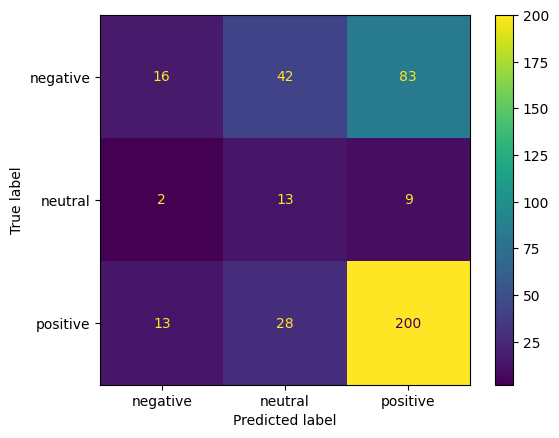


Training and evaluating fold 4
Create new text model for fold 4: single-LF-densenet201-bert-pos-ner-lstm_fold_4_text.h5
Epoch 1/100
33/38 [=========================>....] - ETA: 0s - loss: 1.0976 - accuracy: 0.3686 - f1_macro: 0.3429 - f1_weighted: 0.3689
Epoch 1: val_loss improved from inf to 1.10286, saving model to ./model_checkpoint/single-LF-densenet201-bert-pos-ner-lstm_fold_4_text.h5
38/38 [==============================] - 3s 21ms/step - loss: 1.0940 - accuracy: 0.3774 - f1_macro: 0.3473 - f1_weighted: 0.3759 - val_loss: 1.1029 - val_accuracy: 0.4236 - val_f1_macro: 0.2583 - val_f1_weighted: 0.3785
Epoch 2/100
23/38 [=================>............] - ETA: 0s - loss: 1.0678 - accuracy: 0.4144 - f1_macro: 0.3269 - f1_weighted: 0.3810

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


33/38 [=========================>....] - ETA: 0s - loss: 1.0676 - accuracy: 0.4164 - f1_macro: 0.3275 - f1_weighted: 0.3814
Epoch 2: val_loss did not improve from 1.10286
38/38 [==============================] - 0s 6ms/step - loss: 1.0642 - accuracy: 0.4190 - f1_macro: 0.3279 - f1_weighted: 0.3838 - val_loss: 1.1421 - val_accuracy: 0.3399 - val_f1_macro: 0.2293 - val_f1_weighted: 0.3358
Epoch 3/100
31/38 [=======================>......] - ETA: 0s - loss: 1.0518 - accuracy: 0.4433 - f1_macro: 0.3316 - f1_weighted: 0.3971
Epoch 3: val_loss did not improve from 1.10286
38/38 [==============================] - 0s 6ms/step - loss: 1.0491 - accuracy: 0.4455 - f1_macro: 0.3342 - f1_weighted: 0.3999 - val_loss: 1.1628 - val_accuracy: 0.3177 - val_f1_macro: 0.2225 - val_f1_weighted: 0.3258
Epoch 4/100
29/38 [=====================>........] - ETA: 0s - loss: 1.0428 - accuracy: 0.4448 - f1_macro: 0.3311 - f1_weighted: 0.3978
Epoch 4: val_loss did not improve from 1.10286
38/38 [==================

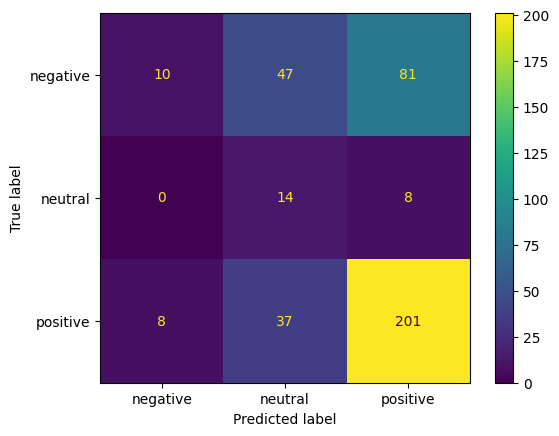


Training and evaluating fold 5
Create new text model for fold 5: single-LF-densenet201-bert-pos-ner-lstm_fold_5_text.h5
Epoch 1/100
30/38 [======================>.......] - ETA: 0s - loss: 1.0863 - accuracy: 0.3956 - f1_macro: 0.3277 - f1_weighted: 0.3677
Epoch 1: val_loss improved from inf to 1.13995, saving model to ./model_checkpoint/single-LF-densenet201-bert-pos-ner-lstm_fold_5_text.h5
38/38 [==============================] - 3s 22ms/step - loss: 1.0837 - accuracy: 0.3980 - f1_macro: 0.3269 - f1_weighted: 0.3692 - val_loss: 1.1400 - val_accuracy: 0.4975 - val_f1_macro: 0.2367 - val_f1_weighted: 0.3902
Epoch 2/100
20/38 [==============>...............] - ETA: 0s - loss: 1.0581 - accuracy: 0.4211 - f1_macro: 0.3175 - f1_weighted: 0.3812

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


30/38 [======================>.......] - ETA: 0s - loss: 1.0582 - accuracy: 0.4214 - f1_macro: 0.3151 - f1_weighted: 0.3813
Epoch 2: val_loss did not improve from 1.13995
38/38 [==============================] - 0s 7ms/step - loss: 1.0633 - accuracy: 0.4191 - f1_macro: 0.3140 - f1_weighted: 0.3777 - val_loss: 1.1935 - val_accuracy: 0.3030 - val_f1_macro: 0.2079 - val_f1_weighted: 0.2960
Epoch 3/100
32/38 [========================>.....] - ETA: 0s - loss: 1.0493 - accuracy: 0.4404 - f1_macro: 0.3267 - f1_weighted: 0.3964
Epoch 3: val_loss did not improve from 1.13995
38/38 [==============================] - 0s 6ms/step - loss: 1.0521 - accuracy: 0.4400 - f1_macro: 0.3272 - f1_weighted: 0.3954 - val_loss: 1.2085 - val_accuracy: 0.2537 - val_f1_macro: 0.1890 - val_f1_weighted: 0.2621
Epoch 4/100
31/38 [=======================>......] - ETA: 0s - loss: 1.0406 - accuracy: 0.4425 - f1_macro: 0.3257 - f1_weighted: 0.3973
Epoch 4: val_loss did not improve from 1.13995
38/38 [==================

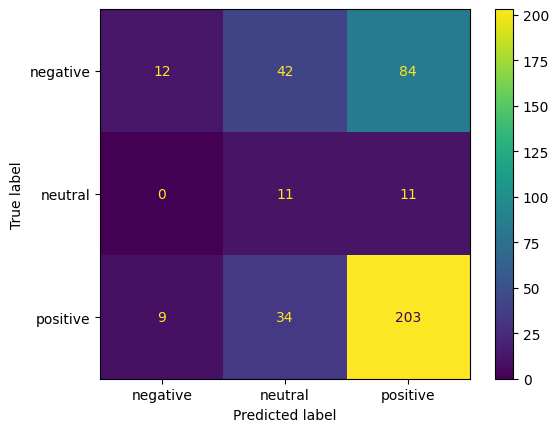


Training and evaluating fold 6
Create new text model for fold 6: single-LF-densenet201-bert-pos-ner-lstm_fold_6_text.h5
Epoch 1/100
32/38 [========================>.....] - ETA: 0s - loss: 1.0716 - accuracy: 0.4048 - f1_macro: 0.3467 - f1_weighted: 0.3884
Epoch 1: val_loss improved from inf to 1.13144, saving model to ./model_checkpoint/single-LF-densenet201-bert-pos-ner-lstm_fold_6_text.h5
38/38 [==============================] - 4s 29ms/step - loss: 1.0723 - accuracy: 0.4072 - f1_macro: 0.3453 - f1_weighted: 0.3880 - val_loss: 1.1314 - val_accuracy: 0.4113 - val_f1_macro: 0.2564 - val_f1_weighted: 0.3616
Epoch 2/100
17/38 [============>.................] - ETA: 0s - loss: 1.0592 - accuracy: 0.4164 - f1_macro: 0.3218 - f1_weighted: 0.3779

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


34/38 [=========================>....] - ETA: 0s - loss: 1.0571 - accuracy: 0.4187 - f1_macro: 0.3184 - f1_weighted: 0.3790
Epoch 2: val_loss did not improve from 1.13144
38/38 [==============================] - 0s 9ms/step - loss: 1.0563 - accuracy: 0.4197 - f1_macro: 0.3196 - f1_weighted: 0.3802 - val_loss: 1.1501 - val_accuracy: 0.4212 - val_f1_macro: 0.2615 - val_f1_weighted: 0.3693
Epoch 3/100
36/38 [===========================>..] - ETA: 0s - loss: 1.0487 - accuracy: 0.4316 - f1_macro: 0.3222 - f1_weighted: 0.3873
Epoch 3: val_loss did not improve from 1.13144
38/38 [==============================] - 1s 24ms/step - loss: 1.0481 - accuracy: 0.4349 - f1_macro: 0.3244 - f1_weighted: 0.3902 - val_loss: 1.1648 - val_accuracy: 0.3990 - val_f1_macro: 0.2548 - val_f1_weighted: 0.3617
Epoch 4/100
38/38 [==============================] - ETA: 0s - loss: 1.0377 - accuracy: 0.4531 - f1_macro: 0.3389 - f1_weighted: 0.4068
Epoch 4: val_loss did not improve from 1.13144
38/38 [=================

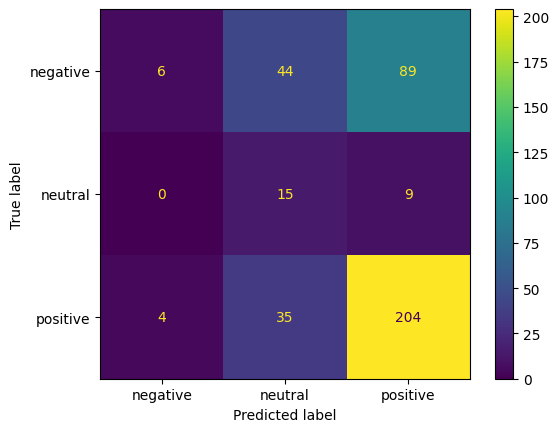


Training and evaluating fold 7
Create new text model for fold 7: single-LF-densenet201-bert-pos-ner-lstm_fold_7_text.h5
Epoch 1/100
32/38 [========================>.....] - ETA: 0s - loss: 1.0954 - accuracy: 0.3640 - f1_macro: 0.3410 - f1_weighted: 0.3707
Epoch 1: val_loss improved from inf to 1.12010, saving model to ./model_checkpoint/single-LF-densenet201-bert-pos-ner-lstm_fold_7_text.h5
38/38 [==============================] - 3s 21ms/step - loss: 1.0924 - accuracy: 0.3704 - f1_macro: 0.3413 - f1_weighted: 0.3732 - val_loss: 1.1201 - val_accuracy: 0.4655 - val_f1_macro: 0.2714 - val_f1_weighted: 0.3922
Epoch 2/100
21/38 [===============>..............] - ETA: 0s - loss: 1.0642 - accuracy: 0.4230 - f1_macro: 0.3314 - f1_weighted: 0.3904

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


31/38 [=======================>......] - ETA: 0s - loss: 1.0638 - accuracy: 0.4224 - f1_macro: 0.3275 - f1_weighted: 0.3872
Epoch 2: val_loss did not improve from 1.12010
38/38 [==============================] - 0s 7ms/step - loss: 1.0641 - accuracy: 0.4188 - f1_macro: 0.3237 - f1_weighted: 0.3827 - val_loss: 1.1569 - val_accuracy: 0.4039 - val_f1_macro: 0.2562 - val_f1_weighted: 0.3666
Epoch 3/100
30/38 [======================>.......] - ETA: 0s - loss: 1.0525 - accuracy: 0.4310 - f1_macro: 0.3235 - f1_weighted: 0.3874
Epoch 3: val_loss did not improve from 1.12010
38/38 [==============================] - 0s 7ms/step - loss: 1.0490 - accuracy: 0.4360 - f1_macro: 0.3263 - f1_weighted: 0.3916 - val_loss: 1.1677 - val_accuracy: 0.4089 - val_f1_macro: 0.2584 - val_f1_weighted: 0.3686
Epoch 4/100
31/38 [=======================>......] - ETA: 0s - loss: 1.0381 - accuracy: 0.4561 - f1_macro: 0.3365 - f1_weighted: 0.4079
Epoch 4: val_loss did not improve from 1.12010
38/38 [==================

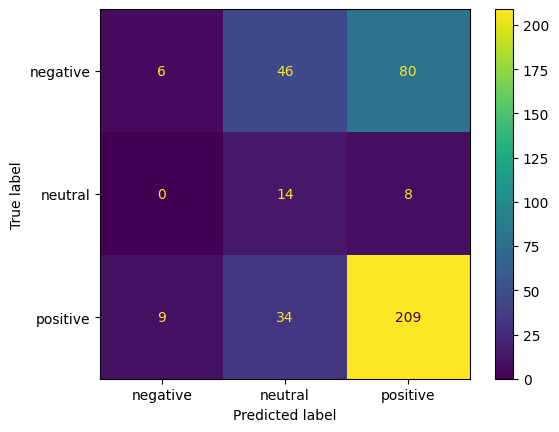


Training and evaluating fold 8
Create new text model for fold 8: single-LF-densenet201-bert-pos-ner-lstm_fold_8_text.h5
Epoch 1/100
30/38 [======================>.......] - ETA: 0s - loss: 1.0919 - accuracy: 0.3763 - f1_macro: 0.3493 - f1_weighted: 0.3766
Epoch 1: val_loss improved from inf to 1.13914, saving model to ./model_checkpoint/single-LF-densenet201-bert-pos-ner-lstm_fold_8_text.h5
38/38 [==============================] - 3s 23ms/step - loss: 1.0894 - accuracy: 0.3802 - f1_macro: 0.3473 - f1_weighted: 0.3771 - val_loss: 1.1391 - val_accuracy: 0.3251 - val_f1_macro: 0.2420 - val_f1_weighted: 0.3179
Epoch 2/100
21/38 [===============>..............] - ETA: 0s - loss: 1.0661 - accuracy: 0.4003 - f1_macro: 0.3083 - f1_weighted: 0.3657

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


30/38 [======================>.......] - ETA: 0s - loss: 1.0658 - accuracy: 0.3992 - f1_macro: 0.3055 - f1_weighted: 0.3640
Epoch 2: val_loss did not improve from 1.13914
38/38 [==============================] - 0s 7ms/step - loss: 1.0637 - accuracy: 0.4014 - f1_macro: 0.3063 - f1_weighted: 0.3656 - val_loss: 1.1934 - val_accuracy: 0.1872 - val_f1_macro: 0.1616 - val_f1_weighted: 0.2002
Epoch 3/100
32/38 [========================>.....] - ETA: 0s - loss: 1.0510 - accuracy: 0.4268 - f1_macro: 0.3197 - f1_weighted: 0.3845
Epoch 3: val_loss did not improve from 1.13914
38/38 [==============================] - 0s 6ms/step - loss: 1.0502 - accuracy: 0.4257 - f1_macro: 0.3187 - f1_weighted: 0.3839 - val_loss: 1.1990 - val_accuracy: 0.2562 - val_f1_macro: 0.2093 - val_f1_weighted: 0.2735
Epoch 4/100
30/38 [======================>.......] - ETA: 0s - loss: 1.0446 - accuracy: 0.4349 - f1_macro: 0.3245 - f1_weighted: 0.3907
Epoch 4: val_loss did not improve from 1.13914
38/38 [==================

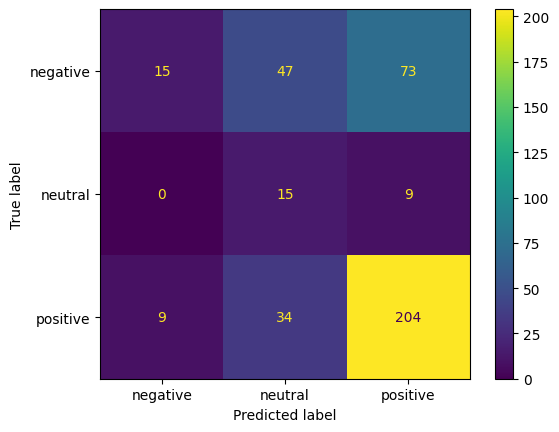


Training and evaluating fold 9
Create new text model for fold 9: single-LF-densenet201-bert-pos-ner-lstm_fold_9_text.h5
Epoch 1/100
31/38 [=======================>......] - ETA: 0s - loss: 1.0957 - accuracy: 0.3659 - f1_macro: 0.3426 - f1_weighted: 0.3701
Epoch 1: val_loss improved from inf to 1.13832, saving model to ./model_checkpoint/single-LF-densenet201-bert-pos-ner-lstm_fold_9_text.h5
38/38 [==============================] - 3s 21ms/step - loss: 1.0916 - accuracy: 0.3750 - f1_macro: 0.3445 - f1_weighted: 0.3745 - val_loss: 1.1383 - val_accuracy: 0.2315 - val_f1_macro: 0.1834 - val_f1_weighted: 0.2650
Epoch 2/100
20/38 [==============>...............] - ETA: 0s - loss: 1.0605 - accuracy: 0.4336 - f1_macro: 0.3354 - f1_weighted: 0.3967

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


30/38 [======================>.......] - ETA: 0s - loss: 1.0565 - accuracy: 0.4383 - f1_macro: 0.3388 - f1_weighted: 0.4000
Epoch 2: val_loss did not improve from 1.13832
38/38 [==============================] - 0s 7ms/step - loss: 1.0583 - accuracy: 0.4345 - f1_macro: 0.3350 - f1_weighted: 0.3942 - val_loss: 1.1534 - val_accuracy: 0.3202 - val_f1_macro: 0.2292 - val_f1_weighted: 0.3418
Epoch 3/100
32/38 [========================>.....] - ETA: 0s - loss: 1.0493 - accuracy: 0.4402 - f1_macro: 0.3347 - f1_weighted: 0.3972
Epoch 3: val_loss did not improve from 1.13832
38/38 [==============================] - 0s 6ms/step - loss: 1.0483 - accuracy: 0.4410 - f1_macro: 0.3356 - f1_weighted: 0.3973 - val_loss: 1.1583 - val_accuracy: 0.3670 - val_f1_macro: 0.2473 - val_f1_weighted: 0.3742
Epoch 4/100
29/38 [=====================>........] - ETA: 0s - loss: 1.0406 - accuracy: 0.4642 - f1_macro: 0.3474 - f1_weighted: 0.4147
Epoch 4: val_loss did not improve from 1.13832
38/38 [==================

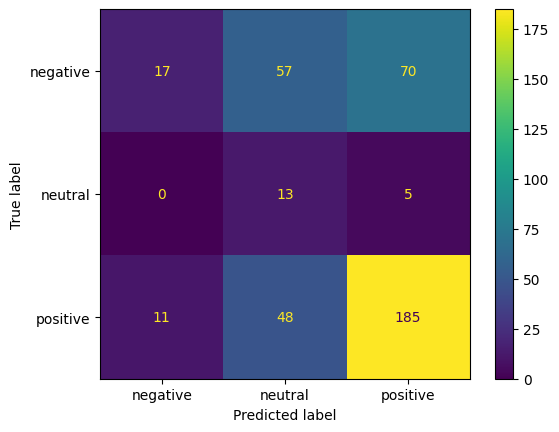


Training and evaluating fold 10
Create new text model for fold 10: single-LF-densenet201-bert-pos-ner-lstm_fold_10_text.h5
Epoch 1/100
31/38 [=======================>......] - ETA: 0s - loss: 1.0690 - accuracy: 0.4108 - f1_macro: 0.3435 - f1_weighted: 0.3881
Epoch 1: val_loss improved from inf to 1.13376, saving model to ./model_checkpoint/single-LF-densenet201-bert-pos-ner-lstm_fold_10_text.h5
38/38 [==============================] - 3s 22ms/step - loss: 1.0666 - accuracy: 0.4164 - f1_macro: 0.3432 - f1_weighted: 0.3901 - val_loss: 1.1338 - val_accuracy: 0.4877 - val_f1_macro: 0.2805 - val_f1_weighted: 0.3981
Epoch 2/100
19/38 [==============>...............] - ETA: 0s - loss: 1.0606 - accuracy: 0.4202 - f1_macro: 0.3158 - f1_weighted: 0.3735

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


38/38 [==============================] - ETA: 0s - loss: 1.0503 - accuracy: 0.4367 - f1_macro: 0.3249 - f1_weighted: 0.3915
Epoch 2: val_loss did not improve from 1.13376
38/38 [==============================] - 0s 7ms/step - loss: 1.0503 - accuracy: 0.4367 - f1_macro: 0.3249 - f1_weighted: 0.3915 - val_loss: 1.1666 - val_accuracy: 0.4261 - val_f1_macro: 0.2676 - val_f1_weighted: 0.3783
Epoch 3/100
31/38 [=======================>......] - ETA: 0s - loss: 1.0396 - accuracy: 0.4579 - f1_macro: 0.3400 - f1_weighted: 0.4101
Epoch 3: val_loss did not improve from 1.13376
38/38 [==============================] - 0s 6ms/step - loss: 1.0393 - accuracy: 0.4623 - f1_macro: 0.3434 - f1_weighted: 0.4144 - val_loss: 1.1802 - val_accuracy: 0.3793 - val_f1_macro: 0.2513 - val_f1_weighted: 0.3524
Epoch 4/100
31/38 [=======================>......] - ETA: 0s - loss: 1.0359 - accuracy: 0.4617 - f1_macro: 0.3437 - f1_weighted: 0.4136
Epoch 4: val_loss did not improve from 1.13376
38/38 [==================

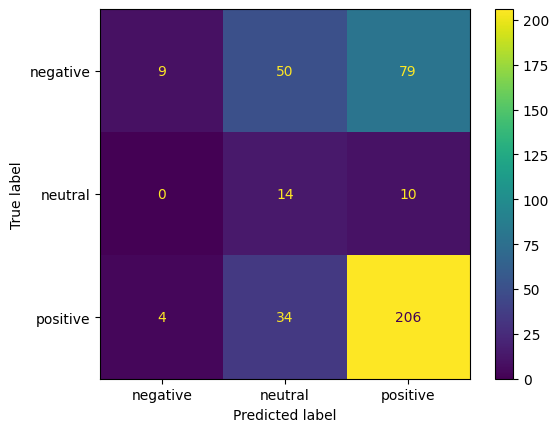


MVSA-Single: densenet201-bert-lstm

Training and evaluating fold 1
Create new text model for fold 1: single-LF-densenet201-bert-lstm_fold_1_text.h5
Epoch 1/100
35/38 [==========================>...] - ETA: 0s - loss: 1.0935 - accuracy: 0.3607 - f1_macro: 0.3310 - f1_weighted: 0.3601
Epoch 1: val_loss improved from inf to 1.13696, saving model to ./model_checkpoint/single-LF-densenet201-bert-lstm_fold_1_text.h5
38/38 [==============================] - 3s 23ms/step - loss: 1.0916 - accuracy: 0.3632 - f1_macro: 0.3317 - f1_weighted: 0.3615 - val_loss: 1.1370 - val_accuracy: 0.4543 - val_f1_macro: 0.2559 - val_f1_weighted: 0.3692
Epoch 2/100
19/38 [==============>...............] - ETA: 0s - loss: 1.0632 - accuracy: 0.4087 - f1_macro: 0.3315 - f1_weighted: 0.3837

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


38/38 [==============================] - ETA: 0s - loss: 1.0659 - accuracy: 0.4073 - f1_macro: 0.3209 - f1_weighted: 0.3754
Epoch 2: val_loss did not improve from 1.13696
38/38 [==============================] - 0s 7ms/step - loss: 1.0659 - accuracy: 0.4073 - f1_macro: 0.3209 - f1_weighted: 0.3754 - val_loss: 1.1849 - val_accuracy: 0.3827 - val_f1_macro: 0.2514 - val_f1_weighted: 0.3498
Epoch 3/100
32/38 [========================>.....] - ETA: 0s - loss: 1.0518 - accuracy: 0.4285 - f1_macro: 0.3249 - f1_weighted: 0.3882
Epoch 3: val_loss did not improve from 1.13696
38/38 [==============================] - 0s 7ms/step - loss: 1.0542 - accuracy: 0.4247 - f1_macro: 0.3224 - f1_weighted: 0.3842 - val_loss: 1.2045 - val_accuracy: 0.3481 - val_f1_macro: 0.2437 - val_f1_weighted: 0.3346
Epoch 4/100
38/38 [==============================] - ETA: 0s - loss: 1.0424 - accuracy: 0.4347 - f1_macro: 0.3306 - f1_weighted: 0.3931
Epoch 4: val_loss did not improve from 1.13696
38/38 [==================

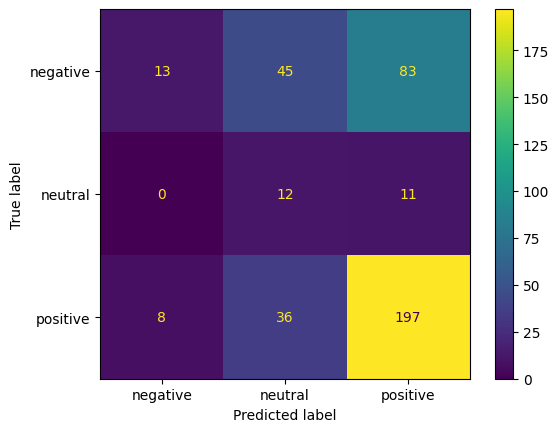


Training and evaluating fold 2
Create new text model for fold 2: single-LF-densenet201-bert-lstm_fold_2_text.h5
Epoch 1/100
29/38 [=====================>........] - ETA: 0s - loss: 1.0868 - accuracy: 0.3895 - f1_macro: 0.3346 - f1_weighted: 0.3732
Epoch 1: val_loss improved from inf to 1.11309, saving model to ./model_checkpoint/single-LF-densenet201-bert-lstm_fold_2_text.h5
38/38 [==============================] - 3s 22ms/step - loss: 1.0869 - accuracy: 0.3856 - f1_macro: 0.3262 - f1_weighted: 0.3657 - val_loss: 1.1131 - val_accuracy: 0.4975 - val_f1_macro: 0.2549 - val_f1_weighted: 0.4065
Epoch 2/100
20/38 [==============>...............] - ETA: 0s - loss: 1.0631 - accuracy: 0.4066 - f1_macro: 0.3073 - f1_weighted: 0.3678

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


38/38 [==============================] - ETA: 0s - loss: 1.0614 - accuracy: 0.4121 - f1_macro: 0.3101 - f1_weighted: 0.3701
Epoch 2: val_loss did not improve from 1.11309
38/38 [==============================] - 0s 7ms/step - loss: 1.0614 - accuracy: 0.4121 - f1_macro: 0.3101 - f1_weighted: 0.3701 - val_loss: 1.1529 - val_accuracy: 0.4089 - val_f1_macro: 0.2487 - val_f1_weighted: 0.3748
Epoch 3/100
37/38 [============================>.] - ETA: 0s - loss: 1.0513 - accuracy: 0.4360 - f1_macro: 0.3275 - f1_weighted: 0.3917
Epoch 3: val_loss did not improve from 1.11309
38/38 [==============================] - 0s 7ms/step - loss: 1.0521 - accuracy: 0.4354 - f1_macro: 0.3271 - f1_weighted: 0.3909 - val_loss: 1.1712 - val_accuracy: 0.3670 - val_f1_macro: 0.2428 - val_f1_weighted: 0.3555
Epoch 4/100
31/38 [=======================>......] - ETA: 0s - loss: 1.0413 - accuracy: 0.4453 - f1_macro: 0.3328 - f1_weighted: 0.3995
Epoch 4: val_loss did not improve from 1.11309
38/38 [==================

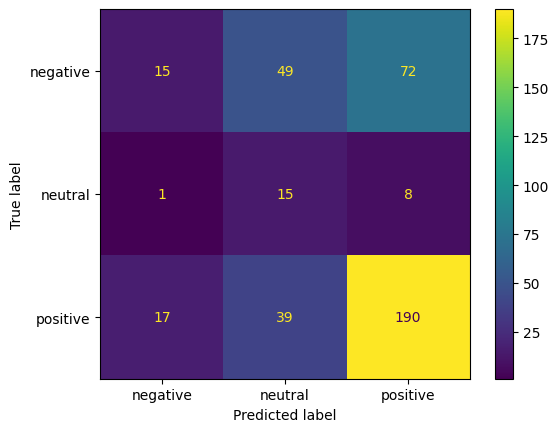


Training and evaluating fold 3
Create new text model for fold 3: single-LF-densenet201-bert-lstm_fold_3_text.h5
Epoch 1/100
31/38 [=======================>......] - ETA: 0s - loss: 1.0747 - accuracy: 0.3891 - f1_macro: 0.3449 - f1_weighted: 0.3790
Epoch 1: val_loss improved from inf to 1.18556, saving model to ./model_checkpoint/single-LF-densenet201-bert-lstm_fold_3_text.h5
38/38 [==============================] - 3s 22ms/step - loss: 1.0744 - accuracy: 0.3885 - f1_macro: 0.3397 - f1_weighted: 0.3754 - val_loss: 1.1856 - val_accuracy: 0.1404 - val_f1_macro: 0.1193 - val_f1_weighted: 0.1474
Epoch 2/100
20/38 [==============>...............] - ETA: 0s - loss: 1.0663 - accuracy: 0.4031 - f1_macro: 0.3151 - f1_weighted: 0.3681

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


36/38 [===========================>..] - ETA: 0s - loss: 1.0590 - accuracy: 0.4184 - f1_macro: 0.3245 - f1_weighted: 0.3822
Epoch 2: val_loss did not improve from 1.18556
38/38 [==============================] - 0s 8ms/step - loss: 1.0607 - accuracy: 0.4168 - f1_macro: 0.3234 - f1_weighted: 0.3803 - val_loss: 1.1945 - val_accuracy: 0.2660 - val_f1_macro: 0.2050 - val_f1_weighted: 0.2851
Epoch 3/100
32/38 [========================>.....] - ETA: 0s - loss: 1.0536 - accuracy: 0.4246 - f1_macro: 0.3166 - f1_weighted: 0.3816
Epoch 3: val_loss did not improve from 1.18556
38/38 [==============================] - 0s 8ms/step - loss: 1.0547 - accuracy: 0.4234 - f1_macro: 0.3164 - f1_weighted: 0.3798 - val_loss: 1.1965 - val_accuracy: 0.2882 - val_f1_macro: 0.2148 - val_f1_weighted: 0.3007
Epoch 4/100
36/38 [===========================>..] - ETA: 0s - loss: 1.0425 - accuracy: 0.4473 - f1_macro: 0.3359 - f1_weighted: 0.4025
Epoch 4: val_loss did not improve from 1.18556
38/38 [==================

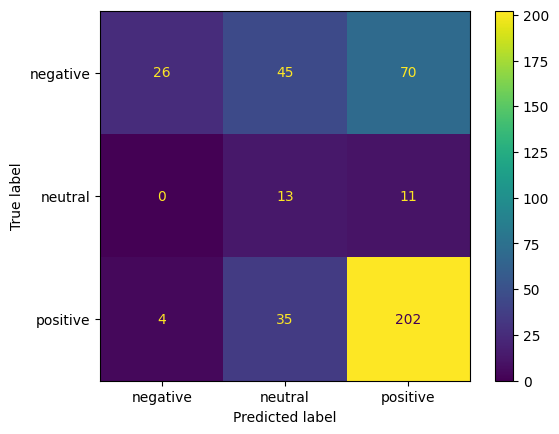


Training and evaluating fold 4
Create new text model for fold 4: single-LF-densenet201-bert-lstm_fold_4_text.h5
Epoch 1/100
33/38 [=========================>....] - ETA: 0s - loss: 1.1141 - accuracy: 0.3435 - f1_macro: 0.3409 - f1_weighted: 0.3567
Epoch 1: val_loss improved from inf to 1.09442, saving model to ./model_checkpoint/single-LF-densenet201-bert-lstm_fold_4_text.h5
38/38 [==============================] - 5s 54ms/step - loss: 1.1117 - accuracy: 0.3503 - f1_macro: 0.3443 - f1_weighted: 0.3617 - val_loss: 1.0944 - val_accuracy: 0.4458 - val_f1_macro: 0.2393 - val_f1_weighted: 0.3854
Epoch 2/100
12/38 [========>.....................] - ETA: 0s - loss: 1.0810 - accuracy: 0.3906 - f1_macro: 0.3300 - f1_weighted: 0.3721

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


34/38 [=========================>....] - ETA: 0s - loss: 1.0753 - accuracy: 0.3987 - f1_macro: 0.3252 - f1_weighted: 0.3732
Epoch 2: val_loss did not improve from 1.09442
38/38 [==============================] - 0s 11ms/step - loss: 1.0729 - accuracy: 0.4030 - f1_macro: 0.3262 - f1_weighted: 0.3768 - val_loss: 1.1350 - val_accuracy: 0.3990 - val_f1_macro: 0.2433 - val_f1_weighted: 0.3733
Epoch 3/100
38/38 [==============================] - ETA: 0s - loss: 1.0585 - accuracy: 0.4165 - f1_macro: 0.3174 - f1_weighted: 0.3768
Epoch 3: val_loss did not improve from 1.09442
38/38 [==============================] - 0s 11ms/step - loss: 1.0585 - accuracy: 0.4165 - f1_macro: 0.3174 - f1_weighted: 0.3768 - val_loss: 1.1553 - val_accuracy: 0.3941 - val_f1_macro: 0.2463 - val_f1_weighted: 0.3770
Epoch 4/100
35/38 [==========================>...] - ETA: 0s - loss: 1.0565 - accuracy: 0.4221 - f1_macro: 0.3186 - f1_weighted: 0.3798
Epoch 4: val_loss did not improve from 1.09442
38/38 [================

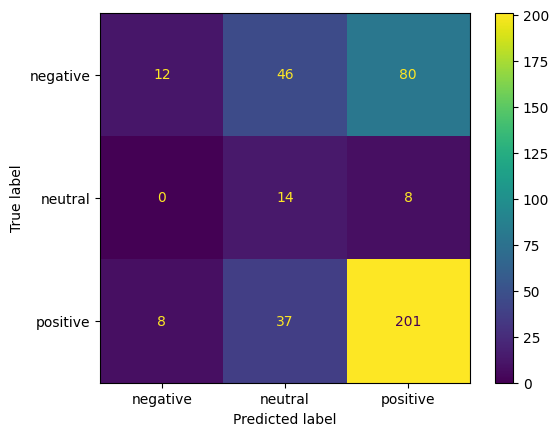


Training and evaluating fold 5
Create new text model for fold 5: single-LF-densenet201-bert-lstm_fold_5_text.h5
Epoch 1/100
30/38 [======================>.......] - ETA: 0s - loss: 1.0959 - accuracy: 0.3797 - f1_macro: 0.3522 - f1_weighted: 0.3812
Epoch 1: val_loss improved from inf to 1.14329, saving model to ./model_checkpoint/single-LF-densenet201-bert-lstm_fold_5_text.h5
38/38 [==============================] - 3s 22ms/step - loss: 1.0896 - accuracy: 0.3848 - f1_macro: 0.3487 - f1_weighted: 0.3811 - val_loss: 1.1433 - val_accuracy: 0.2882 - val_f1_macro: 0.2078 - val_f1_weighted: 0.3043
Epoch 2/100
21/38 [===============>..............] - ETA: 0s - loss: 1.0612 - accuracy: 0.4237 - f1_macro: 0.3354 - f1_weighted: 0.3913

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


30/38 [======================>.......] - ETA: 0s - loss: 1.0589 - accuracy: 0.4266 - f1_macro: 0.3344 - f1_weighted: 0.3928
Epoch 2: val_loss did not improve from 1.14329
38/38 [==============================] - 0s 7ms/step - loss: 1.0604 - accuracy: 0.4239 - f1_macro: 0.3305 - f1_weighted: 0.3882 - val_loss: 1.1682 - val_accuracy: 0.3498 - val_f1_macro: 0.2348 - val_f1_weighted: 0.3461
Epoch 3/100
29/38 [=====================>........] - ETA: 0s - loss: 1.0461 - accuracy: 0.4195 - f1_macro: 0.3143 - f1_weighted: 0.3781
Epoch 3: val_loss did not improve from 1.14329
38/38 [==============================] - 0s 7ms/step - loss: 1.0453 - accuracy: 0.4243 - f1_macro: 0.3167 - f1_weighted: 0.3818 - val_loss: 1.1861 - val_accuracy: 0.3448 - val_f1_macro: 0.2368 - val_f1_weighted: 0.3424
Epoch 4/100
30/38 [======================>.......] - ETA: 0s - loss: 1.0335 - accuracy: 0.4445 - f1_macro: 0.3321 - f1_weighted: 0.4010
Epoch 4: val_loss did not improve from 1.14329
38/38 [==================

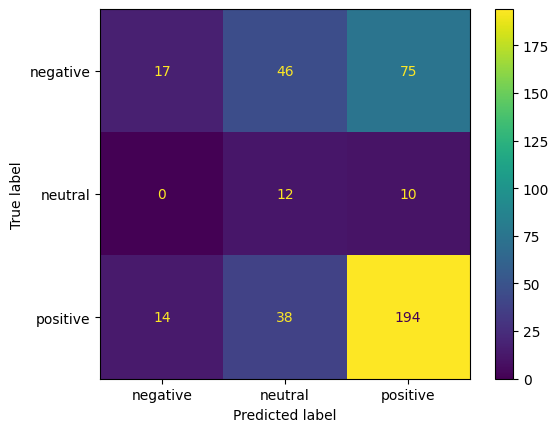


Training and evaluating fold 6
Create new text model for fold 6: single-LF-densenet201-bert-lstm_fold_6_text.h5
Epoch 1/100
38/38 [==============================] - ETA: 0s - loss: 1.1248 - accuracy: 0.3318 - f1_macro: 0.3307 - f1_weighted: 0.3506
Epoch 1: val_loss improved from inf to 1.11111, saving model to ./model_checkpoint/single-LF-densenet201-bert-lstm_fold_6_text.h5
38/38 [==============================] - 4s 32ms/step - loss: 1.1248 - accuracy: 0.3318 - f1_macro: 0.3307 - f1_weighted: 0.3506 - val_loss: 1.1111 - val_accuracy: 0.3941 - val_f1_macro: 0.2306 - val_f1_weighted: 0.3556
Epoch 2/100
14/38 [==========>...................] - ETA: 0s - loss: 1.0828 - accuracy: 0.4102 - f1_macro: 0.3390 - f1_weighted: 0.3886

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


38/38 [==============================] - ETA: 0s - loss: 1.0752 - accuracy: 0.4076 - f1_macro: 0.3309 - f1_weighted: 0.3819
Epoch 2: val_loss did not improve from 1.11111
38/38 [==============================] - 0s 10ms/step - loss: 1.0752 - accuracy: 0.4076 - f1_macro: 0.3309 - f1_weighted: 0.3819 - val_loss: 1.1489 - val_accuracy: 0.4138 - val_f1_macro: 0.2485 - val_f1_weighted: 0.3658
Epoch 3/100
31/38 [=======================>......] - ETA: 0s - loss: 1.0605 - accuracy: 0.4302 - f1_macro: 0.3269 - f1_weighted: 0.3892
Epoch 3: val_loss did not improve from 1.11111
38/38 [==============================] - 0s 9ms/step - loss: 1.0579 - accuracy: 0.4340 - f1_macro: 0.3305 - f1_weighted: 0.3929 - val_loss: 1.1695 - val_accuracy: 0.3916 - val_f1_macro: 0.2482 - val_f1_weighted: 0.3556
Epoch 4/100
35/38 [==========================>...] - ETA: 0s - loss: 1.0498 - accuracy: 0.4355 - f1_macro: 0.3241 - f1_weighted: 0.3915
Epoch 4: val_loss did not improve from 1.11111
38/38 [=================

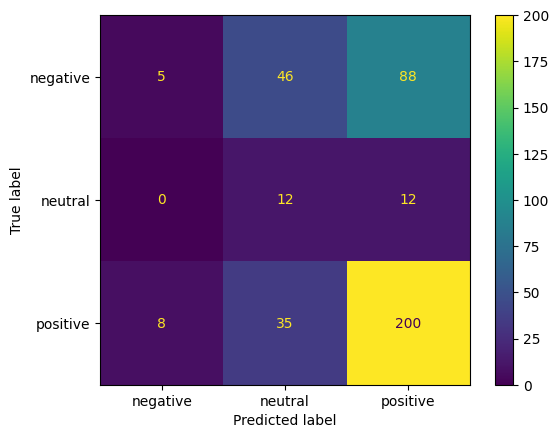


Training and evaluating fold 7
Create new text model for fold 7: single-LF-densenet201-bert-lstm_fold_7_text.h5
Epoch 1/100
36/38 [===========================>..] - ETA: 0s - loss: 1.0953 - accuracy: 0.3694 - f1_macro: 0.3452 - f1_weighted: 0.3723
Epoch 1: val_loss improved from inf to 1.10338, saving model to ./model_checkpoint/single-LF-densenet201-bert-lstm_fold_7_text.h5
38/38 [==============================] - 4s 30ms/step - loss: 1.0942 - accuracy: 0.3698 - f1_macro: 0.3444 - f1_weighted: 0.3718 - val_loss: 1.1034 - val_accuracy: 0.4975 - val_f1_macro: 0.2611 - val_f1_weighted: 0.4100
Epoch 2/100
17/38 [============>.................] - ETA: 0s - loss: 1.0586 - accuracy: 0.4338 - f1_macro: 0.3463 - f1_weighted: 0.4031

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


38/38 [==============================] - ETA: 0s - loss: 1.0609 - accuracy: 0.4246 - f1_macro: 0.3323 - f1_weighted: 0.3894
Epoch 2: val_loss did not improve from 1.10338
38/38 [==============================] - 0s 10ms/step - loss: 1.0609 - accuracy: 0.4246 - f1_macro: 0.3323 - f1_weighted: 0.3894 - val_loss: 1.1405 - val_accuracy: 0.4557 - val_f1_macro: 0.2674 - val_f1_weighted: 0.3956
Epoch 3/100
35/38 [==========================>...] - ETA: 0s - loss: 1.0500 - accuracy: 0.4295 - f1_macro: 0.3198 - f1_weighted: 0.3850
Epoch 3: val_loss did not improve from 1.10338
38/38 [==============================] - 0s 11ms/step - loss: 1.0496 - accuracy: 0.4323 - f1_macro: 0.3219 - f1_weighted: 0.3875 - val_loss: 1.1567 - val_accuracy: 0.4138 - val_f1_macro: 0.2494 - val_f1_weighted: 0.3753
Epoch 4/100
36/38 [===========================>..] - ETA: 0s - loss: 1.0402 - accuracy: 0.4473 - f1_macro: 0.3323 - f1_weighted: 0.4005
Epoch 4: val_loss did not improve from 1.10338
38/38 [================

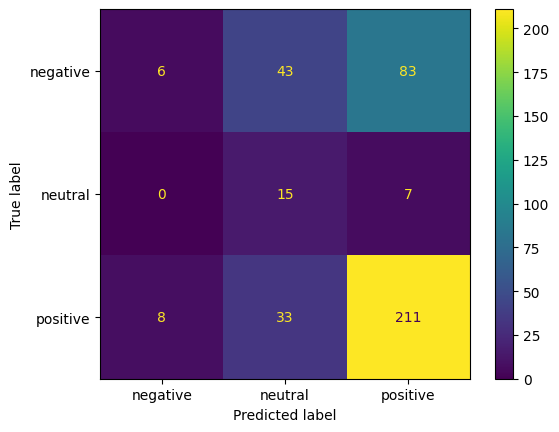


Training and evaluating fold 8
Create new text model for fold 8: single-LF-densenet201-bert-lstm_fold_8_text.h5
Epoch 1/100
34/38 [=========================>....] - ETA: 0s - loss: 1.1236 - accuracy: 0.3304 - f1_macro: 0.3300 - f1_weighted: 0.3492
Epoch 1: val_loss improved from inf to 1.11489, saving model to ./model_checkpoint/single-LF-densenet201-bert-lstm_fold_8_text.h5
38/38 [==============================] - 5s 65ms/step - loss: 1.1200 - accuracy: 0.3351 - f1_macro: 0.3323 - f1_weighted: 0.3519 - val_loss: 1.1149 - val_accuracy: 0.2931 - val_f1_macro: 0.2101 - val_f1_weighted: 0.2867
Epoch 2/100
13/38 [=========>....................] - ETA: 0s - loss: 1.0800 - accuracy: 0.4069 - f1_macro: 0.3397 - f1_weighted: 0.3878

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


32/38 [========================>.....] - ETA: 0s - loss: 1.0779 - accuracy: 0.4031 - f1_macro: 0.3306 - f1_weighted: 0.3804
Epoch 2: val_loss did not improve from 1.11489
38/38 [==============================] - 0s 11ms/step - loss: 1.0764 - accuracy: 0.4043 - f1_macro: 0.3298 - f1_weighted: 0.3799 - val_loss: 1.1660 - val_accuracy: 0.2143 - val_f1_macro: 0.1790 - val_f1_weighted: 0.2293
Epoch 3/100
38/38 [==============================] - ETA: 0s - loss: 1.0635 - accuracy: 0.4259 - f1_macro: 0.3215 - f1_weighted: 0.3856
Epoch 3: val_loss did not improve from 1.11489
38/38 [==============================] - 0s 10ms/step - loss: 1.0635 - accuracy: 0.4259 - f1_macro: 0.3215 - f1_weighted: 0.3856 - val_loss: 1.1816 - val_accuracy: 0.2488 - val_f1_macro: 0.1998 - val_f1_weighted: 0.2614
Epoch 4/100
38/38 [==============================] - ETA: 0s - loss: 1.0559 - accuracy: 0.4277 - f1_macro: 0.3218 - f1_weighted: 0.3863
Epoch 4: val_loss did not improve from 1.11489
38/38 [================

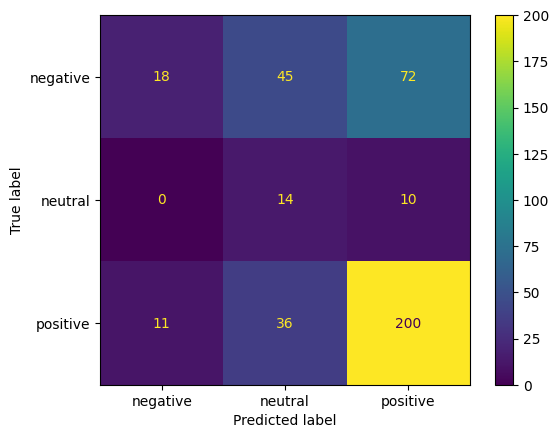


Training and evaluating fold 9
Create new text model for fold 9: single-LF-densenet201-bert-lstm_fold_9_text.h5
Epoch 1/100
37/38 [============================>.] - ETA: 0s - loss: 1.0832 - accuracy: 0.3887 - f1_macro: 0.3514 - f1_weighted: 0.3848
Epoch 1: val_loss improved from inf to 1.13880, saving model to ./model_checkpoint/single-LF-densenet201-bert-lstm_fold_9_text.h5
38/38 [==============================] - 3s 23ms/step - loss: 1.0833 - accuracy: 0.3884 - f1_macro: 0.3512 - f1_weighted: 0.3846 - val_loss: 1.1388 - val_accuracy: 0.2438 - val_f1_macro: 0.1893 - val_f1_weighted: 0.2731
Epoch 2/100
20/38 [==============>...............] - ETA: 0s - loss: 1.0591 - accuracy: 0.4266 - f1_macro: 0.3312 - f1_weighted: 0.3916

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


38/38 [==============================] - ETA: 0s - loss: 1.0615 - accuracy: 0.4233 - f1_macro: 0.3278 - f1_weighted: 0.3853
Epoch 2: val_loss did not improve from 1.13880
38/38 [==============================] - 0s 7ms/step - loss: 1.0615 - accuracy: 0.4233 - f1_macro: 0.3278 - f1_weighted: 0.3853 - val_loss: 1.1636 - val_accuracy: 0.2537 - val_f1_macro: 0.2000 - val_f1_weighted: 0.2872
Epoch 3/100
29/38 [=====================>........] - ETA: 0s - loss: 1.0538 - accuracy: 0.4324 - f1_macro: 0.3262 - f1_weighted: 0.3902
Epoch 3: val_loss did not improve from 1.13880
38/38 [==============================] - 0s 7ms/step - loss: 1.0547 - accuracy: 0.4305 - f1_macro: 0.3269 - f1_weighted: 0.3877 - val_loss: 1.1682 - val_accuracy: 0.3128 - val_f1_macro: 0.2327 - val_f1_weighted: 0.3371
Epoch 4/100
35/38 [==========================>...] - ETA: 0s - loss: 1.0471 - accuracy: 0.4462 - f1_macro: 0.3360 - f1_weighted: 0.4001
Epoch 4: val_loss did not improve from 1.13880
38/38 [==================

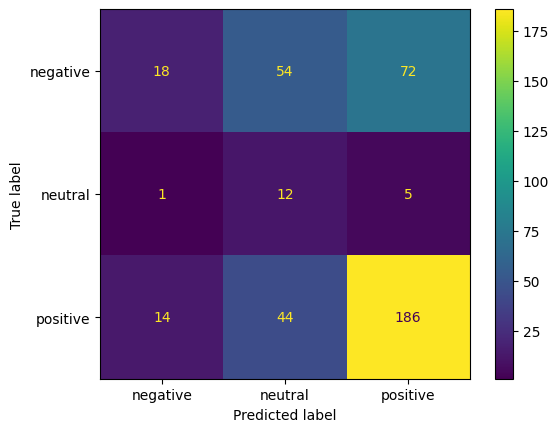


Training and evaluating fold 10
Create new text model for fold 10: single-LF-densenet201-bert-lstm_fold_10_text.h5
Epoch 1/100
38/38 [==============================] - ETA: 0s - loss: 1.0834 - accuracy: 0.3920 - f1_macro: 0.3420 - f1_weighted: 0.3766
Epoch 1: val_loss improved from inf to 1.13403, saving model to ./model_checkpoint/single-LF-densenet201-bert-lstm_fold_10_text.h5
38/38 [==============================] - 3s 22ms/step - loss: 1.0834 - accuracy: 0.3920 - f1_macro: 0.3420 - f1_weighted: 0.3766 - val_loss: 1.1340 - val_accuracy: 0.4729 - val_f1_macro: 0.2632 - val_f1_weighted: 0.3866
Epoch 2/100
20/38 [==============>...............] - ETA: 0s - loss: 1.0708 - accuracy: 0.4078 - f1_macro: 0.3152 - f1_weighted: 0.3680

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


38/38 [==============================] - ETA: 0s - loss: 1.0596 - accuracy: 0.4205 - f1_macro: 0.3224 - f1_weighted: 0.3823
Epoch 2: val_loss did not improve from 1.13403
38/38 [==============================] - 0s 7ms/step - loss: 1.0596 - accuracy: 0.4205 - f1_macro: 0.3224 - f1_weighted: 0.3823 - val_loss: 1.1811 - val_accuracy: 0.3621 - val_f1_macro: 0.2367 - val_f1_weighted: 0.3369
Epoch 3/100
29/38 [=====================>........] - ETA: 0s - loss: 1.0459 - accuracy: 0.4432 - f1_macro: 0.3325 - f1_weighted: 0.3986
Epoch 3: val_loss did not improve from 1.13403
38/38 [==============================] - 0s 7ms/step - loss: 1.0454 - accuracy: 0.4426 - f1_macro: 0.3318 - f1_weighted: 0.3986 - val_loss: 1.1981 - val_accuracy: 0.3473 - val_f1_macro: 0.2326 - val_f1_weighted: 0.3290
Epoch 4/100
35/38 [==========================>...] - ETA: 0s - loss: 1.0428 - accuracy: 0.4522 - f1_macro: 0.3392 - f1_weighted: 0.4066
Epoch 4: val_loss did not improve from 1.13403
38/38 [==================

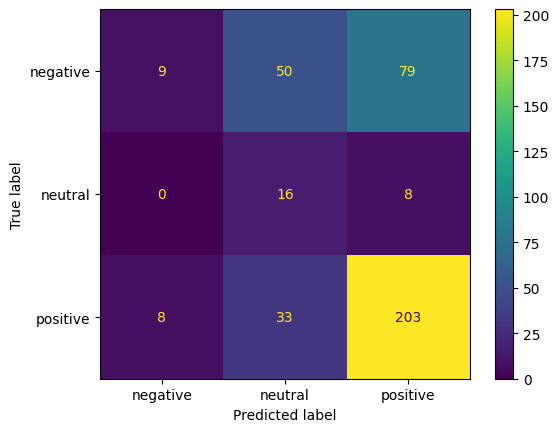


MVSA-Single: densenet201-sbert-pos-ner-lstm

Training and evaluating fold 1
Create new text model for fold 1: single-LF-densenet201-sbert-pos-ner-lstm_fold_1_text.h5
Epoch 1/100
30/38 [======================>.......] - ETA: 0s - loss: 1.0999 - accuracy: 0.3268 - f1_macro: 0.3222 - f1_weighted: 0.3388
Epoch 1: val_loss improved from inf to 1.09723, saving model to ./model_checkpoint/single-LF-densenet201-sbert-pos-ner-lstm_fold_1_text.h5
38/38 [==============================] - 3s 22ms/step - loss: 1.0996 - accuracy: 0.3277 - f1_macro: 0.3214 - f1_weighted: 0.3375 - val_loss: 1.0972 - val_accuracy: 0.3679 - val_f1_macro: 0.2681 - val_f1_weighted: 0.3810
Epoch 2/100
27/38 [====================>.........] - ETA: 0s - loss: 1.0962 - accuracy: 0.3559 - f1_macro: 0.3277 - f1_weighted: 0.3532

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


35/38 [==========================>...] - ETA: 0s - loss: 1.0961 - accuracy: 0.3567 - f1_macro: 0.3278 - f1_weighted: 0.3534
Epoch 2: val_loss did not improve from 1.09723
38/38 [==============================] - 0s 8ms/step - loss: 1.0960 - accuracy: 0.3568 - f1_macro: 0.3276 - f1_weighted: 0.3529 - val_loss: 1.0975 - val_accuracy: 0.4049 - val_f1_macro: 0.2588 - val_f1_weighted: 0.3742
Epoch 3/100
34/38 [=========================>....] - ETA: 0s - loss: 1.0919 - accuracy: 0.4035 - f1_macro: 0.3529 - f1_weighted: 0.3867
Epoch 3: val_loss did not improve from 1.09723
38/38 [==============================] - 0s 8ms/step - loss: 1.0919 - accuracy: 0.4031 - f1_macro: 0.3515 - f1_weighted: 0.3854 - val_loss: 1.0976 - val_accuracy: 0.4198 - val_f1_macro: 0.2615 - val_f1_weighted: 0.3730
Epoch 4/100
38/38 [==============================] - ETA: 0s - loss: 1.0878 - accuracy: 0.4235 - f1_macro: 0.3380 - f1_weighted: 0.3894
Epoch 4: val_loss did not improve from 1.09723
38/38 [==================

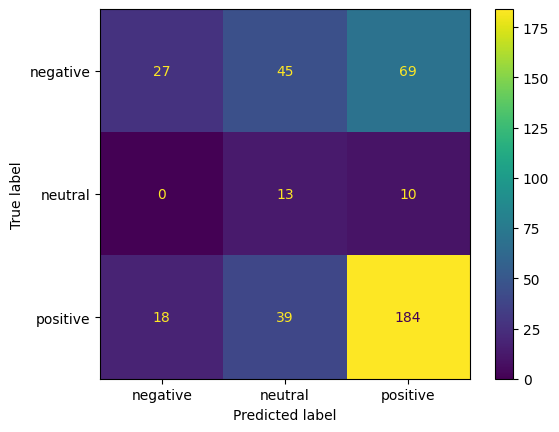


Training and evaluating fold 2
Create new text model for fold 2: single-LF-densenet201-sbert-pos-ner-lstm_fold_2_text.h5
Epoch 1/100
30/38 [======================>.......] - ETA: 0s - loss: 1.0983 - accuracy: 0.3581 - f1_macro: 0.3460 - f1_weighted: 0.3581
Epoch 1: val_loss improved from inf to 1.11060, saving model to ./model_checkpoint/single-LF-densenet201-sbert-pos-ner-lstm_fold_2_text.h5
38/38 [==============================] - 3s 22ms/step - loss: 1.0978 - accuracy: 0.3616 - f1_macro: 0.3445 - f1_weighted: 0.3563 - val_loss: 1.1106 - val_accuracy: 0.0739 - val_f1_macro: 0.0666 - val_f1_weighted: 0.0553
Epoch 2/100
17/38 [============>.................] - ETA: 0s - loss: 1.0948 - accuracy: 0.3929 - f1_macro: 0.3410 - f1_weighted: 0.3671

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


37/38 [============================>.] - ETA: 0s - loss: 1.0940 - accuracy: 0.3961 - f1_macro: 0.3416 - f1_weighted: 0.3684
Epoch 2: val_loss improved from 1.11060 to 1.11026, saving model to ./model_checkpoint/single-LF-densenet201-sbert-pos-ner-lstm_fold_2_text.h5
38/38 [==============================] - 0s 8ms/step - loss: 1.0940 - accuracy: 0.3962 - f1_macro: 0.3419 - f1_weighted: 0.3686 - val_loss: 1.1103 - val_accuracy: 0.0788 - val_f1_macro: 0.0681 - val_f1_weighted: 0.0610
Epoch 3/100
33/38 [=========================>....] - ETA: 0s - loss: 1.0903 - accuracy: 0.4119 - f1_macro: 0.3381 - f1_weighted: 0.3783
Epoch 3: val_loss did not improve from 1.11026
38/38 [==============================] - 0s 6ms/step - loss: 1.0899 - accuracy: 0.4133 - f1_macro: 0.3407 - f1_weighted: 0.3792 - val_loss: 1.1103 - val_accuracy: 0.0764 - val_f1_macro: 0.0617 - val_f1_weighted: 0.0554
Epoch 4/100
29/38 [=====================>........] - ETA: 0s - loss: 1.0868 - accuracy: 0.4432 - f1_macro: 0.347

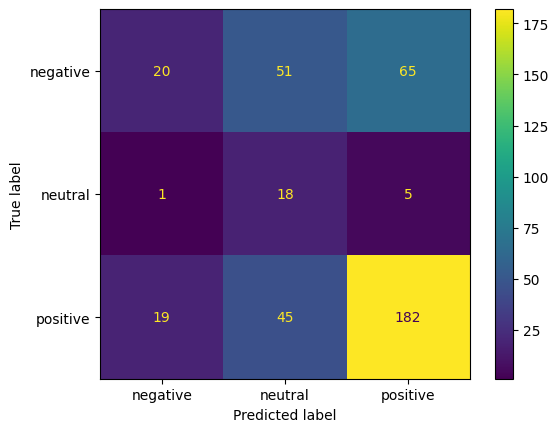


Training and evaluating fold 3
Create new text model for fold 3: single-LF-densenet201-sbert-pos-ner-lstm_fold_3_text.h5
Epoch 1/100
33/38 [=========================>....] - ETA: 0s - loss: 1.0985 - accuracy: 0.3383 - f1_macro: 0.3378 - f1_weighted: 0.3558
Epoch 1: val_loss improved from inf to 1.09628, saving model to ./model_checkpoint/single-LF-densenet201-sbert-pos-ner-lstm_fold_3_text.h5
38/38 [==============================] - 3s 25ms/step - loss: 1.0980 - accuracy: 0.3399 - f1_macro: 0.3376 - f1_weighted: 0.3553 - val_loss: 1.0963 - val_accuracy: 0.3498 - val_f1_macro: 0.2979 - val_f1_weighted: 0.3950
Epoch 2/100
15/38 [==========>...................] - ETA: 0s - loss: 1.0961 - accuracy: 0.3604 - f1_macro: 0.3303 - f1_weighted: 0.3559

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


36/38 [===========================>..] - ETA: 0s - loss: 1.0942 - accuracy: 0.3815 - f1_macro: 0.3426 - f1_weighted: 0.3759
Epoch 2: val_loss improved from 1.09628 to 1.09554, saving model to ./model_checkpoint/single-LF-densenet201-sbert-pos-ner-lstm_fold_3_text.h5
38/38 [==============================] - 0s 12ms/step - loss: 1.0940 - accuracy: 0.3831 - f1_macro: 0.3441 - f1_weighted: 0.3770 - val_loss: 1.0955 - val_accuracy: 0.3522 - val_f1_macro: 0.2416 - val_f1_weighted: 0.3437
Epoch 3/100
34/38 [=========================>....] - ETA: 0s - loss: 1.0900 - accuracy: 0.3959 - f1_macro: 0.3414 - f1_weighted: 0.3805
Epoch 3: val_loss improved from 1.09554 to 1.09501, saving model to ./model_checkpoint/single-LF-densenet201-sbert-pos-ner-lstm_fold_3_text.h5
38/38 [==============================] - 0s 12ms/step - loss: 1.0896 - accuracy: 0.4006 - f1_macro: 0.3448 - f1_weighted: 0.3846 - val_loss: 1.0950 - val_accuracy: 0.3842 - val_f1_macro: 0.2520 - val_f1_weighted: 0.3545
Epoch 4/100
38

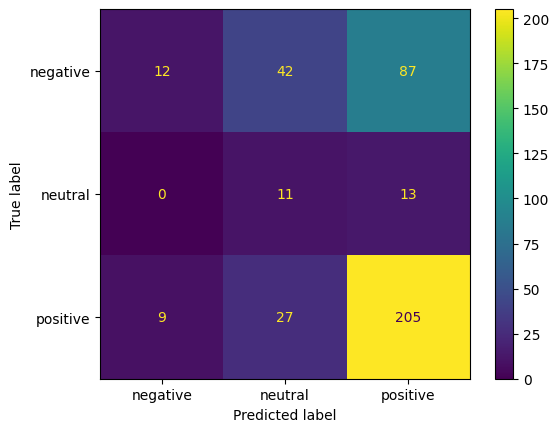


Training and evaluating fold 4
Create new text model for fold 4: single-LF-densenet201-sbert-pos-ner-lstm_fold_4_text.h5
Epoch 1/100
38/38 [==============================] - ETA: 0s - loss: 1.0962 - accuracy: 0.3853 - f1_macro: 0.3673 - f1_weighted: 0.3893
Epoch 1: val_loss improved from inf to 1.09909, saving model to ./model_checkpoint/single-LF-densenet201-sbert-pos-ner-lstm_fold_4_text.h5
38/38 [==============================] - 3s 23ms/step - loss: 1.0962 - accuracy: 0.3853 - f1_macro: 0.3673 - f1_weighted: 0.3893 - val_loss: 1.0991 - val_accuracy: 0.3399 - val_f1_macro: 0.2588 - val_f1_weighted: 0.3786
Epoch 2/100
19/38 [==============>...............] - ETA: 0s - loss: 1.0920 - accuracy: 0.4149 - f1_macro: 0.3657 - f1_weighted: 0.4045

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


35/38 [==========================>...] - ETA: 0s - loss: 1.0919 - accuracy: 0.4154 - f1_macro: 0.3635 - f1_weighted: 0.4022
Epoch 2: val_loss improved from 1.09909 to 1.09770, saving model to ./model_checkpoint/single-LF-densenet201-sbert-pos-ner-lstm_fold_4_text.h5
38/38 [==============================] - 0s 9ms/step - loss: 1.0915 - accuracy: 0.4182 - f1_macro: 0.3644 - f1_weighted: 0.4048 - val_loss: 1.0977 - val_accuracy: 0.3621 - val_f1_macro: 0.2399 - val_f1_weighted: 0.3658
Epoch 3/100
38/38 [==============================] - ETA: 0s - loss: 1.0867 - accuracy: 0.4538 - f1_macro: 0.3757 - f1_weighted: 0.4276
Epoch 3: val_loss improved from 1.09770 to 1.09669, saving model to ./model_checkpoint/single-LF-densenet201-sbert-pos-ner-lstm_fold_4_text.h5
38/38 [==============================] - 0s 8ms/step - loss: 1.0867 - accuracy: 0.4538 - f1_macro: 0.3757 - f1_weighted: 0.4276 - val_loss: 1.0967 - val_accuracy: 0.3867 - val_f1_macro: 0.2421 - val_f1_weighted: 0.3695
Epoch 4/100
30/3

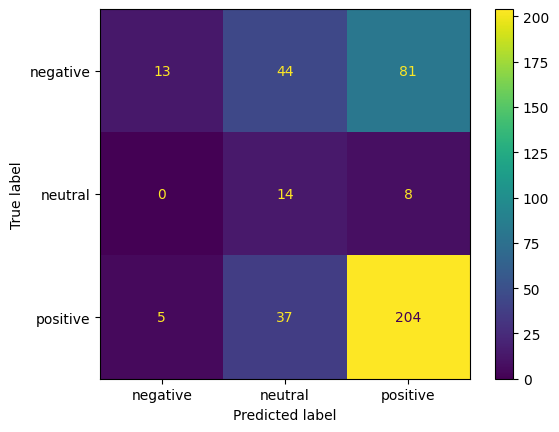


Training and evaluating fold 5
Create new text model for fold 5: single-LF-densenet201-sbert-pos-ner-lstm_fold_5_text.h5
Epoch 1/100
32/38 [========================>.....] - ETA: 0s - loss: 1.0987 - accuracy: 0.3357 - f1_macro: 0.3459 - f1_weighted: 0.3590
Epoch 1: val_loss improved from inf to 1.10109, saving model to ./model_checkpoint/single-LF-densenet201-sbert-pos-ner-lstm_fold_5_text.h5
38/38 [==============================] - 4s 29ms/step - loss: 1.0985 - accuracy: 0.3374 - f1_macro: 0.3444 - f1_weighted: 0.3587 - val_loss: 1.1011 - val_accuracy: 0.2611 - val_f1_macro: 0.2473 - val_f1_weighted: 0.2999
Epoch 2/100
19/38 [==============>...............] - ETA: 0s - loss: 1.0959 - accuracy: 0.3668 - f1_macro: 0.3522 - f1_weighted: 0.3710

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


37/38 [============================>.] - ETA: 0s - loss: 1.0947 - accuracy: 0.3856 - f1_macro: 0.3653 - f1_weighted: 0.3898
Epoch 2: val_loss improved from 1.10109 to 1.10003, saving model to ./model_checkpoint/single-LF-densenet201-sbert-pos-ner-lstm_fold_5_text.h5
38/38 [==============================] - 0s 9ms/step - loss: 1.0947 - accuracy: 0.3858 - f1_macro: 0.3653 - f1_weighted: 0.3900 - val_loss: 1.1000 - val_accuracy: 0.2980 - val_f1_macro: 0.2657 - val_f1_weighted: 0.3556
Epoch 3/100
30/38 [======================>.......] - ETA: 0s - loss: 1.0901 - accuracy: 0.4320 - f1_macro: 0.3951 - f1_weighted: 0.4287
Epoch 3: val_loss improved from 1.10003 to 1.09921, saving model to ./model_checkpoint/single-LF-densenet201-sbert-pos-ner-lstm_fold_5_text.h5
38/38 [==============================] - 0s 8ms/step - loss: 1.0900 - accuracy: 0.4369 - f1_macro: 0.3959 - f1_weighted: 0.4321 - val_loss: 1.0992 - val_accuracy: 0.3030 - val_f1_macro: 0.2205 - val_f1_weighted: 0.3220
Epoch 4/100
29/3

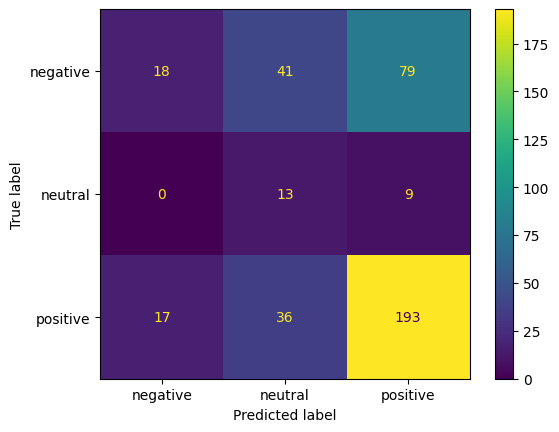


Training and evaluating fold 6
Create new text model for fold 6: single-LF-densenet201-sbert-pos-ner-lstm_fold_6_text.h5
Epoch 1/100
31/38 [=======================>......] - ETA: 0s - loss: 1.0989 - accuracy: 0.3201 - f1_macro: 0.3244 - f1_weighted: 0.3414
Epoch 1: val_loss improved from inf to 1.09815, saving model to ./model_checkpoint/single-LF-densenet201-sbert-pos-ner-lstm_fold_6_text.h5
38/38 [==============================] - 3s 21ms/step - loss: 1.0986 - accuracy: 0.3260 - f1_macro: 0.3271 - f1_weighted: 0.3442 - val_loss: 1.0981 - val_accuracy: 0.3424 - val_f1_macro: 0.2940 - val_f1_weighted: 0.3893
Epoch 2/100
26/38 [===================>..........] - ETA: 0s - loss: 1.0943 - accuracy: 0.3879 - f1_macro: 0.3620 - f1_weighted: 0.3900

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


34/38 [=========================>....] - ETA: 0s - loss: 1.0941 - accuracy: 0.3922 - f1_macro: 0.3636 - f1_weighted: 0.3930
Epoch 2: val_loss did not improve from 1.09815
38/38 [==============================] - 0s 8ms/step - loss: 1.0939 - accuracy: 0.3933 - f1_macro: 0.3632 - f1_weighted: 0.3937 - val_loss: 1.0982 - val_accuracy: 0.3596 - val_f1_macro: 0.2830 - val_f1_weighted: 0.3829
Epoch 3/100
36/38 [===========================>..] - ETA: 0s - loss: 1.0896 - accuracy: 0.4358 - f1_macro: 0.3797 - f1_weighted: 0.4210
Epoch 3: val_loss did not improve from 1.09815
38/38 [==============================] - 0s 8ms/step - loss: 1.0896 - accuracy: 0.4353 - f1_macro: 0.3786 - f1_weighted: 0.4203 - val_loss: 1.0984 - val_accuracy: 0.3473 - val_f1_macro: 0.2511 - val_f1_weighted: 0.3464
Epoch 4/100
29/38 [=====================>........] - ETA: 0s - loss: 1.0844 - accuracy: 0.4596 - f1_macro: 0.3830 - f1_weighted: 0.4339
Epoch 4: val_loss did not improve from 1.09815
38/38 [==================

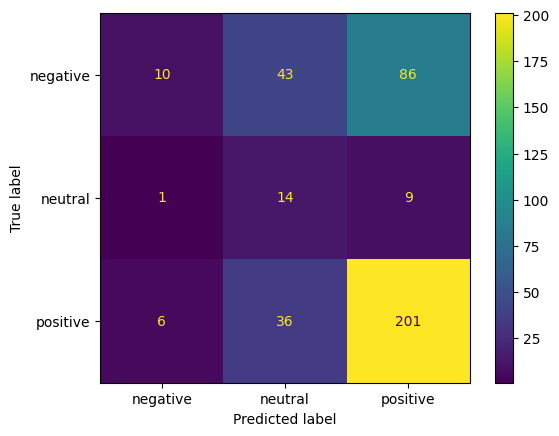


Training and evaluating fold 7
Create new text model for fold 7: single-LF-densenet201-sbert-pos-ner-lstm_fold_7_text.h5
Epoch 1/100
36/38 [===========================>..] - ETA: 0s - loss: 1.0967 - accuracy: 0.3596 - f1_macro: 0.3312 - f1_weighted: 0.3582
Epoch 1: val_loss improved from inf to 1.09108, saving model to ./model_checkpoint/single-LF-densenet201-sbert-pos-ner-lstm_fold_7_text.h5
38/38 [==============================] - 4s 32ms/step - loss: 1.0966 - accuracy: 0.3600 - f1_macro: 0.3306 - f1_weighted: 0.3577 - val_loss: 1.0911 - val_accuracy: 0.5345 - val_f1_macro: 0.2799 - val_f1_weighted: 0.4390
Epoch 2/100
14/38 [==========>...................] - ETA: 0s - loss: 1.0945 - accuracy: 0.3677 - f1_macro: 0.3211 - f1_weighted: 0.3519

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


36/38 [===========================>..] - ETA: 0s - loss: 1.0921 - accuracy: 0.3928 - f1_macro: 0.3352 - f1_weighted: 0.3698
Epoch 2: val_loss improved from 1.09108 to 1.09048, saving model to ./model_checkpoint/single-LF-densenet201-sbert-pos-ner-lstm_fold_7_text.h5
38/38 [==============================] - 0s 11ms/step - loss: 1.0920 - accuracy: 0.3943 - f1_macro: 0.3362 - f1_weighted: 0.3713 - val_loss: 1.0905 - val_accuracy: 0.5369 - val_f1_macro: 0.2656 - val_f1_weighted: 0.4244
Epoch 3/100
34/38 [=========================>....] - ETA: 0s - loss: 1.0873 - accuracy: 0.4313 - f1_macro: 0.3492 - f1_weighted: 0.3942
Epoch 3: val_loss improved from 1.09048 to 1.08982, saving model to ./model_checkpoint/single-LF-densenet201-sbert-pos-ner-lstm_fold_7_text.h5
38/38 [==============================] - 0s 13ms/step - loss: 1.0874 - accuracy: 0.4275 - f1_macro: 0.3473 - f1_weighted: 0.3910 - val_loss: 1.0898 - val_accuracy: 0.5345 - val_f1_macro: 0.2604 - val_f1_weighted: 0.4182
Epoch 4/100
34

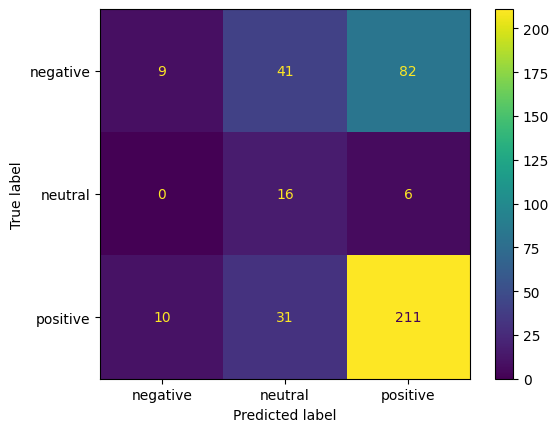


Training and evaluating fold 8
Create new text model for fold 8: single-LF-densenet201-sbert-pos-ner-lstm_fold_8_text.h5
Epoch 1/100
37/38 [============================>.] - ETA: 0s - loss: 1.0954 - accuracy: 0.3761 - f1_macro: 0.3552 - f1_weighted: 0.3825
Epoch 1: val_loss improved from inf to 1.09989, saving model to ./model_checkpoint/single-LF-densenet201-sbert-pos-ner-lstm_fold_8_text.h5
38/38 [==============================] - 3s 22ms/step - loss: 1.0953 - accuracy: 0.3762 - f1_macro: 0.3551 - f1_weighted: 0.3825 - val_loss: 1.0999 - val_accuracy: 0.2611 - val_f1_macro: 0.2152 - val_f1_weighted: 0.2899
Epoch 2/100
26/38 [===================>..........] - ETA: 0s - loss: 1.0920 - accuracy: 0.4053 - f1_macro: 0.3604 - f1_weighted: 0.3959

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


34/38 [=========================>....] - ETA: 0s - loss: 1.0918 - accuracy: 0.4074 - f1_macro: 0.3583 - f1_weighted: 0.3965
Epoch 2: val_loss improved from 1.09989 to 1.09960, saving model to ./model_checkpoint/single-LF-densenet201-sbert-pos-ner-lstm_fold_8_text.h5
38/38 [==============================] - 0s 9ms/step - loss: 1.0914 - accuracy: 0.4099 - f1_macro: 0.3592 - f1_weighted: 0.3981 - val_loss: 1.0996 - val_accuracy: 0.3202 - val_f1_macro: 0.2472 - val_f1_weighted: 0.3335
Epoch 3/100
36/38 [===========================>..] - ETA: 0s - loss: 1.0866 - accuracy: 0.4178 - f1_macro: 0.3418 - f1_weighted: 0.3926
Epoch 3: val_loss improved from 1.09960 to 1.09904, saving model to ./model_checkpoint/single-LF-densenet201-sbert-pos-ner-lstm_fold_8_text.h5
38/38 [==============================] - 0s 8ms/step - loss: 1.0865 - accuracy: 0.4207 - f1_macro: 0.3437 - f1_weighted: 0.3951 - val_loss: 1.0990 - val_accuracy: 0.3399 - val_f1_macro: 0.2567 - val_f1_weighted: 0.3427
Epoch 4/100
38/3

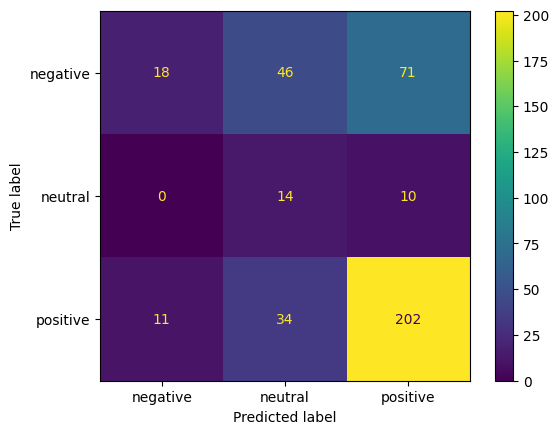


Training and evaluating fold 9
Create new text model for fold 9: single-LF-densenet201-sbert-pos-ner-lstm_fold_9_text.h5
Epoch 1/100
36/38 [===========================>..] - ETA: 0s - loss: 1.0954 - accuracy: 0.3780 - f1_macro: 0.3621 - f1_weighted: 0.3903
Epoch 1: val_loss improved from inf to 1.09719, saving model to ./model_checkpoint/single-LF-densenet201-sbert-pos-ner-lstm_fold_9_text.h5
38/38 [==============================] - 3s 30ms/step - loss: 1.0953 - accuracy: 0.3805 - f1_macro: 0.3639 - f1_weighted: 0.3921 - val_loss: 1.0972 - val_accuracy: 0.4360 - val_f1_macro: 0.3118 - val_f1_weighted: 0.4462
Epoch 2/100
17/38 [============>.................] - ETA: 0s - loss: 1.0908 - accuracy: 0.4242 - f1_macro: 0.3805 - f1_weighted: 0.4195

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


37/38 [============================>.] - ETA: 0s - loss: 1.0912 - accuracy: 0.4229 - f1_macro: 0.3726 - f1_weighted: 0.4129
Epoch 2: val_loss improved from 1.09719 to 1.09648, saving model to ./model_checkpoint/single-LF-densenet201-sbert-pos-ner-lstm_fold_9_text.h5
38/38 [==============================] - 0s 13ms/step - loss: 1.0913 - accuracy: 0.4223 - f1_macro: 0.3719 - f1_weighted: 0.4122 - val_loss: 1.0965 - val_accuracy: 0.4163 - val_f1_macro: 0.2679 - val_f1_weighted: 0.3996
Epoch 3/100
37/38 [============================>.] - ETA: 0s - loss: 1.0873 - accuracy: 0.4542 - f1_macro: 0.3785 - f1_weighted: 0.4289
Epoch 3: val_loss improved from 1.09648 to 1.09575, saving model to ./model_checkpoint/single-LF-densenet201-sbert-pos-ner-lstm_fold_9_text.h5
38/38 [==============================] - 0s 12ms/step - loss: 1.0873 - accuracy: 0.4540 - f1_macro: 0.3786 - f1_weighted: 0.4287 - val_loss: 1.0957 - val_accuracy: 0.4286 - val_f1_macro: 0.2623 - val_f1_weighted: 0.3977
Epoch 4/100
37

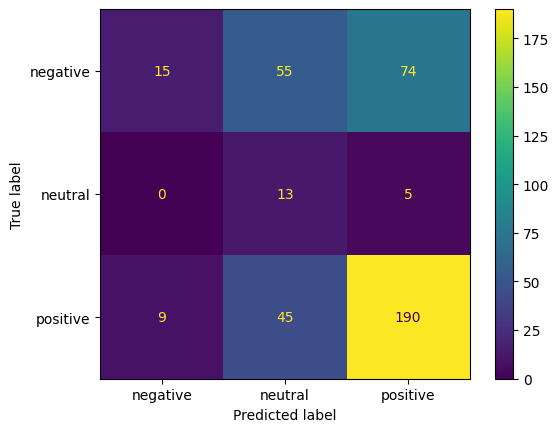


Training and evaluating fold 10
Create new text model for fold 10: single-LF-densenet201-sbert-pos-ner-lstm_fold_10_text.h5
Epoch 1/100
38/38 [==============================] - ETA: 0s - loss: 1.0995 - accuracy: 0.3215 - f1_macro: 0.3095 - f1_weighted: 0.3309
Epoch 1: val_loss improved from inf to 1.09594, saving model to ./model_checkpoint/single-LF-densenet201-sbert-pos-ner-lstm_fold_10_text.h5
38/38 [==============================] - 3s 22ms/step - loss: 1.0995 - accuracy: 0.3215 - f1_macro: 0.3095 - f1_weighted: 0.3309 - val_loss: 1.0959 - val_accuracy: 0.3990 - val_f1_macro: 0.2512 - val_f1_weighted: 0.3729
Epoch 2/100
16/38 [===========>..................] - ETA: 0s - loss: 1.0961 - accuracy: 0.3638 - f1_macro: 0.3278 - f1_weighted: 0.3514

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


33/38 [=========================>....] - ETA: 0s - loss: 1.0946 - accuracy: 0.3707 - f1_macro: 0.3242 - f1_weighted: 0.3549
Epoch 2: val_loss improved from 1.09594 to 1.09568, saving model to ./model_checkpoint/single-LF-densenet201-sbert-pos-ner-lstm_fold_10_text.h5
38/38 [==============================] - 0s 9ms/step - loss: 1.0943 - accuracy: 0.3722 - f1_macro: 0.3247 - f1_weighted: 0.3560 - val_loss: 1.0957 - val_accuracy: 0.4261 - val_f1_macro: 0.2463 - val_f1_weighted: 0.3723
Epoch 3/100
36/38 [===========================>..] - ETA: 0s - loss: 1.0900 - accuracy: 0.4013 - f1_macro: 0.3318 - f1_weighted: 0.3728
Epoch 3: val_loss improved from 1.09568 to 1.09553, saving model to ./model_checkpoint/single-LF-densenet201-sbert-pos-ner-lstm_fold_10_text.h5
38/38 [==============================] - 0s 9ms/step - loss: 1.0899 - accuracy: 0.4039 - f1_macro: 0.3328 - f1_weighted: 0.3746 - val_loss: 1.0955 - val_accuracy: 0.4433 - val_f1_macro: 0.2586 - val_f1_weighted: 0.3787
Epoch 4/100
34

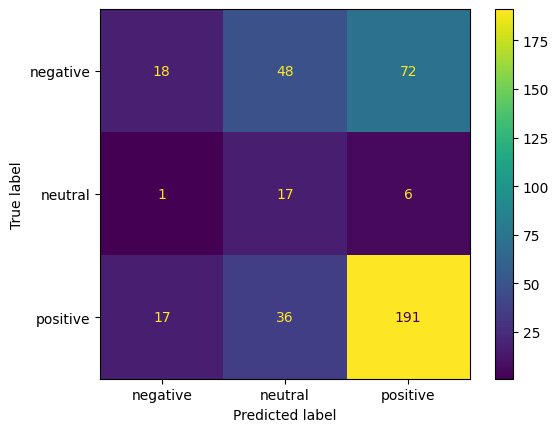


MVSA-Single: densenet201-sbert-lstm

Training and evaluating fold 1
Create new text model for fold 1: single-LF-densenet201-sbert-lstm_fold_1_text.h5
Epoch 1/100
35/38 [==========================>...] - ETA: 0s - loss: 1.0976 - accuracy: 0.3371 - f1_macro: 0.3263 - f1_weighted: 0.3483
Epoch 1: val_loss improved from inf to 1.09857, saving model to ./model_checkpoint/single-LF-densenet201-sbert-lstm_fold_1_text.h5
38/38 [==============================] - 4s 24ms/step - loss: 1.0975 - accuracy: 0.3402 - f1_macro: 0.3280 - f1_weighted: 0.3503 - val_loss: 1.0986 - val_accuracy: 0.3383 - val_f1_macro: 0.2319 - val_f1_weighted: 0.3281
Epoch 2/100
18/38 [=============>................] - ETA: 0s - loss: 1.0950 - accuracy: 0.3806 - f1_macro: 0.3453 - f1_weighted: 0.3772

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


35/38 [==========================>...] - ETA: 0s - loss: 1.0943 - accuracy: 0.3946 - f1_macro: 0.3525 - f1_weighted: 0.3877
Epoch 2: val_loss improved from 1.09857 to 1.09847, saving model to ./model_checkpoint/single-LF-densenet201-sbert-lstm_fold_1_text.h5
38/38 [==============================] - 0s 9ms/step - loss: 1.0942 - accuracy: 0.3956 - f1_macro: 0.3531 - f1_weighted: 0.3885 - val_loss: 1.0985 - val_accuracy: 0.3654 - val_f1_macro: 0.2393 - val_f1_weighted: 0.3367
Epoch 3/100
35/38 [==========================>...] - ETA: 0s - loss: 1.0917 - accuracy: 0.4136 - f1_macro: 0.3563 - f1_weighted: 0.3957
Epoch 3: val_loss improved from 1.09847 to 1.09831, saving model to ./model_checkpoint/single-LF-densenet201-sbert-lstm_fold_1_text.h5
38/38 [==============================] - 0s 9ms/step - loss: 1.0917 - accuracy: 0.4145 - f1_macro: 0.3558 - f1_weighted: 0.3959 - val_loss: 1.0983 - val_accuracy: 0.3975 - val_f1_macro: 0.2516 - val_f1_weighted: 0.3530
Epoch 4/100
32/38 [=============

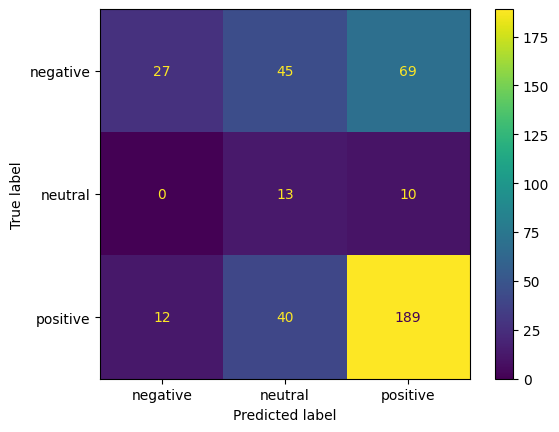


Training and evaluating fold 2
Create new text model for fold 2: single-LF-densenet201-sbert-lstm_fold_2_text.h5
Epoch 1/100
37/38 [============================>.] - ETA: 0s - loss: 1.0962 - accuracy: 0.3756 - f1_macro: 0.3644 - f1_weighted: 0.3871
Epoch 1: val_loss improved from inf to 1.09627, saving model to ./model_checkpoint/single-LF-densenet201-sbert-lstm_fold_2_text.h5
38/38 [==============================] - 3s 23ms/step - loss: 1.0963 - accuracy: 0.3737 - f1_macro: 0.3626 - f1_weighted: 0.3851 - val_loss: 1.0963 - val_accuracy: 0.4360 - val_f1_macro: 0.3348 - val_f1_weighted: 0.4784
Epoch 2/100
18/38 [=============>................] - ETA: 0s - loss: 1.0942 - accuracy: 0.4041 - f1_macro: 0.3768 - f1_weighted: 0.4043

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


37/38 [============================>.] - ETA: 0s - loss: 1.0936 - accuracy: 0.4168 - f1_macro: 0.3831 - f1_weighted: 0.4123
Epoch 2: val_loss improved from 1.09627 to 1.09557, saving model to ./model_checkpoint/single-LF-densenet201-sbert-lstm_fold_2_text.h5
38/38 [==============================] - 0s 9ms/step - loss: 1.0936 - accuracy: 0.4156 - f1_macro: 0.3821 - f1_weighted: 0.4111 - val_loss: 1.0956 - val_accuracy: 0.4433 - val_f1_macro: 0.3128 - val_f1_weighted: 0.4612
Epoch 3/100
33/38 [=========================>....] - ETA: 0s - loss: 1.0907 - accuracy: 0.4519 - f1_macro: 0.3965 - f1_weighted: 0.4374
Epoch 3: val_loss improved from 1.09557 to 1.09497, saving model to ./model_checkpoint/single-LF-densenet201-sbert-lstm_fold_2_text.h5
38/38 [==============================] - 0s 9ms/step - loss: 1.0906 - accuracy: 0.4521 - f1_macro: 0.3966 - f1_weighted: 0.4364 - val_loss: 1.0950 - val_accuracy: 0.4286 - val_f1_macro: 0.2799 - val_f1_weighted: 0.4258
Epoch 4/100
34/38 [=============

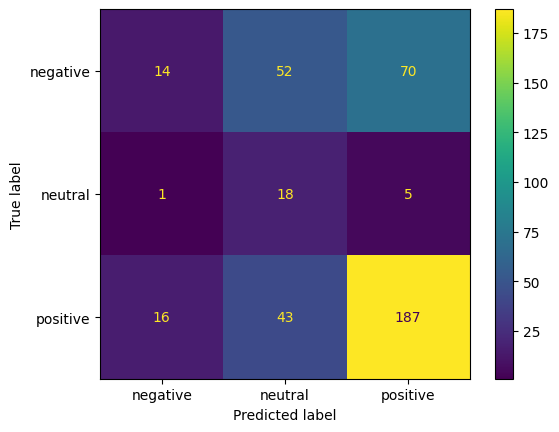


Training and evaluating fold 3
Create new text model for fold 3: single-LF-densenet201-sbert-lstm_fold_3_text.h5
Epoch 1/100
37/38 [============================>.] - ETA: 0s - loss: 1.0980 - accuracy: 0.3520 - f1_macro: 0.3536 - f1_weighted: 0.3708
Epoch 1: val_loss improved from inf to 1.10169, saving model to ./model_checkpoint/single-LF-densenet201-sbert-lstm_fold_3_text.h5
38/38 [==============================] - 3s 23ms/step - loss: 1.0980 - accuracy: 0.3522 - f1_macro: 0.3537 - f1_weighted: 0.3708 - val_loss: 1.1017 - val_accuracy: 0.2291 - val_f1_macro: 0.2279 - val_f1_weighted: 0.2764
Epoch 2/100
19/38 [==============>...............] - ETA: 0s - loss: 1.0956 - accuracy: 0.3894 - f1_macro: 0.3667 - f1_weighted: 0.3930

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


35/38 [==========================>...] - ETA: 0s - loss: 1.0949 - accuracy: 0.4049 - f1_macro: 0.3767 - f1_weighted: 0.4069
Epoch 2: val_loss improved from 1.10169 to 1.10084, saving model to ./model_checkpoint/single-LF-densenet201-sbert-lstm_fold_3_text.h5
38/38 [==============================] - 0s 9ms/step - loss: 1.0948 - accuracy: 0.4047 - f1_macro: 0.3760 - f1_weighted: 0.4061 - val_loss: 1.1008 - val_accuracy: 0.2586 - val_f1_macro: 0.2404 - val_f1_weighted: 0.3142
Epoch 3/100
37/38 [============================>.] - ETA: 0s - loss: 1.0915 - accuracy: 0.4364 - f1_macro: 0.3816 - f1_weighted: 0.4236
Epoch 3: val_loss improved from 1.10084 to 1.10020, saving model to ./model_checkpoint/single-LF-densenet201-sbert-lstm_fold_3_text.h5
38/38 [==============================] - 0s 8ms/step - loss: 1.0915 - accuracy: 0.4378 - f1_macro: 0.3826 - f1_weighted: 0.4247 - val_loss: 1.1002 - val_accuracy: 0.2685 - val_f1_macro: 0.2113 - val_f1_weighted: 0.2922
Epoch 4/100
38/38 [=============

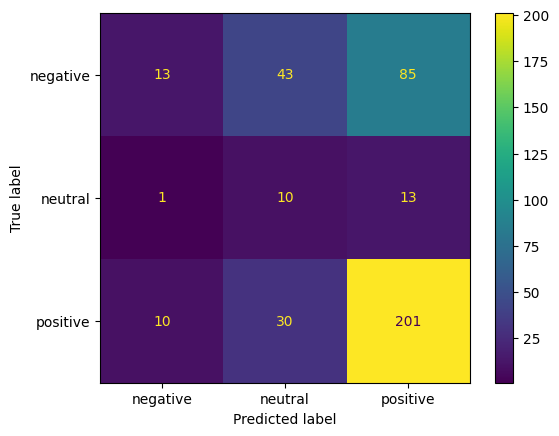


Training and evaluating fold 4
Create new text model for fold 4: single-LF-densenet201-sbert-lstm_fold_4_text.h5
Epoch 1/100
29/38 [=====================>........] - ETA: 0s - loss: 1.0988 - accuracy: 0.3373 - f1_macro: 0.3336 - f1_weighted: 0.3482
Epoch 1: val_loss improved from inf to 1.10075, saving model to ./model_checkpoint/single-LF-densenet201-sbert-lstm_fold_4_text.h5
38/38 [==============================] - 3s 22ms/step - loss: 1.0986 - accuracy: 0.3358 - f1_macro: 0.3269 - f1_weighted: 0.3434 - val_loss: 1.1008 - val_accuracy: 0.2118 - val_f1_macro: 0.1803 - val_f1_weighted: 0.2575
Epoch 2/100
16/38 [===========>..................] - ETA: 0s - loss: 1.0965 - accuracy: 0.3750 - f1_macro: 0.3397 - f1_weighted: 0.3673

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


32/38 [========================>.....] - ETA: 0s - loss: 1.0961 - accuracy: 0.3704 - f1_macro: 0.3303 - f1_weighted: 0.3605
Epoch 2: val_loss improved from 1.10075 to 1.10034, saving model to ./model_checkpoint/single-LF-densenet201-sbert-lstm_fold_4_text.h5
38/38 [==============================] - 0s 9ms/step - loss: 1.0955 - accuracy: 0.3786 - f1_macro: 0.3364 - f1_weighted: 0.3684 - val_loss: 1.1003 - val_accuracy: 0.2217 - val_f1_macro: 0.1671 - val_f1_weighted: 0.2534
Epoch 3/100
34/38 [=========================>....] - ETA: 0s - loss: 1.0923 - accuracy: 0.4157 - f1_macro: 0.3527 - f1_weighted: 0.3943
Epoch 3: val_loss improved from 1.10034 to 1.10004, saving model to ./model_checkpoint/single-LF-densenet201-sbert-lstm_fold_4_text.h5
38/38 [==============================] - 0s 9ms/step - loss: 1.0922 - accuracy: 0.4182 - f1_macro: 0.3544 - f1_weighted: 0.3963 - val_loss: 1.1000 - val_accuracy: 0.2463 - val_f1_macro: 0.1826 - val_f1_weighted: 0.2798
Epoch 4/100
36/38 [=============

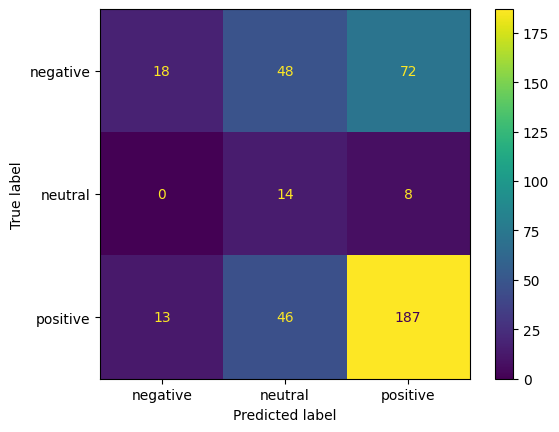


Training and evaluating fold 5
Create new text model for fold 5: single-LF-densenet201-sbert-lstm_fold_5_text.h5
Epoch 1/100
36/38 [===========================>..] - ETA: 0s - loss: 1.0974 - accuracy: 0.3544 - f1_macro: 0.3425 - f1_weighted: 0.3699
Epoch 1: val_loss improved from inf to 1.09915, saving model to ./model_checkpoint/single-LF-densenet201-sbert-lstm_fold_5_text.h5
38/38 [==============================] - 3s 22ms/step - loss: 1.0973 - accuracy: 0.3556 - f1_macro: 0.3424 - f1_weighted: 0.3703 - val_loss: 1.0991 - val_accuracy: 0.3251 - val_f1_macro: 0.2554 - val_f1_weighted: 0.3626
Epoch 2/100
17/38 [============>.................] - ETA: 0s - loss: 1.0949 - accuracy: 0.3934 - f1_macro: 0.3509 - f1_weighted: 0.3881

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


32/38 [========================>.....] - ETA: 0s - loss: 1.0945 - accuracy: 0.3992 - f1_macro: 0.3469 - f1_weighted: 0.3890
Epoch 2: val_loss improved from 1.09915 to 1.09868, saving model to ./model_checkpoint/single-LF-densenet201-sbert-lstm_fold_5_text.h5
38/38 [==============================] - 0s 9ms/step - loss: 1.0945 - accuracy: 0.4001 - f1_macro: 0.3487 - f1_weighted: 0.3892 - val_loss: 1.0987 - val_accuracy: 0.3768 - val_f1_macro: 0.2742 - val_f1_weighted: 0.3970
Epoch 3/100
36/38 [===========================>..] - ETA: 0s - loss: 1.0914 - accuracy: 0.4442 - f1_macro: 0.3753 - f1_weighted: 0.4232
Epoch 3: val_loss improved from 1.09868 to 1.09826, saving model to ./model_checkpoint/single-LF-densenet201-sbert-lstm_fold_5_text.h5
38/38 [==============================] - 0s 8ms/step - loss: 1.0914 - accuracy: 0.4435 - f1_macro: 0.3739 - f1_weighted: 0.4219 - val_loss: 1.0983 - val_accuracy: 0.3670 - val_f1_macro: 0.2513 - val_f1_weighted: 0.3732
Epoch 4/100
38/38 [=============

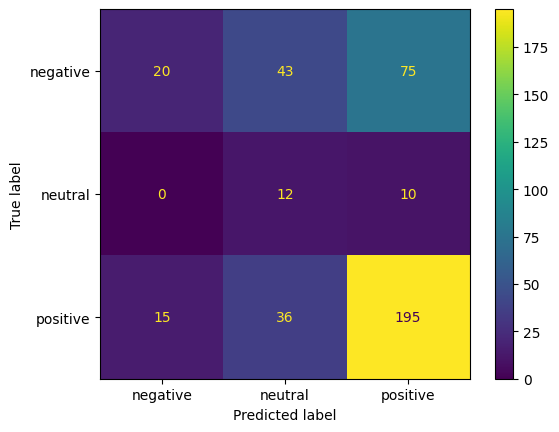


Training and evaluating fold 6
Create new text model for fold 6: single-LF-densenet201-sbert-lstm_fold_6_text.h5
Epoch 1/100
34/38 [=========================>....] - ETA: 0s - loss: 1.0976 - accuracy: 0.3591 - f1_macro: 0.3477 - f1_weighted: 0.3706
Epoch 1: val_loss improved from inf to 1.09958, saving model to ./model_checkpoint/single-LF-densenet201-sbert-lstm_fold_6_text.h5
38/38 [==============================] - 4s 35ms/step - loss: 1.0974 - accuracy: 0.3617 - f1_macro: 0.3489 - f1_weighted: 0.3714 - val_loss: 1.0996 - val_accuracy: 0.2783 - val_f1_macro: 0.2191 - val_f1_weighted: 0.3078
Epoch 2/100
14/38 [==========>...................] - ETA: 0s - loss: 1.0957 - accuracy: 0.3828 - f1_macro: 0.3486 - f1_weighted: 0.3809

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


37/38 [============================>.] - ETA: 0s - loss: 1.0943 - accuracy: 0.4103 - f1_macro: 0.3671 - f1_weighted: 0.4035
Epoch 2: val_loss improved from 1.09958 to 1.09879, saving model to ./model_checkpoint/single-LF-densenet201-sbert-lstm_fold_6_text.h5
38/38 [==============================] - 1s 14ms/step - loss: 1.0944 - accuracy: 0.4072 - f1_macro: 0.3643 - f1_weighted: 0.4007 - val_loss: 1.0988 - val_accuracy: 0.3227 - val_f1_macro: 0.2230 - val_f1_weighted: 0.3247
Epoch 3/100
34/38 [=========================>....] - ETA: 0s - loss: 1.0921 - accuracy: 0.4299 - f1_macro: 0.3668 - f1_weighted: 0.4113
Epoch 3: val_loss improved from 1.09879 to 1.09822, saving model to ./model_checkpoint/single-LF-densenet201-sbert-lstm_fold_6_text.h5
38/38 [==============================] - 1s 13ms/step - loss: 1.0918 - accuracy: 0.4340 - f1_macro: 0.3691 - f1_weighted: 0.4149 - val_loss: 1.0982 - val_accuracy: 0.3276 - val_f1_macro: 0.2248 - val_f1_weighted: 0.3271
Epoch 4/100
32/38 [===========

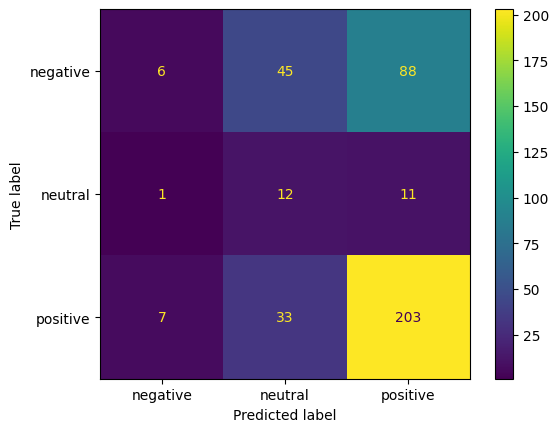


Training and evaluating fold 7
Create new text model for fold 7: single-LF-densenet201-sbert-lstm_fold_7_text.h5
Epoch 1/100
37/38 [============================>.] - ETA: 0s - loss: 1.0995 - accuracy: 0.3237 - f1_macro: 0.3291 - f1_weighted: 0.3458
Epoch 1: val_loss improved from inf to 1.09889, saving model to ./model_checkpoint/single-LF-densenet201-sbert-lstm_fold_7_text.h5
38/38 [==============================] - 3s 22ms/step - loss: 1.0995 - accuracy: 0.3238 - f1_macro: 0.3290 - f1_weighted: 0.3457 - val_loss: 1.0989 - val_accuracy: 0.3325 - val_f1_macro: 0.2680 - val_f1_weighted: 0.3728
Epoch 2/100
27/38 [====================>.........] - ETA: 0s - loss: 1.0967 - accuracy: 0.3683 - f1_macro: 0.3397 - f1_weighted: 0.3680

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


36/38 [===========================>..] - ETA: 0s - loss: 1.0962 - accuracy: 0.3770 - f1_macro: 0.3477 - f1_weighted: 0.3759
Epoch 2: val_loss improved from 1.09889 to 1.09852, saving model to ./model_checkpoint/single-LF-densenet201-sbert-lstm_fold_7_text.h5
38/38 [==============================] - 0s 9ms/step - loss: 1.0962 - accuracy: 0.3787 - f1_macro: 0.3485 - f1_weighted: 0.3773 - val_loss: 1.0985 - val_accuracy: 0.3695 - val_f1_macro: 0.2526 - val_f1_weighted: 0.3781
Epoch 3/100
35/38 [==========================>...] - ETA: 0s - loss: 1.0932 - accuracy: 0.4092 - f1_macro: 0.3626 - f1_weighted: 0.3988
Epoch 3: val_loss improved from 1.09852 to 1.09807, saving model to ./model_checkpoint/single-LF-densenet201-sbert-lstm_fold_7_text.h5
38/38 [==============================] - 0s 9ms/step - loss: 1.0931 - accuracy: 0.4105 - f1_macro: 0.3622 - f1_weighted: 0.3994 - val_loss: 1.0981 - val_accuracy: 0.3719 - val_f1_macro: 0.2405 - val_f1_weighted: 0.3641
Epoch 4/100
36/38 [=============

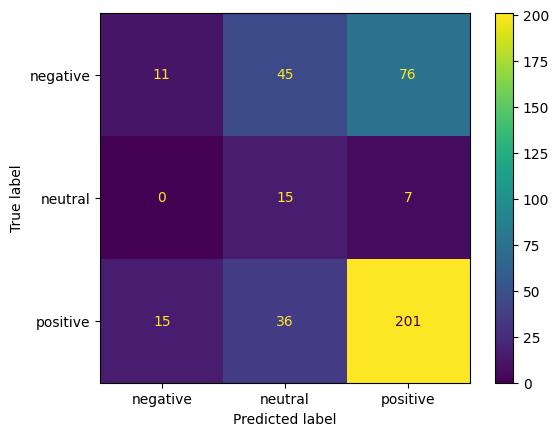


Training and evaluating fold 8
Create new text model for fold 8: single-LF-densenet201-sbert-lstm_fold_8_text.h5
Epoch 1/100
35/38 [==========================>...] - ETA: 0s - loss: 1.0962 - accuracy: 0.3786 - f1_macro: 0.3607 - f1_weighted: 0.3860
Epoch 1: val_loss improved from inf to 1.10012, saving model to ./model_checkpoint/single-LF-densenet201-sbert-lstm_fold_8_text.h5
38/38 [==============================] - 5s 32ms/step - loss: 1.0961 - accuracy: 0.3789 - f1_macro: 0.3595 - f1_weighted: 0.3855 - val_loss: 1.1001 - val_accuracy: 0.2685 - val_f1_macro: 0.2150 - val_f1_weighted: 0.3036
Epoch 2/100
 7/38 [====>.........................] - ETA: 0s - loss: 1.0948 - accuracy: 0.3828 - f1_macro: 0.3423 - f1_weighted: 0.3729

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


33/38 [=========================>....] - ETA: 0s - loss: 1.0932 - accuracy: 0.4167 - f1_macro: 0.3600 - f1_weighted: 0.4037
Epoch 2: val_loss improved from 1.10012 to 1.09988, saving model to ./model_checkpoint/single-LF-densenet201-sbert-lstm_fold_8_text.h5
38/38 [==============================] - 1s 14ms/step - loss: 1.0931 - accuracy: 0.4180 - f1_macro: 0.3596 - f1_weighted: 0.4037 - val_loss: 1.0999 - val_accuracy: 0.2857 - val_f1_macro: 0.2216 - val_f1_weighted: 0.3059
Epoch 3/100
35/38 [==========================>...] - ETA: 0s - loss: 1.0900 - accuracy: 0.4507 - f1_macro: 0.3695 - f1_weighted: 0.4236
Epoch 3: val_loss improved from 1.09988 to 1.09938, saving model to ./model_checkpoint/single-LF-densenet201-sbert-lstm_fold_8_text.h5
38/38 [==============================] - 1s 14ms/step - loss: 1.0898 - accuracy: 0.4537 - f1_macro: 0.3710 - f1_weighted: 0.4262 - val_loss: 1.0994 - val_accuracy: 0.3103 - val_f1_macro: 0.2375 - val_f1_weighted: 0.3279
Epoch 4/100
36/38 [===========

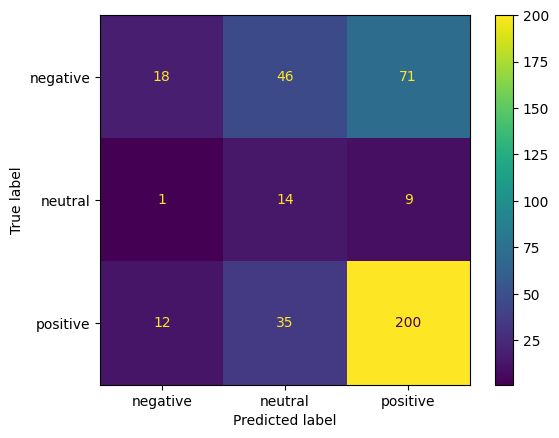


Training and evaluating fold 9
Create new text model for fold 9: single-LF-densenet201-sbert-lstm_fold_9_text.h5
Epoch 1/100
37/38 [============================>.] - ETA: 0s - loss: 1.0970 - accuracy: 0.3733 - f1_macro: 0.3672 - f1_weighted: 0.3825
Epoch 1: val_loss improved from inf to 1.10053, saving model to ./model_checkpoint/single-LF-densenet201-sbert-lstm_fold_9_text.h5
38/38 [==============================] - 4s 31ms/step - loss: 1.0970 - accuracy: 0.3739 - f1_macro: 0.3675 - f1_weighted: 0.3831 - val_loss: 1.1005 - val_accuracy: 0.2118 - val_f1_macro: 0.2147 - val_f1_weighted: 0.2702
Epoch 2/100
16/38 [===========>..................] - ETA: 0s - loss: 1.0951 - accuracy: 0.4009 - f1_macro: 0.3692 - f1_weighted: 0.3921

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


31/38 [=======================>......] - ETA: 0s - loss: 1.0949 - accuracy: 0.3974 - f1_macro: 0.3626 - f1_weighted: 0.3875
Epoch 2: val_loss improved from 1.10053 to 1.09968, saving model to ./model_checkpoint/single-LF-densenet201-sbert-lstm_fold_9_text.h5
38/38 [==============================] - 0s 11ms/step - loss: 1.0945 - accuracy: 0.4057 - f1_macro: 0.3693 - f1_weighted: 0.3950 - val_loss: 1.0997 - val_accuracy: 0.2438 - val_f1_macro: 0.2134 - val_f1_weighted: 0.2943
Epoch 3/100
36/38 [===========================>..] - ETA: 0s - loss: 1.0919 - accuracy: 0.4303 - f1_macro: 0.3781 - f1_weighted: 0.4126
Epoch 3: val_loss improved from 1.09968 to 1.09883, saving model to ./model_checkpoint/single-LF-densenet201-sbert-lstm_fold_9_text.h5
38/38 [==============================] - 0s 13ms/step - loss: 1.0918 - accuracy: 0.4324 - f1_macro: 0.3793 - f1_weighted: 0.4143 - val_loss: 1.0988 - val_accuracy: 0.2488 - val_f1_macro: 0.2051 - val_f1_weighted: 0.2907
Epoch 4/100
36/38 [===========

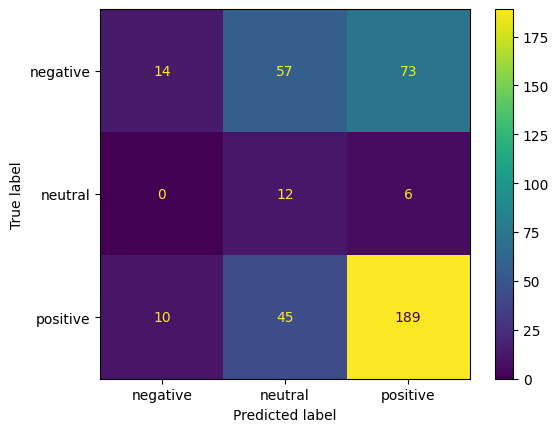


Training and evaluating fold 10
Create new text model for fold 10: single-LF-densenet201-sbert-lstm_fold_10_text.h5
Epoch 1/100
34/38 [=========================>....] - ETA: 0s - loss: 1.0966 - accuracy: 0.3718 - f1_macro: 0.3548 - f1_weighted: 0.3810
Epoch 1: val_loss improved from inf to 1.09779, saving model to ./model_checkpoint/single-LF-densenet201-sbert-lstm_fold_10_text.h5
38/38 [==============================] - 4s 33ms/step - loss: 1.0963 - accuracy: 0.3731 - f1_macro: 0.3540 - f1_weighted: 0.3809 - val_loss: 1.0978 - val_accuracy: 0.3325 - val_f1_macro: 0.2445 - val_f1_weighted: 0.3496
Epoch 2/100
16/38 [===========>..................] - ETA: 0s - loss: 1.0942 - accuracy: 0.4067 - f1_macro: 0.3635 - f1_weighted: 0.3962

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


35/38 [==========================>...] - ETA: 0s - loss: 1.0931 - accuracy: 0.4167 - f1_macro: 0.3660 - f1_weighted: 0.4052
Epoch 2: val_loss improved from 1.09779 to 1.09752, saving model to ./model_checkpoint/single-LF-densenet201-sbert-lstm_fold_10_text.h5
38/38 [==============================] - 0s 13ms/step - loss: 1.0930 - accuracy: 0.4203 - f1_macro: 0.3694 - f1_weighted: 0.4087 - val_loss: 1.0975 - val_accuracy: 0.3424 - val_f1_macro: 0.2434 - val_f1_weighted: 0.3509
Epoch 3/100
35/38 [==========================>...] - ETA: 0s - loss: 1.0902 - accuracy: 0.4270 - f1_macro: 0.3580 - f1_weighted: 0.4046
Epoch 3: val_loss improved from 1.09752 to 1.09708, saving model to ./model_checkpoint/single-LF-densenet201-sbert-lstm_fold_10_text.h5
38/38 [==============================] - 0s 12ms/step - loss: 1.0900 - accuracy: 0.4297 - f1_macro: 0.3585 - f1_weighted: 0.4063 - val_loss: 1.0971 - val_accuracy: 0.3596 - val_f1_macro: 0.2447 - val_f1_weighted: 0.3550
Epoch 4/100
36/38 [=========

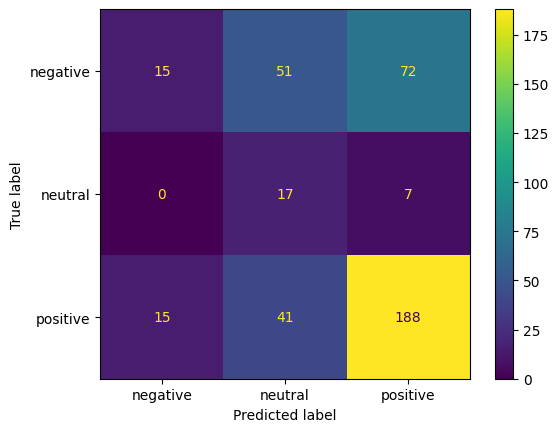

In [ ]:
print('MVSA-Single with Late Fusion')
scores_text = []
scores_image = []
scores_LF = []
for i in range(len(feature_names)):
    print('MVSA-Single:', feature_names[i])
    if 'lstm' in feature_names[i]:
        score_text, score_image, score_LF = run_and_evaluate_LF_cv('single-LF-' + feature_names[i],
                                                                mvsa_single_features[i][0],
                                                                mvsa_single_features[i][1],
                                                                mvsa_single_multimodal_labels,
                                                                verbose=VERBOSE, lstm=True)
    else:
        score_text, score_image, score_LF = run_and_evaluate_LF_cv('single-LF-' + feature_names[i],
                                                                mvsa_single_features[i][0],
                                                                mvsa_single_features[i][1],
                                                                mvsa_single_multimodal_labels,
                                                                verbose=VERBOSE, lstm=False)
    scores_text.append(np.mean(score_text,axis=0))
    scores_image.append(np.mean(score_image,axis=0))
    scores_LF.append(np.mean(score_LF,axis=0))
    print()

df1_single_scores_text = pd.DataFrame(scores_text, columns=['Accuracy', 'F1-macro', 'F1-weighted'], index=textual_feature_names)
df1_single_scores_image = pd.DataFrame(scores_image, columns=['Accuracy', 'F1-macro', 'F1-weighted'], index=visual_feature_names)
df1_single_scores_LF = pd.DataFrame(scores_LF, columns=['Accuracy', 'F1-macro', 'F1-weighted'], index=feature_names)

# print('--------------------------------')
# print('\nMVSA-Multiple with Late Fusion')
# scores_text = []
# scores_image = []
# scores_LF = []
# for i in range(len(feature_names)):
#     print('MVSA-Multiple:', feature_names[i])
#     if 'lstm' in feature_names[i]:
#         score_text, score_image, score_LF = run_and_evaluate_LF('multiple-LF-' + feature_names[i],
#                                                                 mvsa_multiple_features[i][0],
#                                                                 mvsa_multiple_features[i][1],
#                                                                 mvsa_multiple_multimodal_labels,
#                                                                 verbose=VERBOSE, lstm=True)
#     else:
#         score_text, score_image, score_LF = run_and_evaluate_LF('multiple-LF-' + feature_names[i],
#                                                                 mvsa_multiple_features[i][0],
#                                                                 mvsa_multiple_features[i][1],
#                                                                 mvsa_multiple_multimodal_labels,
#                                                                 verbose=VERBOSE, lstm=False)
#     scores_text.append(score_text)
#     scores_image.append(score_image)
#     scores_LF.append(score_LF)
#     print()

# df1_multiple_scores_text = pd.DataFrame(scores_text, columns=['Accuracy', 'F1-macro', 'F1-weighted'], index=textual_feature_names)
# df1_multiple_scores_image = pd.DataFrame(scores_image, columns=['Accuracy', 'F1-macro', 'F1-weighted'], index=visual_feature_names)
# df1_multiple_scores_LF = pd.DataFrame(scores_LF, columns=['Accuracy', 'F1-macro', 'F1-weighted'], index=feature_names)

In [ ]:
df1_single_scores_LF

,Accuracy,F1-macro,F1-weighted
densenet201-bert-pos-ner-lstm,0.555062,0.378526,0.518201
densenet201-bert-lstm,0.556293,0.380940,0.522166
densenet201-sbert-pos-ner-lstm,0.558264,0.391739,0.528368
densenet201-sbert-lstm,0.550139,0.383365,0.523558


In [ ]:
mvsa_single_multimodal_labels

array(['positive', 'positive', 'positive', ..., 'positive', 'positive',
       'positive'], dtype='<U8')

In [ ]:
print('--------------------------------')
print('\nMVSA-Multiple with Late Fusion')
scores_text = []
scores_image = []
scores_LF = []
for i in range(len(feature_names)):
    print('MVSA-Multiple:', feature_names[i])
    if 'lstm' in feature_names[i]:
        score_text, score_image, score_LF = run_and_evaluate_LF_cv('multiple-LF-' + feature_names[i],
                                                                mvsa_multiple_features[i][0],
                                                                mvsa_multiple_features[i][1],
                                                                mvsa_multiple_multimodal_labels,
                                                                verbose=VERBOSE, lstm=True)
    else:
        score_text, score_image, score_LF = run_and_evaluate_LF_cv('multiple-LF-' + feature_names[i],
                                                                mvsa_multiple_features[i][0],
                                                                mvsa_multiple_features[i][1],
                                                                mvsa_multiple_multimodal_labels,
                                                                verbose=VERBOSE, lstm=False)
    scores_text.append(np.mean(score_text,axis=0))
    scores_image.append(np.mean(score_image,axis=0))
    scores_LF.append(np.mean(score_LF,axis=0))
    print()

df1_multiple_scores_text = pd.DataFrame(scores_text, columns=['Accuracy', 'F1-macro', 'F1-weighted'], index=textual_feature_names)
df1_multiple_scores_image = pd.DataFrame(scores_image, columns=['Accuracy', 'F1-macro', 'F1-weighted'], index=visual_feature_names)
df1_multiple_scores_LF = pd.DataFrame(scores_LF, columns=['Accuracy', 'F1-macro', 'F1-weighted'], index=feature_names)
df1_multiple_scores_LF

Output hidden; open in https://colab.research.google.com to view.

# Hybrid Fusion

In [ ]:
print('MVSA-Single with Hybrid Fusion')
scores_text = []
scores_image = []
scores_IF = []
scores_HF = []
for i in range(len(feature_names)):
    print('MVSA-Single:', feature_names[i])
    if 'lstm' in feature_names[i]:
        score_text, score_image, score_IF, score_HF = run_and_evaluate_HF('single-HF-' + feature_names[i],
                                                                          mvsa_single_features[i][0],
                                                                          mvsa_single_features[i][1],
                                                                          mvsa_single_multimodal_labels,
                                                                          verbose=VERBOSE, lstm=True)
    else:
        score_text, score_image, score_IF, score_HF = run_and_evaluate_HF('single-HF-' + feature_names[i],
                                                                          mvsa_single_features[i][0],
                                                                          mvsa_single_features[i][1],
                                                                          mvsa_single_multimodal_labels,
                                                                          verbose=VERBOSE, lstm=False)
    scores_text.append(score_text)
    scores_image.append(score_image)
    scores_IF.append(score_IF)
    scores_HF.append(score_HF)
    print()

df2_single_scores_text = pd.DataFrame(scores_text, columns=['Accuracy', 'F1-macro', 'F1-weighted'], index=textual_feature_names)
df2_single_scores_image = pd.DataFrame(scores_image, columns=['Accuracy', 'F1-macro', 'F1-weighted'], index=visual_feature_names)
df2_single_scores_IF = pd.DataFrame(scores_IF, columns=['Accuracy', 'F1-macro', 'F1-weighted'], index=feature_names)
df2_single_scores_HF = pd.DataFrame(scores_HF, columns=['Accuracy', 'F1-macro', 'F1-weighted'], index=feature_names)

print('----------------------------------')
print('\nMVSA-Multiple with Hybrid Fusion')
scores_text = []
scores_image = []
scores_IF = []
scores_HF = []
for i in range(len(feature_names)):
    print('MVSA-Multiple:', feature_names[i])
    if 'lstm' in feature_names[i]:
        score_text, score_image, score_IF, score_HF = run_and_evaluate_HF('multiple-HF-' + feature_names[i],
                                                                          mvsa_multiple_features[i][0],
                                                                          mvsa_multiple_features[i][1],
                                                                          mvsa_multiple_multimodal_labels,
                                                                          verbose=VERBOSE, lstm=True)
    else:
        score_text, score_image, score_IF, score_HF = run_and_evaluate_HF('multiple-HF-' + feature_names[i],
                                                                          mvsa_multiple_features[i][0],
                                                                          mvsa_multiple_features[i][1],
                                                                          mvsa_multiple_multimodal_labels,
                                                                          verbose=VERBOSE, lstm=False)
    scores_text.append(score_text)
    scores_image.append(score_image)
    scores_IF.append(score_IF)
    scores_HF.append(score_HF)
    print()

df2_multiple_scores_text = pd.DataFrame(scores_text, columns=['Accuracy', 'F1-macro', 'F1-weighted'], index=textual_feature_names)
df2_multiple_scores_image = pd.DataFrame(scores_image, columns=['Accuracy', 'F1-macro', 'F1-weighted'], index=visual_feature_names)
df2_multiple_scores_IF = pd.DataFrame(scores_IF, columns=['Accuracy', 'F1-macro', 'F1-weighted'], index=feature_names)
df2_multiple_scores_HF = pd.DataFrame(scores_HF, columns=['Accuracy', 'F1-macro', 'F1-weighted'], index=feature_names)

# Display results

In [ ]:
print('Intermediate Fusion')
display_dataframes((style_dataframe(df0_single_scores_IF), style_dataframe(df0_multiple_scores_IF)),
                   names=['MVSA-Single', 'MVSA-Multiple'])

In [ ]:
print('LATE FUSION \n')
print('MVSA-Single')
print(display_dataframes((style_dataframe(df1_single_scores_text), style_dataframe(df1_single_scores_image),
                          style_dataframe(df1_single_scores_LF)),
                         names=['Model Text', 'Model Image', 'Model LF']))
print('\nMVSA-Multiple')
print(display_dataframes((style_dataframe(df1_multiple_scores_text), style_dataframe(df1_multiple_scores_image), style_dataframe(df1_multiple_scores_LF)),
                   names=['Model Text', 'Model Image', 'Model LF']))

In [ ]:
print('HYBRID FUSION \n')
print('MVSA-Single')
print(display_dataframes((style_dataframe(df2_single_scores_text), style_dataframe(df2_single_scores_image),
                          style_dataframe(df2_single_scores_IF), style_dataframe(df2_single_scores_HF)),
                   names=['Model Text', 'Model Image', 'Model IF', 'Model HF']))
print('\nMVSA-Multiple')
print(display_dataframes((style_dataframe(df2_multiple_scores_text), style_dataframe(df2_multiple_scores_image),
                          style_dataframe(df2_multiple_scores_IF), style_dataframe(df2_multiple_scores_HF)),
                   names=['Model Text', 'Model Image', 'Model IF', 'Model HF']))

In [ ]:
# get max values of late and intermediate fusion
df_single_higher_fusion = pd.DataFrame(np.where(df1_single_scores_LF.gt(df0_single_scores_IF.values),
                                                df1_single_scores_LF.values, df0_single_scores_IF.values),
                                       columns=['Accuracy','F1-macro','F1-weighted'], index=feature_names)

df_multiple_higher_fusion = pd.DataFrame(np.where(df1_multiple_scores_LF.gt(df0_multiple_scores_IF.values),
                                                  df1_multiple_scores_LF.values, df0_multiple_scores_IF.values),
                                         columns=['Accuracy','F1-macro','F1-weighted'], index=feature_names)

df_single_subtract = df2_single_scores_HF.subtract(df_single_higher_fusion)
df_multiple_subtract = df2_multiple_scores_HF.subtract(df_multiple_higher_fusion)

In [ ]:
print('Compare Hybrid Fusion with other Fusion Models (>scores)')
display_dataframes((df_single_subtract.style.applymap(highlight_neg), df_multiple_subtract.style.applymap(highlight_neg)),
                   names=['MVSA-Single', 'MVSA-Multiple'])

## Trying

# Drafts

In [ ]:
# import shutil
# def remove_folder(path):
#     # check if folder exists
#     if os.path.exists(path):
#          # remove if exists
#          shutil.rmtree(path)
#     else:
#          # throw your exception to handle this special scenario
#          raise XXError("your exception")
# remove_folder("./model_checkpoint")
# remove_folder("./model_history")

In [ ]:
# ## Choose best
# # Load text feature
# mvsa_single_bert, mvsa_multiple_bert = load_mvsa_feature('bert-base')
# mvsa_single_pos_bow, mvsa_multiple_pos_bow = load_mvsa_feature('pos-bow')
# mvsa_single_pos_tfidf, mvsa_multiple_pos_tfidf = load_mvsa_feature('pos-tfidf')
# mvsa_single_ner_bow, mvsa_multiple_ner_bow = load_mvsa_feature('ner-bow')
# mvsa_single_ner_tfidf, mvsa_multiple_ner_tfidf = load_mvsa_feature('ner-tfidf')

# ## Load image feature
# mvsa_single_vgg16, mvsa_multiple_vgg16 = load_mvsa_feature('vgg16')
# mvsa_single_vgg19, mvsa_multiple_vgg19 = load_mvsa_feature('vgg19')
# mvsa_single_resnet50, mvsa_multiple_resnet50 = load_mvsa_feature('resnet50')
# mvsa_single_resnet101, mvsa_multiple_resnet101 = load_mvsa_feature('resnet101')
# mvsa_single_resnet152, mvsa_multiple_resnet152 = load_mvsa_feature('resnet152')
# mvsa_single_densenet121, mvsa_multiple_densenet121 = load_mvsa_feature('densenet121')
# mvsa_single_densenet169, mvsa_multiple_densenet169 = load_mvsa_feature('densenet169')
# mvsa_single_densenet201, mvsa_multiple_densenet201 = load_mvsa_feature('densenet201')

# mvsa_single_bert_pos = np.concatenate((mvsa_single_bert, mvsa_single_pos_tfidf), axis=1)
# mvsa_single_bert_ner = np.concatenate((mvsa_single_bert, mvsa_single_ner_tfidf), axis=1)
# mvsa_single_bert_pos_ner = np.concatenate((mvsa_single_bert, mvsa_single_pos_tfidf, mvsa_single_ner_tfidf), axis=1)

# mvsa_multiple_bert_pos = np.concatenate((mvsa_multiple_bert, mvsa_multiple_pos_tfidf), axis=1)
# mvsa_multiple_bert_ner = np.concatenate((mvsa_multiple_bert, mvsa_multiple_ner_tfidf), axis=1)
# mvsa_multiple_bert_pos_ner = np.concatenate((mvsa_multiple_bert, mvsa_multiple_pos_tfidf, mvsa_multiple_ner_tfidf), axis=1)

In [ ]:
# mvsa_single_features_split = get_preprocess_input(feature_names, mvsa_single_features, mvsa_single_multimodal_labels)
# mvsa_multiple_features_split = get_preprocess_input(feature_names, mvsa_multiple_features, mvsa_multiple_multimodal_labels)
# mvsa_single_features, mvsa_single_multimodal_labels = shuffle_mvsa(mvsa_single_features, mvsa_single_multimodal_labels)
# mvsa_multiple_features, mvsa_multiple_multimodal_labels = shuffle_mvsa(mvsa_multiple_features, mvsa_multiple_multimodal_labels)

In [ ]:
# # save shuffle indices for other experiments consistency (temporary fix)
# random_idx_single = np.random.permutation(len(mvsa_single_multimodal_labels))
# random_idx_multiple = np.random.permutation(len(mvsa_multiple_multimodal_labels))
# np.save('mvsa-single-shuffle-indices.npy', random_idx_single)
# np.save('mvsa-multiple-shuffle-indices.npy', random_idx_multiple)

##Trying

In [ ]:
# import os

config = {
    # General parameters
    'epoch': 20,
    'learning_rate': 3e-5,
    'weight_decay': 0,
    'num_labels': 3,
    'loss_weight': [1.68, 9.3, 3.36],

    # Fuse-related parameters
    #'fuse_model_type': 'NaiveCombine',
    'only': None,
    'middle_hidden_size': 64,
    'attention_nhead': 8,
    'attention_dropout': 0.4,
    'fuse_dropout': 0.5,
    'out_hidden_size': 128,

    # BERT-related parameters
    'fixed_text_model_params': False,
    'bert_name': 'roberta-base',  # Change to 'bert-base-uncased' if needed
    'bert_learning_rate': 5e-6,
    'bert_dropout': 0.2,

    # ResNet-related parameters
    'fixed_img_model_params': False,
    'image_size': 224,
    'fixed_image_model_params': True,
    'resnet_learning_rate': 5e-6,
    'resnet_dropout': 0.2,
    'img_hidden_seq': 64,

    # Dataloader parameters
    'checkout_params': {'batch_size': 4, 'shuffle': False},
    'train_params': {'batch_size': 16, 'shuffle': True, 'num_workers': 2},
    'val_params': {'batch_size': 16, 'shuffle': False, 'num_workers': 2},
    'test_params': {'batch_size': 8, 'shuffle': False, 'num_workers': 2}
}

# # Add paths
# root_path = os.getcwd()
# config['root_path'] = root_path
# config['data_dir'] = os.path.join(root_path, './data/data/')
# config['train_data_path'] = os.path.join(root_path, 'data/train.json')
# config['test_data_path'] = os.path.join(root_path, 'data/test.json')
# config['output_path'] = os.path.join(root_path, 'output')
# config['output_test_path'] = os.path.join(config['output_path'], 'test.txt')
# config['load_model_path'] = None  # Add the path if needed

# Display the configuration
for key, value in config.items():
    print(f"{key}: {value}")


epoch: 20
learning_rate: 3e-05
weight_decay: 0
num_labels: 3
loss_weight: [1.68, 9.3, 3.36]
only: None
middle_hidden_size: 64
attention_nhead: 8
attention_dropout: 0.4
fuse_dropout: 0.5
out_hidden_size: 128
fixed_text_model_params: False
bert_name: roberta-base
bert_learning_rate: 5e-06
bert_dropout: 0.2
fixed_img_model_params: False
image_size: 224
fixed_image_model_params: True
resnet_learning_rate: 5e-06
resnet_dropout: 0.2
img_hidden_seq: 64
checkout_params: {'batch_size': 4, 'shuffle': False}
train_params: {'batch_size': 16, 'shuffle': True, 'num_workers': 2}
val_params: {'batch_size': 16, 'shuffle': False, 'num_workers': 2}
test_params: {'batch_size': 8, 'shuffle': False, 'num_workers': 2}


In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel
from torchvision.models import resnet50


class TextModel(nn.Module):

    def __init__(self, config):
        super(TextModel, self).__init__()

        self.bert = AutoModel.from_pretrained(config.bert_name)
        self.trans = nn.Sequential(
            nn.Dropout(config.bert_dropout),
            nn.Linear(self.bert.config.hidden_size, config.middle_hidden_size),
            nn.ReLU(inplace=True)
        )

        # 是否进行fine-tune
        for param in self.bert.parameters():
            if config.fixed_text_model_params:
                param.requires_grad = False
            else:
                param.requires_grad = True

        # self.bert.init_weights()

    def forward(self, bert_inputs, masks, token_type_ids=None):
        assert bert_inputs.shape == masks.shape, 'error! bert_inputs and masks must have same shape!'
        bert_out = self.bert(input_ids=bert_inputs, token_type_ids=token_type_ids, attention_mask=masks)
        pooler_out = bert_out['pooler_output']

        return self.trans(pooler_out)


class ImageModel(nn.Module):

    def __init__(self, config):
        super(ImageModel, self).__init__()
        self.full_resnet = resnet50(pretrained=True)
        self.resnet = nn.Sequential(
            *(list(self.full_resnet.children())[:-1]),
            nn.Flatten()
        )

        self.trans = nn.Sequential(
            nn.Dropout(config.resnet_dropout),
            nn.Linear(self.full_resnet.fc.in_features, config.middle_hidden_size),
            nn.ReLU(inplace=True)
        )

        # 是否进行fine-tune
        for param in self.full_resnet.parameters():
            if config.fixed_image_model_params:
                param.requires_grad = False
            else:
                param.requires_grad = True

    def forward(self, imgs):
        feature = self.resnet(imgs)

        return self.trans(feature)


class Model(nn.Module):

    def __init__(self, config):
        super(Model, self).__init__()
        # text
        self.text_model = TextModel(config)
        # image
        self.img_model = ImageModel(config)
        # attention
        self.attention = nn.TransformerEncoderLayer(
            d_model=config.middle_hidden_size * 2,
            nhead=config.attention_nhead,
            dropout=config.attention_dropout
        )
        # 全连接分类器
        self.classifier = nn.Sequential(
            nn.Dropout(config.fuse_dropout),
            nn.Linear(config.middle_hidden_size * 2, config.out_hidden_size),
            nn.ReLU(inplace=True),
            nn.Dropout(config.fuse_dropout),
            nn.Linear(config.out_hidden_size, config.num_labels)
        )
        self.loss_func = nn.CrossEntropyLoss()

    def forward(self, texts, texts_mask, imgs, labels=None):
        text_feature = self.text_model(texts, texts_mask)

        img_feature = self.img_model(imgs)

        attention_out = self.attention(torch.cat(
            [text_feature.unsqueeze(0), img_feature.unsqueeze(0)],
        dim=2)).squeeze()

        prob_vec = self.classifier(attention_out)
        pred_labels = torch.argmax(prob_vec, dim=1)

        if labels is not None:
            loss = self.loss_func(prob_vec, labels)
            return pred_labels, loss
        else:
            return pred_labels

In [ ]:
type(torch.randn(100, 128))

torch.Tensor

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

# Dummy data (replace this with your actual data)
texts_data = torch.randn(100, 128)  # Replace 100 with your dataset size and 128 with your text sequence length
texts_mask_data = torch.randint(0, 2, (100, 128), dtype=torch.float32)  # Binary mask
imgs_data = torch.randn(100, 3, 224, 224)  # Replace 3 with the number of channels and 224 with your image size
labels_data = torch.randint(0, 10, (100,))  # Replace 10 with the number of classes

# Split data into train and validation sets
texts_train, texts_val, texts_mask_train, texts_mask_val, imgs_train, imgs_val, labels_train, labels_val = train_test_split(
    texts_data, texts_mask_data, imgs_data, labels_data, test_size=0.2, random_state=42
)

# Create DataLoader
train_dataset = TensorDataset(texts_train, texts_mask_train, imgs_train, labels_train)
val_dataset = TensorDataset(texts_val, texts_mask_val, imgs_val, labels_val)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Create an instance of the model
model = Model(config)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Training loop
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    for batch in train_loader:
        texts, texts_mask, imgs, labels = batch

        # Forward pass
        outputs, loss = model(texts, texts_mask, imgs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Validation loop
    model.eval()
    with torch.no_grad():
        for batch in val_loader:
            texts, texts_mask, imgs, labels = batch

            # Forward pass
            outputs, _ = model(texts, texts_mask, imgs)

            # Compute validation metrics (if needed)

# Save the trained model (optional)
torch.save(model.state_dict(), 'your_model.pth')


In [ ]:
import tensorflow as tf
from transformers import TFAutoModel

# class TextModel(tf.keras.Model):
#     def __init__(self, config):
#         super(TextModel, self).__init__()

#         self.bert = TFAutoModel.from_pretrained(config.bert_name)
#         self.trans = tf.keras.Sequential([
#             tf.keras.layers.Dropout(config.bert_dropout),
#             tf.keras.layers.Dense(config.middle_hidden_size, activation='relu')
#         ])

#         # Whether to fine-tune
#         for layer in self.bert.layers:
#             layer.trainable = not config.fixed_text_model_params

#     def call(self, inputs, training=False):
#         bert_out = self.bert(inputs)
#         pooler_out = bert_out.pooler_output

#         return self.trans(pooler_out)

# class ImageModel(tf.keras.Model):
#     def __init__(self, config):
#         super(ImageModel, self).__init__()
#         self.full_resnet = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, pooling='avg')
#         self.trans = tf.keras.Sequential([
#             tf.keras.layers.Dropout(config.resnet_dropout),
#             tf.keras.layers.Dense(config.middle_hidden_size, activation='relu')
#         ])

#         # Whether to fine-tune
#         for layer in self.full_resnet.layers:
#             layer.trainable = not config.fixed_image_model_params

#     def call(self, inputs, training=False):
#         feature = self.full_resnet(inputs)

#         return self.trans(feature)

class Model(tf.keras.Model):
    def __init__(self, config, text_feature,image_feature, labels):
        super(Model, self).__init__()
        # # text
        # self.text_model = TextModel(config)
        # # image
        # self.img_model = ImageModel(config)

        # text
        self.text_feature = text_feature
        # image
        self.image_feature = image_feature
        #label
        self.labels=labels

        # attention
        self.attention = tf.keras.layers.MultiHeadAttention(
            num_heads=config['attention_nhead'],
            key_dim=config['middle_hidden_size'] * 2,
            dropout=config['attention_dropout']
        )
        # Fully connected classifier
        self.classifier = tf.keras.Sequential([
            tf.keras.layers.Dropout(config['fuse_dropout']),
            tf.keras.layers.Dense(config['out_hidden_size'], activation='relu'),
            tf.keras.layers.Dropout(config['fuse_dropout']),
            tf.keras.layers.Dense(3, activation='softmax')
        ])
        self.loss_func = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)
        self.labels=labels


    def call(self,inputs, training=False):
        text_feature,img_feature=inputs
        labels=self.labels
        # Concatenate along the last axis
        attention_input = tf.concat([tf.expand_dims(text_feature, axis=0), tf.expand_dims(img_feature, axis=0)], axis=-1)
        attention_out = self.attention(attention_input, attention_input)

        # Squeeze along the first axis
        attention_out = tf.squeeze(attention_out, axis=0)

        prob_vec = self.classifier(attention_out)
        pred_labels = tf.argmax(prob_vec, axis=1)

        # if labels is not None:
        #     loss = self.loss_func(labels, prob_vec)

        #     return pred_labels, loss
        # else:
        return pred_labels


In [ ]:
mvsa_single_multimodal_labels, _, _ = load_labels('/content/drive/MyDrive/MVSA_features/labels/mvsa-single-labels.hdf5')
mvsa_multiple_multimodal_labels, _, _ = load_labels('/content/drive/MyDrive/MVSA_features/labels/mvsa-multiple-labels.hdf5')


In [ ]:
mvsa_single_multimodal_labels=le.fit_transform(mvsa_single_multimodal_labels)
mvsa_single_multimodal_labels
# mvsa_single_multimodal_labels = to_categorical(np.asarray(mvsa_single_multimodal_labels))
# print(mvsa_single_multimodal_labels)

array([2, 2, 2, ..., 2, 2, 2])

In [ ]:
# Instantiate the model with a sample configuration
import numpy as np

# Assuming your input data is integers
text_features_float = text_features[0].astype(np.float32)
image_features_float = image_features[0].astype(np.float32)
#mvsa_single_multimodal_labels = mvsa_single_multimodal_labels.astype(np.float32)

# Combine the features into a tuple
model = Model(config, text_features_float, image_features_float, mvsa_single_multimodal_labels)


inputs = (text_features_float, image_features_float)
model(inputs)


# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=config['learning_rate']),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)
)

model.summary()


Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 multi_head_attention_3 (Mu  multiple                  3477328   
 ltiHeadAttention)                                               
                                                                 
 sequential_3 (Sequential)   (4511, 3)                 109059    
                                                                 
Total params: 3586387 (13.68 MB)
Trainable params: 3586387 (13.68 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
#mvsa_single_multimodal_labels
len(inputs)

2

In [ ]:
model.fit(
    x=inputs,
    y= mvsa_single_multimodal_labels.astype(np.int64),
    epochs=config['epoch'],
    batch_size=8
)

Epoch 1/20


TypeError: ignored

In [ ]:
config['text_feature_dim']=424
config['image_feature_dim']=424

In [ ]:
import tensorflow as tf
import numpy as np

# Create a model using the Functional API
def create_model(config):
    # Text input and processing
    text_input = tf.keras.Input(shape=(config['text_feature_dim'],))
    text_attention = tf.keras.layers.MultiHeadAttention(
        num_heads=config['attention_nhead'],
        key_dim=config['middle_hidden_size'] * 2,
        dropout=config['attention_dropout']
    )(text_input, text_input, text_input)
    text_attention = tf.squeeze(text_attention, axis=0)
    text_dense = tf.keras.layers.Dense(config['middle_hidden_size'], activation='relu')(text_attention)

    # Image input and processing
    image_input = tf.keras.Input(shape=(config['image_feature_dim'],))
    image_attention = tf.keras.layers.MultiHeadAttention(
        num_heads=config['attention_nhead'],
        key_dim=config['middle_hidden_size'] * 2,
        dropout=config['attention_dropout']
    )(image_input, image_input, image_input)
    image_attention = tf.squeeze(image_attention, axis=0)
    image_dense = tf.keras.layers.Dense(config['middle_hidden_size'], activation='relu')(image_attention)

    # Concatenate text and image features
    concatenated = tf.keras.layers.Concatenate(axis=-1)([text_dense, image_dense])

    # Classifier
    output = tf.keras.layers.Dropout(config['fuse_dropout'])(concatenated)
    output = tf.keras.layers.Dense(config['out_hidden_size'], activation='relu')(output)
    output = tf.keras.layers.Dropout(config['fuse_dropout'])(output)
    output = tf.keras.layers.Dense(3, activation='softmax')(output)

    model = tf.keras.Model(inputs=[text_input, image_input], outputs=output)

    return model

# Instantiate the model
model = create_model(config)

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=config['learning_rate'],
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-7,
        amsgrad=False
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# Print the model summary
model.summary()

# Fit the model
model.fit(
    x=[text_features_float, image_features_float],
    y=mvsa_single_multimodal_labels_int,
    epochs=config['epoch']
)

# Make predictions
predictions = model([text_features_float, image_features_float])


IndexError: ignored

In [ ]:
text_features_float.shape

NameError: ignored

In [ ]:
# mvsa_single_multimodal_labels_int = mvsa_single_multimodal_labels.astype(np.int64)

# # One-hot encode the labels
# mvsa_single_multimodal_labels_onehot = tf.keras.utils.to_categorical(mvsa_single_multimodal_labels_int, num_classes=3)

# # Instantiate the model with a sample configuration
# model = Model(config, text_features_float, image_features_float, mvsa_single_multimodal_labels_int)

In [ ]:
print("Shape of text_features_float:", text_features_float.shape)
print("Shape of image_features_float:", image_features_float.shape)
print("Shape of mvsa_single_multimodal_labels:", mvsa_single_multimodal_labels.shape)

Shape of text_features_float: (4511, 424)
Shape of image_features_float: (4511, 424)
Shape of mvsa_single_multimodal_labels: (4511,)


In [ ]:
len(text_features[0]), len(image_features[0]),len(mvsa_single_multimodal_labels)

In [ ]:
inputs.shape

In [ ]:
config['learning_rate']

In [ ]:
from keras.optimizers import Adam

optimizer = Adam(learning_rate=config['learning_rate'], beta_1=0.9, beta_2=0.999, epsilon=1e-07, amsgrad=False)
loss_function = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [ ]:
import tensorflow as tf
from tqdm import tqdm

class Trainer:

    def __init__(self, config, processor, model):
        self.config = config
        self.processor = processor
        self.model = model

        self.optimizer = Adam(learning_rate=config.learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-07, amsgrad=False)
        self.loss_function = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

    def train_step(self, texts, texts_mask, imgs, labels):
        with tf.GradientTape() as tape:
            pred_labels, loss = self.model([texts, texts_mask, imgs], labels)
        gradients = tape.gradient(loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.model.trainable_variables))
        return pred_labels, loss

    def train(self, train_dataset):
        train_loss_list = []
        true_labels, pred_labels = [], []

        for batch in tqdm(train_dataset, desc='----- [Training] '):
            guids, texts, texts_mask, imgs, labels = batch
            texts, texts_mask, imgs, labels = texts.numpy(), texts_mask.numpy(), imgs.numpy(), labels.numpy()

            pred, loss = self.train_step(texts, texts_mask, imgs, labels)

            # metric
            train_loss_list.append(loss.numpy())
            true_labels.extend(labels.tolist())
            pred_labels.extend(tf.argmax(pred, axis=1).numpy().tolist())

        train_loss = round(sum(train_loss_list) / len(train_loss_list), 5)
        return train_loss, train_loss_list

    def valid_step(self, texts, texts_mask, imgs, labels):
        pred_labels, loss = self.model([texts, texts_mask, imgs], labels)
        return pred_labels, loss

    def valid(self, val_dataset):
        val_loss = 0
        true_labels, pred_labels = [], []

        for batch in tqdm(val_dataset, desc='\t ----- [Validating] '):
            guids, texts, texts_mask, imgs, labels = batch
            texts, texts_mask, imgs, labels = texts.numpy(), texts_mask.numpy(), imgs.numpy(), labels.numpy()

            pred, loss = self.valid_step(texts, texts_mask, imgs, labels)

            # metric
            val_loss += loss.numpy()
            true_labels.extend(labels.tolist())
            pred_labels.extend(tf.argmax(pred, axis=1).numpy().tolist())

        metrics = self.processor.metric(true_labels, pred_labels)
        return val_loss / len(val_dataset), metrics

    def predict_step(self, texts, texts_mask, imgs):
        return self.model([texts, texts_mask, imgs])

    def predict(self, test_dataset):
        pred_guids, pred_labels = [], []

        for batch in tqdm(test_dataset, desc='----- [Predicting] '):
            guids, texts, texts_mask, imgs, labels = batch
            texts, texts_mask, imgs = texts.numpy(), texts_mask.numpy(), imgs.numpy()

            pred = self.predict_step(texts, texts_mask, imgs)

            pred_guids.extend(guids.numpy())
            pred_labels.extend(tf.argmax(pred, axis=1).numpy().tolist())

        return [(guid, label) for guid, label in zip(pred_guids, pred_labels)]


In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # Suppress TensorFlow GPU warnings
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append('./utils')
sys.path.append('./utils/APIs')

import tensorflow as tf
from keras.optimizers import Adam
from keras.losses import SparseCategoricalCrossentropy
from tqdm import tqdm

#from Config import config
#from utils.common import data_format, read_from_file, train_val_split, save_model, write_to_file
#from utils.DataProcess import Processor
#from Trainer import Trainer

# args
class Args:
    do_train = True
    text_pretrained_model = 'roberta-base'
    fuse_model_type = 'OTE'
    lr = 5e-5
    weight_decay = 1e-2
    epoch = 10
    do_test = True
    load_model_path = None
    text_only = True
    img_only = False

args = Args()
config.learning_rate = args.lr
config.weight_decay = args.weight_decay
config.epoch = args.epoch
config.bert_name = args.text_pretrained_model
config.fuse_model_type = args.fuse_model_type
config.load_model_path = args.load_model_path
config.only = 'img' if args.img_only else None
config.only = 'text' if args.text_only else None
if args.img_only and args.text_only: config.only = None
print('TextModel: {}, ImageModel: {}, FuseModel: {}'.format(config.bert_name, 'ResNet50', config.fuse_model_type))

# Initilaztion
processor = Processor(config)
if config.fuse_model_type == 'CMAC' or config.fuse_model_type == 'CrossModalityAttentionCombine':
    from Models.CMACModel import Model
elif config.fuse_model_type == 'HSTEC' or config.fuse_model_type =='HiddenStateTransformerEncoder':
    from Models.HSTECModel import Model
elif config.fuse_model_type == 'OTE' or config.fuse_model_type == 'OutputTransformerEncoder':
    from Models.OTEModel import Model
elif config.fuse_model_type == 'NaiveCat':
    from Models.NaiveCatModel import Model
else:
    from Models.NaiveCombineModel import Model
model = Model(config)

# Initialize optimizer and loss function
optimizer = Adam(learning_rate=config.learning_rate)
loss_function = SparseCategoricalCrossentropy(from_logits=True)

# Initialize Trainer
device = '/gpu:0' if tf.config.list_physical_devices('GPU') else '/cpu:0'
trainer = Trainer(config, processor, model)

# Convert PyTorch model weights to TensorFlow
if config.load_model_path is not None:
    model.load_weights(config.load_model_path)

# Train
def train():
    data_format(os.path.join(config.root_path, './data/train.txt'),
                os.path.join(config.root_path, './data/data'), os.path.join(config.root_path, './data/train.json'))
    data = read_from_file(config.train_data_path, config.data_dir, config.only)
    train_data, val_data = train_val_split(data)
    train_loader = processor(train_data, config.train_params)
    val_loader = processor(val_data, config.val_params)

    best_acc = 0
    epoch = config.epoch
    for e in range(epoch):
        print('-' * 20 + ' ' + 'Epoch ' + str(e+1) + ' ' + '-' * 20)
        tloss, tloss_list = trainer.train(train_loader, optimizer, loss_function, device)
        print('Train Loss: {}'.format(tloss))
        vloss, vacc = trainer.valid(val_loader, loss_function, device)
        print('Valid Loss: {}'.format(vloss))
        print('Valid Acc: {}'.format(vacc))
        if vacc > best_acc:
            best_acc = vacc
            save_model(config.output_path, config.fuse_model_type, model)
            print('Update best model!')
        print()

# Test
def test():
    data_format(os.path.join(config.root_path, './data/test_without_label.txt'),
                os.path.join(config.root_path, './data/data'), os.path.join(config.root_path, './data/test.json'))
    test_data = read_from_file(config.test_data_path, config.data_dir, config.only)
    test_loader = processor(test_data, config.test_params)

    outputs = trainer.predict(test_loader, device)
    formated_outputs = processor.decode(outputs)
    write_to_file(config.output_test_path, formated_outputs)

# main
if __name__ == "__main__":
    if args.do_train:
        train()

    if args.do_test:
        if args.load_model_path is None and not args.do_train:
            print('请输入已训练好模型的路径load_model_path或者选择添加do_train arg')
        else:
            test()


AttributeError: ignored

# Plots

In [ ]:
if not os.path.exists('./tables'):
    os.makedirs('./tables')

def style_dataframe_out(dataframe):
    return dataframe.style.highlight_max(subset=['Accuracy', 'F1-weighted'], props='color:lawngreen', axis=0)\
                          .highlight_min(subset=['Accuracy', 'F1-weighted'], props='color:tomato', axis=0)

drop_columns = ['F1-macro']
def dataframe_to_display(df):
    return style_dataframe_out(np.round(df, 3).drop(columns=drop_columns))

In [ ]:
open('./tables/single-IF-scores.html', 'w').write(dataframe_to_display(df0_single_scores_IF).to_html())
open('./tables/single-LF-scores.html', 'w').write(dataframe_to_display(df1_single_scores_LF).to_html())
open('./tables/single-HF-scores.html', 'w').write(dataframe_to_display(df2_single_scores_HF).to_html())

open('./tables/multiple-IF-scores.html', 'w').write(dataframe_to_display(df0_multiple_scores_IF).to_html())
open('./tables/multiple-LF-scores.html', 'w').write(dataframe_to_display(df1_multiple_scores_LF).to_html())
open('./tables/multiple-HF-scores.html', 'w').write(dataframe_to_display(df2_multiple_scores_HF).to_html())

1217

In [ ]:
# import plotly.graph_objects as go
# from plotly.offline import init_notebook_mode, iplot
# init_notebook_mode(connected=True)

In [ ]:
import plotly.express as px

WIDTH = 650
HEIGHT = 400

if not os.path.exists('./plots'):
    os.makedirs('./plots')

# Num of labels statistics

In [ ]:
len_single_pos = len([x for x in mvsa_single_multimodal_labels if x == 'positive'])
len_single_neu = len([x for x in mvsa_single_multimodal_labels if x == 'neutral'])
len_single_neg = len([x for x in mvsa_single_multimodal_labels if x == 'negative'])

len_multiple_pos = len([x for x in mvsa_multiple_multimodal_labels if x == 'positive'])
len_multiple_neu = len([x for x in mvsa_multiple_multimodal_labels if x == 'neutral'])
len_multiple_neg = len([x for x in mvsa_multiple_multimodal_labels if x == 'negative'])

In [ ]:
len_single_labels = [len_single_pos, len_single_neu, len_single_neg]
len_single_labels = pd.DataFrame(len_single_labels, columns=['samples'])
len_single_labels['Nhãn'] = ['Tích cực', 'Tiêu cực', 'Trung lập']
len_single_labels

fig = px.pie(len_single_labels, values='samples', names='Nhãn', title='Số lượng dữ liệu của từng nhãn MVSA-Single')
fig.update_layout(margin_b=25, margin_t=50, margin_l=25, margin_r=25, width=WIDTH, height=HEIGHT)
fig.update_layout(legend_title='Tập dữ liệu')
fig.write_html('./plots/single-label-plot.html')
fig.show()

# Num label samples pie plots

In [ ]:
x = preprocess_inputs(mvsa_single_features[0][0], mvsa_single_features[0][1], mvsa_single_multimodal_labels, smote=True)['texts']
len_train_single = x[0].shape[0]
len_val_single = x[1].shape[0]
len_test_single = x[2].shape[0]
len_single = [len_train_single, len_val_single, len_test_single]
len_single = pd.DataFrame(len_single, columns=['samples'])
len_single['split'] = ['Train', 'Validation', 'Test']
len_single

,samples,split
0,5339,Train
1,451,Validation
2,451,Test


In [ ]:
x = preprocess_inputs(mvsa_multiple_features[0][0], mvsa_multiple_features[0][1], mvsa_multiple_multimodal_labels, smote=True)['texts']
len_train_multiple = x[0].shape[0]
len_val_multiple = x[1].shape[0]
len_test_multiple = x[2].shape[0]
len_multiple = [len_train_multiple, len_val_multiple, len_test_multiple]
len_multiple = pd.DataFrame(len_multiple, columns=['samples'])
len_multiple['split'] = ['Train', 'Validation', 'Test']
len_multiple

,samples,split
0,21598,Train
1,1702,Validation
2,1702,Test


In [ ]:
fig = px.pie(len_single, values='samples', names='split', title='Biểu đồ số lượng dữ liệu dùng trong tập train, val, test MVSA-Single')
fig.update_layout(margin_b=25, margin_t=50, margin_l=25, margin_r=25, width=WIDTH, height=HEIGHT)
fig.update_layout(legend_title='Tập dữ liệu')
fig.update_traces(textinfo='value')
fig.write_html('./plots/single-pie-plot.html')
fig.show()

In [ ]:
fig = px.pie(len_multiple, values='samples', names='split', title='Biểu đồ số lượng dữ liệu dùng trong tập train, val, test MVSA-Multiple')
fig.update_layout(margin_b=25, margin_t=50, margin_l=25, margin_r=25, width=WIDTH, height=HEIGHT)
fig.update_layout(legend_title='Tập dữ liệu')
fig.update_traces(textinfo='value')
fig.write_html('./plots/multiple-pie-plot.html')
fig.show()

# Fusion and unimodal all in plots

In [ ]:
def get_scores_single(feature, score):
    return df1_single_scores_image.iloc[feature, score], \
            df1_single_scores_text.iloc[feature, score], \
            df1_single_scores_LF.iloc[feature, score], \
            df0_single_scores_IF.iloc[feature, score], \
            df2_single_scores_HF.iloc[feature, score]

def get_scores_multiple(feature, score):
    return df1_multiple_scores_image.iloc[feature, score], \
            df1_multiple_scores_text.iloc[feature, score], \
            df1_multiple_scores_LF.iloc[feature, score], \
            df0_multiple_scores_IF.iloc[feature, score], \
            df2_multiple_scores_HF.iloc[feature, score]

model_names = ['Image', 'Text', 'LF', 'IF', 'HF']

In [ ]:
# MVSA-Single

In [ ]:
df_acc_single = pd.DataFrame(get_scores_single(0, 0), columns=['Score'])
df_acc_single['Model'] = model_names
df_acc_single['Feature'] = feature_names[0]

for i, v in enumerate(feature_names):
    if i == 0:
        continue
    x = pd.DataFrame(get_scores_single(i, 0), columns=['Score'])
    x['Model'] = model_names
    x['Feature'] = v
    df_acc_single = df_acc_single.append(x)

# fig = px.line(df_acc_single, x='Model', y='Score', color='Feature', markers=True)
# fig.update_layout(margin_b=25, margin_t=50, margin_l=25, margin_r=25, width=WIDTH, height=HEIGHT)
# fig.update_layout(title='Biểu đồ so sánh Accuracy giữa các mô hình và đặc trưng MVSA-Single',
#                   legend_title='Đặc trưng', xaxis_title='Mô hình', yaxis_title='Accuracy')
# fig.write_html('./plots/single-acc-plot.html')
# fig.show()

df_f1_single = pd.DataFrame(get_scores_single(0, 2), columns=['Score'])
df_f1_single['Model'] = model_names
df_f1_single['Feature'] = feature_names[0]

for i, v in enumerate(feature_names):
    if i == 0:
        continue
    x = pd.DataFrame(get_scores_single(i, 2), columns=['Score'])
    x['Model'] = model_names
    x['Feature'] = v
    df_f1_single = df_f1_single.append(x)

# fig = px.line(df_f1_single, x='Model', y='Score', color='Feature', markers=True)
# fig.update_layout(margin_b=25, margin_t=50, margin_l=25, margin_r=25, width=WIDTH, height=HEIGHT)
# fig.update_layout(legend_title='Đặc trưng', xaxis_title='Mô hình', yaxis_title='F1-weighted')
# fig.write_html('./plots/single-f1-plot.html')
# fig.show()

df_acc_single['score_name'] = 'Accuracy'
df_f1_single['score_name'] = 'F1-weighted'
df_score_single = df_acc_single.append(df_f1_single)

<ipython-input-69-1ee8d3f10248>:11: FutureWarning:

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.

<ipython-input-69-1ee8d3f10248>:11: FutureWarning:

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.

<ipython-input-69-1ee8d3f10248>:30: FutureWarning:

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.

<ipython-input-69-1ee8d3f10248>:30: FutureWarning:

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.

<ipython-input-69-1ee8d3f10248>:40: FutureWarning:

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.



In [ ]:
fig = px.line(df_score_single, x="Model", y="Score",\
              facet_col="score_name",\
              facet_col_spacing = 0.15, color='Feature', markers=True)
fig.update_layout(barmode='group')
fig.update_layout(margin_b=25, margin_t=100, margin_l=25, margin_r=25, width=WIDTH+50, height=HEIGHT+50)
fig.update_layout(title='Biểu đồ Accuracy, F1-score so sánh giữa các mô hình và đặc trưng <br>trong bộ dữ liệu MVSA-Single',
                  legend_title='Features', xaxis_title='Model')
fig.write_html('./plots/single-scores-plot.html')
fig.update_layout(legend=dict(
    yanchor="top",
    y=-0.25,
    xanchor="left",
    x=0.35
))
fig.show()

In [ ]:
# MVSA-Multiple

In [ ]:
df_acc_multiple = pd.DataFrame(get_scores_multiple(0, 0), columns=['Score'])
df_acc_multiple['Model'] = model_names
df_acc_multiple['Feature'] = feature_names[0]

for i, v in enumerate(feature_names):
    if i == 0:
        continue
    x = pd.DataFrame(get_scores_multiple(i, 0), columns=['Score'])
    x['Model'] = model_names
    x['Feature'] = v
    df_acc_multiple = df_acc_multiple.append(x)

# fig = px.line(df_acc_multiple, x='Model', y='Score', color='Feature', markers=True)
# fig.update_layout(margin_b=25, margin_t=50, margin_l=25, margin_r=25, width=WIDTH, height=HEIGHT)
# fig.update_layout(legend_title='Đặc trưng', xaxis_title='Mô hình')
# fig.write_html('./plots/multiple-acc-plot.html')
# fig.show()

df_f1_multiple = pd.DataFrame(get_scores_multiple(0, 2), columns=['Score'])
df_f1_multiple['Model'] = model_names
df_f1_multiple['Feature'] = feature_names[0]

for i, v in enumerate(feature_names):
    if i == 0:
        continue
    x = pd.DataFrame(get_scores_multiple(i, 2), columns=['Score'])
    x['Model'] = model_names
    x['Feature'] = v
    df_f1_multiple = df_f1_multiple.append(x)

# fig = px.line(df_f1_multiple, x='Model', y='Score', color='Feature', markers=True)
# fig.update_layout(margin_b=25, margin_t=50, margin_l=25, margin_r=25, width=WIDTH, height=HEIGHT)
# fig.update_layout(legend_title='Đặc trưng', xaxis_title='Mô hình')
# fig.write_html('./plots/multiple-f1-plot.html')
# fig.show()

df_acc_multiple['score_name'] = 'Accuracy'
df_f1_multiple['score_name'] = 'F1-weighted'
df_score_multiple = df_acc_multiple.append(df_f1_multiple)

<ipython-input-72-1d22afadda3b>:11: FutureWarning:

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.

<ipython-input-72-1d22afadda3b>:11: FutureWarning:

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.

<ipython-input-72-1d22afadda3b>:29: FutureWarning:

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.

<ipython-input-72-1d22afadda3b>:29: FutureWarning:

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.

<ipython-input-72-1d22afadda3b>:39: FutureWarning:

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.



In [ ]:
fig = px.line(df_score_multiple, x="Model", y="Score",\
              facet_col="score_name",\
              facet_col_spacing = 0.15, color='Feature', markers=True)
fig.update_layout(barmode='group')
fig.update_layout(margin_b=25, margin_t=100, margin_l=25, margin_r=25, width=WIDTH+50, height=HEIGHT+50)
fig.update_layout(title='Biểu đồ Accuracy, F1-score so sánh giữa các mô hình và đặc trưng <br>trong bộ dữ liệu MVSA-Multiple',
                  legend_title='Features', xaxis_title='Model')
fig.write_html('./plots/multiple-scores-plot.html')
fig.update_layout(legend=dict(
    yanchor="top",
    y=-0.25,
    xanchor="left",
    x=0.35
))
fig.show()

# DenseNet201-BERT-LSTM plot

In [ ]:
pp_single = pd.DataFrame(get_scores_single(2, 0), columns=['Accuracy'])
pp_single['F1-weighted'] = get_scores_single(2, 2)
pp_single.index = model_names
open('./tables/single-densenet201-bert-lstm-scores.html', 'w').write(style_dataframe_out(pp_single).to_html())
style_dataframe_out(pp_single)

,Accuracy,F1-weighted
Image,0.580931,0.579330
Text,0.592018,0.626795
LF,0.654102,0.667667
IF,0.605322,0.633872
HF,0.638581,0.658915


In [ ]:
pp_multiple = pd.DataFrame(get_scores_multiple(2, 0), columns=['Accuracy'])
pp_multiple['F1-weighted'] = get_scores_multiple(2, 2)
pp_multiple.index = model_names
open('./tables/multiple-densenet201-bert-lstm-scores.html', 'w').write(style_dataframe_out(pp_multiple).to_html())
style_dataframe_out(pp_multiple)

,Accuracy,F1-weighted
Image,0.536428,0.500463
Text,0.625734,0.591401
LF,0.633960,0.571983
IF,0.645123,0.619622
HF,0.642773,0.591619


In [ ]:
pp_multiple1 = pd.DataFrame(get_scores_multiple(3, 0), columns=['Accuracy'])
pp_multiple1['F1-weighted'] = get_scores_multiple(3, 2)
pp_multiple1.index = model_names
open('./tables/multiple-densenet201-bert-pos-lstm-scores.html', 'w').write(style_dataframe_out(pp_multiple1).to_html())
style_dataframe_out(pp_multiple1)

IndexError: ignored

# Text plots


In [ ]:
df1_single_scores_text

In [ ]:
df_single = df1_single_scores_text.drop(df1_single_scores_text.index[0], axis=0).drop(df1_single_scores_text.index[2], axis=0).drop(columns=['F1-macro'])
df_single = pd.DataFrame(np.array([[0.501109, 0.433083]]), columns=['Accuracy', 'F1-weighted'], index=['glove']).append(df_single)
df_single['Đặc trưng'] = df_single.index
df_single['Bộ dữ liệu'] = 'MVSA-Single'

In [ ]:
df_multiple = df1_multiple_scores_text.drop(df1_multiple_scores_text.index[0], axis=0).drop(df1_multiple_scores_text.index[2], axis=0).drop(columns=['F1-macro'])
df_multiple = pd.DataFrame(np.array([[0.453584, 0.454950]]), columns=['Accuracy', 'F1-weighted'], index=['glove']).append(df_multiple)
df_multiple['Đặc trưng'] = df_multiple.index
df_multiple['Bộ dữ liệu'] = 'MVSA-Multiple'

In [ ]:
df = pd.concat([df_single, df_multiple])

In [ ]:
fig = px.bar(df, x="Đặc trưng", y=["Accuracy", "F1-weighted"], facet_col="Bộ dữ liệu", facet_col_spacing = 0.15)
fig.update_layout(barmode = 'group')
# fig.update_layout(bargap=0.2)
fig.update_layout(margin_b=25, margin_t=50, margin_l=25, margin_r=25, width=WIDTH, height=HEIGHT)
fig.update_layout(title='Biểu đồ kết quả đánh giá các đặc trưng của dữ liệu văn bản',
              yaxis_title='Điểm', legend_title='Độ đo')
fig.write_html('./plots/text-scores-plot.html')
fig.show()